# 04 - CatBoost & Pareto Optimality

This notebook executes CatBoost & Pareto Optimality. Optimal results are prepared for TFA.


# *Clone Github repo

In [2]:
!git clone https://github.com/hector-ahg/phb-optimization-rpalustris.git

Cloning into 'phb-optimization-rpalustris'...
remote: Enumerating objects: 87, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 87 (delta 43), reused 42 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (87/87), 25.40 MiB | 18.51 MiB/s, done.
Resolving deltas: 100% (43/43), done.


## *Installation

In [3]:
# Install cobrapy
!pip install -qq cobra catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 65.6 MB/s eta 0:00:00


In [4]:
# Check installation
!pip show cobra

Name: cobra
Version: 0.31.1
Summary: COBRApy is a package for constraint-based modeling of metabolic networks.
Home-page: https://opencobra.github.io/cobrapy
Author: The cobrapy core development team.
Author-email: cobra-pie@googlegroups.com
License: LGPL-2.0-or-later OR GPL-2.0-or-later
Location: /usr/local/lib/python3.12/dist-packages
Requires: appdirs, depinfo, future, httpx, numpy, optlang, pandas, pydantic, python-libsbml, rich, ruamel.yaml, swiglpk
Required-by: 


## *Mount drive

In [5]:
import os
from pathlib import Path
from google.colab import drive

def mount_drive():
  drive.mount('/content/drive', force_remount=True)
  drive_folder = "metabolic_modelling/phb-optimization-rpalustris/"
  os.chdir('/content/drive/MyDrive/'+ drive_folder)
  global PROJECT_ROOT
  PROJECT_ROOT = Path(os.getcwd())

mount_drive()


Mounted at /content/drive


## *Load packages

In [6]:
# Load packages

import logging
import cobra
from cobra import Reaction, Metabolite, Model, io
from cobra.io import (
    load_model, load_json_model, save_json_model,
    load_matlab_model, save_matlab_model,
    read_sbml_model, write_sbml_model
)

from cobra.flux_analysis import flux_variability_analysis, pfba

from cobra.util.solver import linear_reaction_coefficients

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
from itertools import product
import seaborn as sns
import json
import math
import copy
from tqdm import tqdm
import sys
import seaborn as sns
from scipy.stats import mannwhitneyu
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import shap
import joblib  # for saving/loading models

## *Paths

In [7]:
# Import path saved in src

import sys
import src.paths as paths

sys.path.append(str(PROJECT_ROOT))
from src.paths import DATA_DIR, MODELS_DIR, PHB_MODEL_DIR, PHB_CHECKPOINTS_DIR, PHB_RESULTS_DIR, PHB_FIGURES_DIR, PHB_GEM_EXPERIMENTAL_DIR, PHB_GEM_AUGMENTATION_DIR, PHB_CATBOOST_DIR, PHB_PARETO_DIR
print("Paths imported!")

Paths imported!


In [8]:
print(paths.__file__)

/content/drive/MyDrive/metabolic_modelling/phb-optimization-rpalustris/src/paths.py


## *Load model

In [9]:
# Load model

# Full path to the SBML file
phb_model_path = PHB_MODEL_DIR / "02_model_rpalustris_PHB_constrained.xml"

# Load model
model_phb = io.read_sbml_model(
    str(phb_model_path),
    use_fbc=False
)

print("Model loaded successfully")

Model loaded successfully


# *Catboost + Pareto

This code runs sequentiallly 1) catboost and 2) pareto optimality on the GEM augmented datset.

In [10]:
# Check data dimensions. How many experiemntal and synthetic data we have.
# Important for balancing the training and validation datasets later on

df_check = pd.read_csv(PHB_GEM_AUGMENTATION_DIR/f"03_Buitron2025_dataset_augmented_VFAs_phb_with_cost_n2_full_0.3978.csv")
df_check.shape

# Keep ONLY rows where is_experimental == 1
df_gem = df_check[df_check["is_experimental"] == 0].copy()
df_exp = df_check[df_check["is_experimental"] == 1].copy()

print("Number of experimental data", df_exp.shape)
print("Number of synthetic data",df_gem.shape)

#df_exp.head()
#print(df_exp.columns)
#df_exp[['% PHB', 'PHB (mg/L)', 'PHB_exp_flux']] # , 'COD_gL_fed', 'phb_model_flux'
#'ac', 'fum', 'hxa', 'ppa', 'lac', 'but', 'succ', '% PHB', 'PHB (mg/L)'

Number of experimental data (31, 98)
Number of synthetic data (512, 98)


This code is Catboost + pareto using the following features.

*  "acetate", "butyrate", "propionate", "lactate","succinate", "fumarate", "hexanoate", "C/N_ratio", "total_uptake", "total_cost"
*   Categorical variables:
    'Type of substrate',
    'Illumination',
    'Levulinic acid',
    'Operation mode',
    'Substrate_type',
    'sub_rxn_id'
*  This code can calculate back from PHB flux to % PHB with hard biomass assumptions that may not be realistic.



## *Prepare df

In [14]:
PHB_SYN_UB_VALUES = [0.3978, 1000] # other values: [0.0167,  0.3978, 1, 1000]

for PHB_SYN_UB in PHB_SYN_UB_VALUES:

  PHB_SYN_TAG = f"{PHB_SYN_UB:g}"

  df = pd.read_csv(PHB_GEM_AUGMENTATION_DIR/ f"03_Buitron2025_dataset_augmented_VFAs_phb_with_cost_n2_full_{PHB_SYN_TAG}.csv")

  # Rename columns ending with _in and _use for _sup and _con instead, referring to supplemented and comsumed.
  df = df.rename(
    columns=lambda c:
        c.replace("_use_pfba", "_con_pfba") if c.endswith("_use_pfba")
        else c.replace("_use", "_con") if c.endswith("_use")
        else c.replace("_in", "_sup") if c.endswith("_in")
        else c
  )
  for col in ["nh4_sup", "nh4_con", "nh4_con_pfba"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

  # CLEAN NH4: set very small values to zero

  NH4_EPS = 1e-5   # mmol/gDW/h (adjust if needed)

  for col in ["nh4_sup", "nh4_con", "nh4_con_pfba"]:
      if col in df.columns:
          df[col] = np.where(
              df[col].abs() < NH4_EPS,
              0,
              df[col]
          )
  df.to_csv(PHB_GEM_AUGMENTATION_DIR/ f"03_Buitron2025_dataset_augmented_VFAs_phb_with_cost_n2_{PHB_SYN_TAG}.csv")


## *A.1 Version with SHAP plot (supplied for FBA or pFBA)

The result of this code using supplied values is the same for FBA and pFBA. Thus, it is only run once.


PHB_SYN_UB_VALUE: 0.3978

Detected substrate columns
['ace_sup', 'lac_sup', 'ppa_sup', 'but_sup', 'ibt_sup', 'mal_sup', 'hxa_sup', 'oct_sup']

Final feature columns
['ace_sup', 'lac_sup', 'ppa_sup', 'but_sup', 'ibt_sup', 'mal_sup', 'hxa_sup', 'oct_sup', 'C/N (molar base)_sup', 'total_C_sup', 'total_N_sup', 'total_C_cost_sup', 'total_cost_sup', 'total_N_cost_sup', 'total_hco3_cost_sup']

Using combined PHB flux target

Categorical features used
['Type of substrate', 'Illumination', 'Levulinic acid', 'Operation mode']
Training on fold [0/5]

bestTest = 0.007351469319
bestIteration = 594

Training on fold [1/5]

bestTest = 0.005489979725
bestIteration = 599

Training on fold [2/5]

bestTest = 0.008688347064
bestIteration = 599

Training on fold [3/5]

bestTest = 0.004846910981
bestIteration = 599

Training on fold [4/5]

bestTest = 0.004431802924
bestIteration = 598


5-fold Cross-Validation
CV RMSE: 0.0062 ± 0.0018
0:	learn: 0.0397567	test: 0.0253520	best: 0.0253520 (0)	total: 7.88ms	re

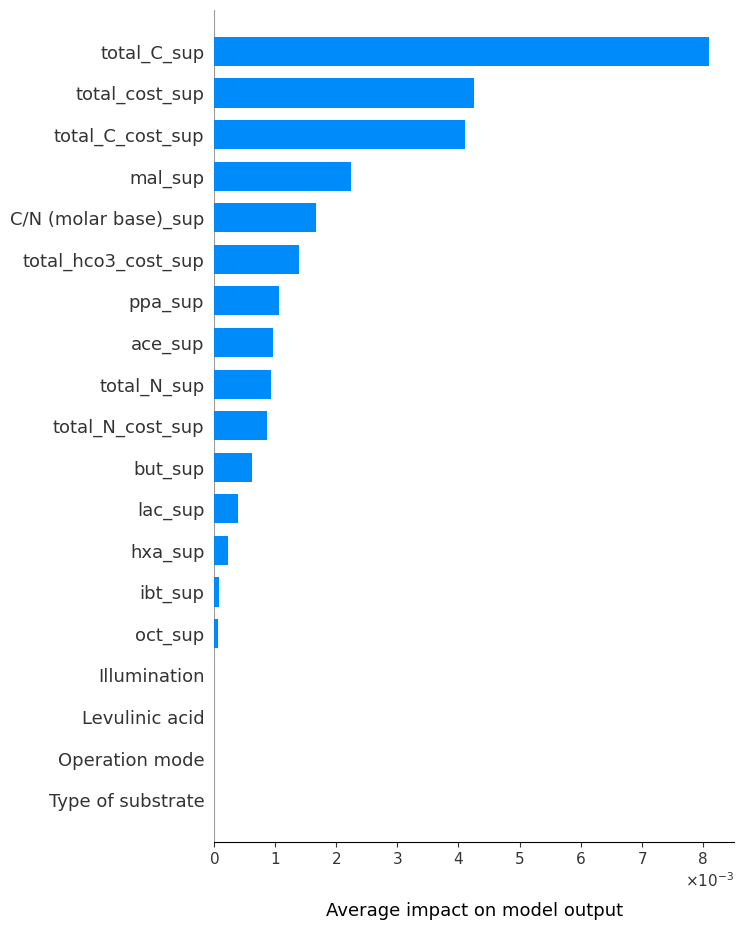

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


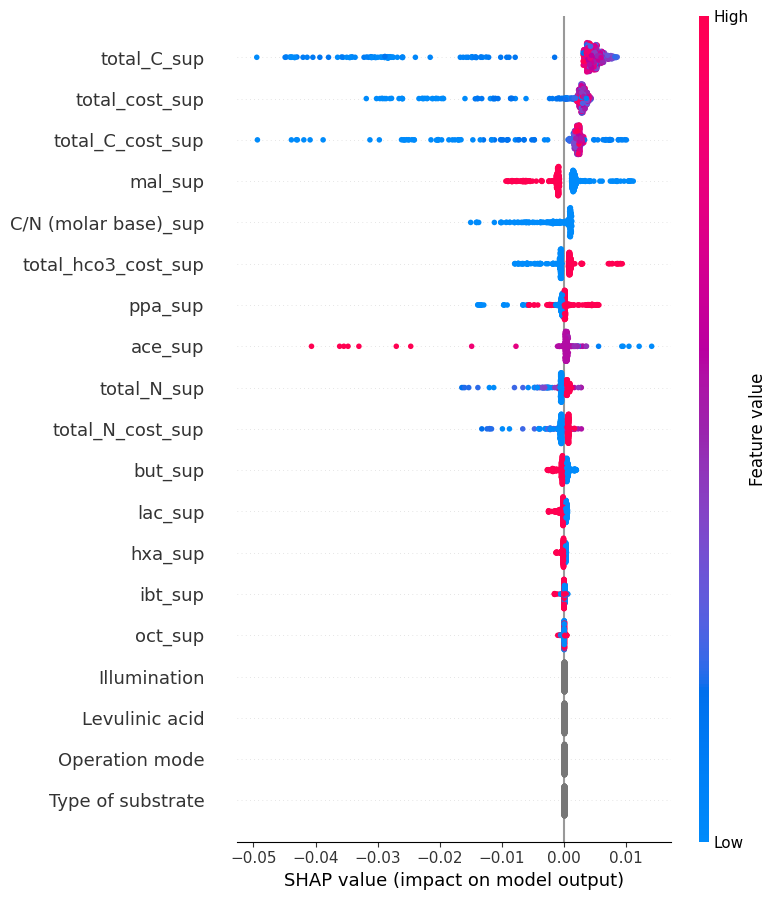


Best CatBoost predicted solution
    Unnamed: 0 Experiment Biomass (mg dw/L) PHB (mg/L)  % PHB PHV (mg/L)  \
164        164         21              1417     238.44  16.83      10.65   

    % PHV 5-ALA (micromol/L) Q10 (mg/g dw) Carotenoids (mg/g dw)  ...  \
164  0.75                NaN           NaN                   NaN  ...   

    total_C_con_pfba_molar PHB_yield_con_pfba total_N_con_pfba  \
164               2.064596           0.500919              0.0   

    total_N_con_pfba_molar C/N (molar base)_con_pfba total_C_cost_con_pfba  \
164                    0.0                       inf                0.0059   

    total_hco3_cost_con_pfba total_N_cost_con_pfba total_cost_con_pfba  \
164                      0.0                   0.0              0.0059   

    PHB_pred_flux  
164      0.398558  

[1 rows x 100 columns]


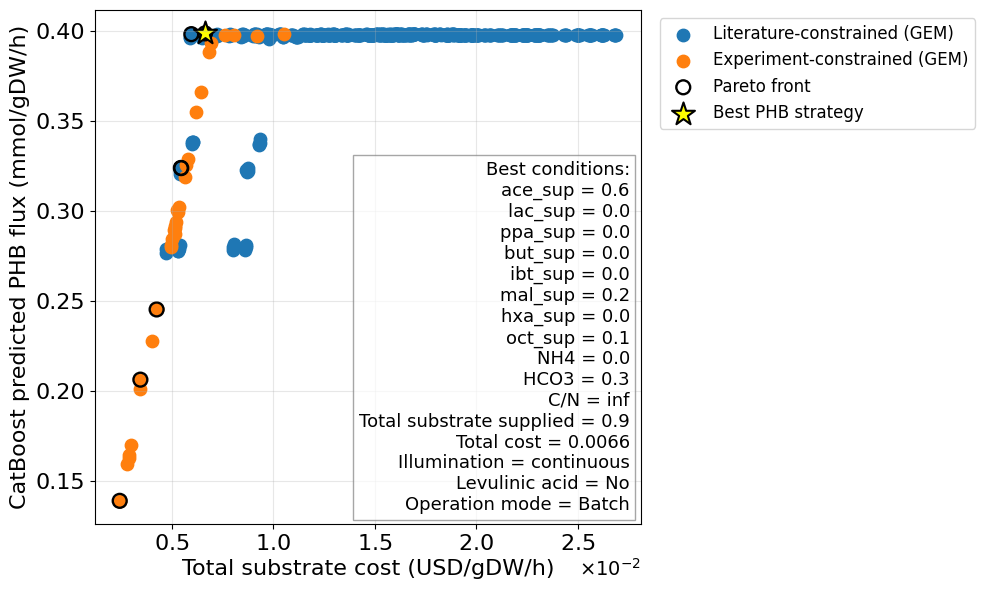


Synthetic ratio sensitivity analysis

Ratio 0:1
Experimental RMSE: 0.0048
Experimental R2:   0.9962

Ratio 1:1
Experimental RMSE: 0.0059
Experimental R2:   0.9943

Ratio 2:1
Experimental RMSE: 0.0050
Experimental R2:   0.9959

Ratio 4:1
Experimental RMSE: 0.0063
Experimental R2:   0.9937

Ratio 8:1
Experimental RMSE: 0.0052
Experimental R2:   0.9957

Ratio 16:1
Experimental RMSE: 0.0052
Experimental R2:   0.9956

Ratio sensitivity summary
   ratio  n_syn  exp_rmse    exp_r2
0      0      0  0.004816  0.996245
1      1     24  0.005940  0.994287
2      2     48  0.005043  0.995882
3      4     96  0.006251  0.993674
4      8    192  0.005161  0.995687
5     16    384  0.005222  0.995585


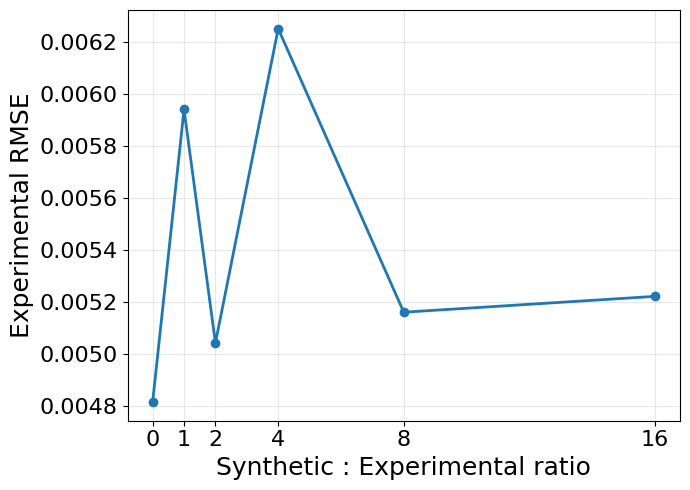


PHB_SYN_UB_VALUE: 1000

Detected substrate columns
['ace_sup', 'lac_sup', 'ppa_sup', 'but_sup', 'ibt_sup', 'mal_sup', 'hxa_sup', 'oct_sup']

Final feature columns
['ace_sup', 'lac_sup', 'ppa_sup', 'but_sup', 'ibt_sup', 'mal_sup', 'hxa_sup', 'oct_sup', 'C/N (molar base)_sup', 'total_C_sup', 'total_N_sup', 'total_C_cost_sup', 'total_cost_sup', 'total_N_cost_sup', 'total_hco3_cost_sup']

Using combined PHB flux target

Categorical features used
['Type of substrate', 'Illumination', 'Levulinic acid', 'Operation mode']
Training on fold [0/5]

bestTest = 0.02207332508
bestIteration = 599

Training on fold [1/5]

bestTest = 0.02603239107
bestIteration = 599

Training on fold [2/5]

bestTest = 0.02674418324
bestIteration = 599

Training on fold [3/5]

bestTest = 0.02296251502
bestIteration = 599

Training on fold [4/5]

bestTest = 0.02715961451
bestIteration = 599


5-fold Cross-Validation
CV RMSE: 0.0250 ± 0.0023
0:	learn: 0.7878220	test: 0.7761529	best: 0.7761529 (0)	total: 4.76ms	remaining

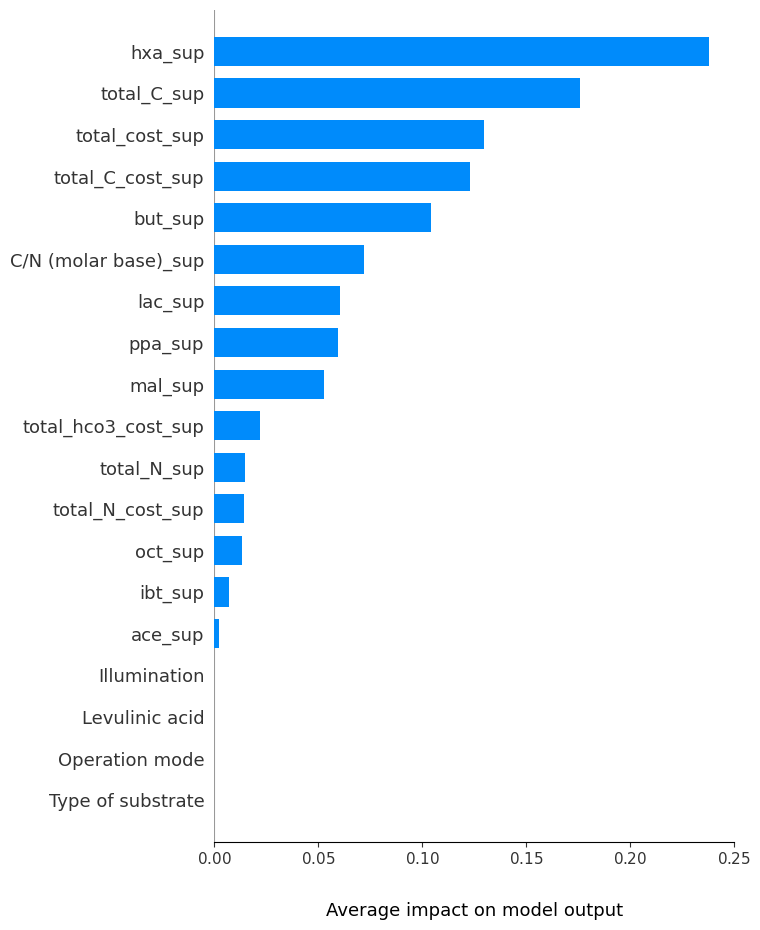

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


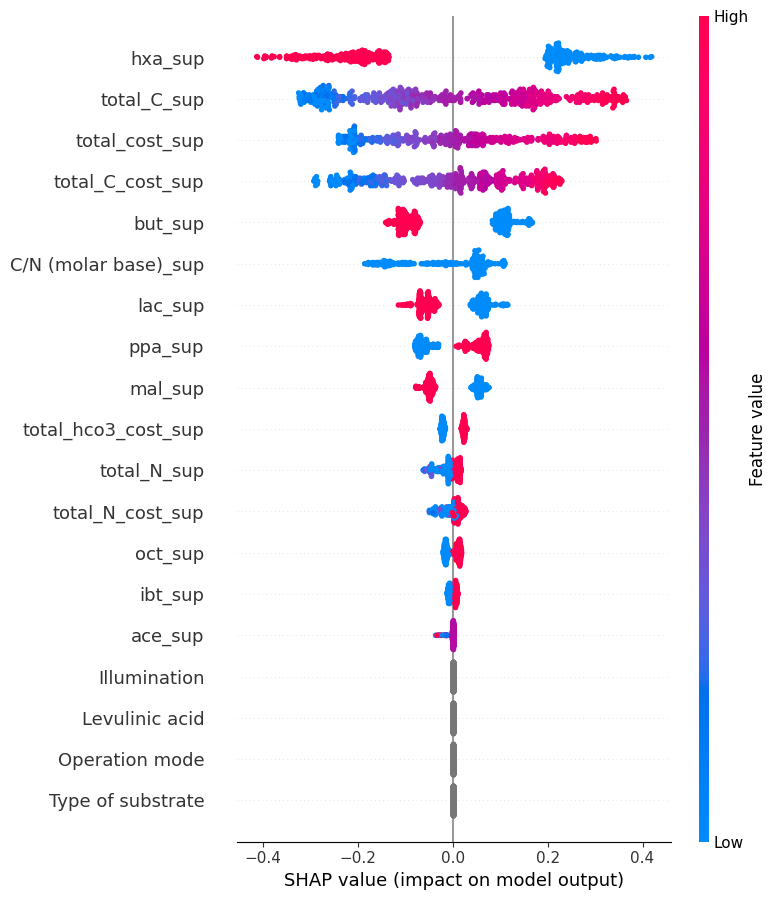


Best CatBoost predicted solution
    Unnamed: 0 Experiment Biomass (mg dw/L) PHB (mg/L)  % PHB PHV (mg/L)  \
533        533         21              1417     238.44  16.83      10.65   

    % PHV 5-ALA (micromol/L) Q10 (mg/g dw) Carotenoids (mg/g dw)  ...  \
533  0.75                NaN           NaN                   NaN  ...   

    total_C_con_pfba_molar PHB_yield_con_pfba total_N_con_pfba  \
533              12.029508           0.989482              0.0   

    total_N_con_pfba_molar C/N (molar base)_con_pfba total_C_cost_con_pfba  \
533                    0.0                       inf              0.022233   

    total_hco3_cost_con_pfba total_N_cost_con_pfba total_cost_con_pfba  \
533                 0.000674                   0.0            0.022907   

    PHB_pred_flux  
533      3.009448  

[1 rows x 100 columns]


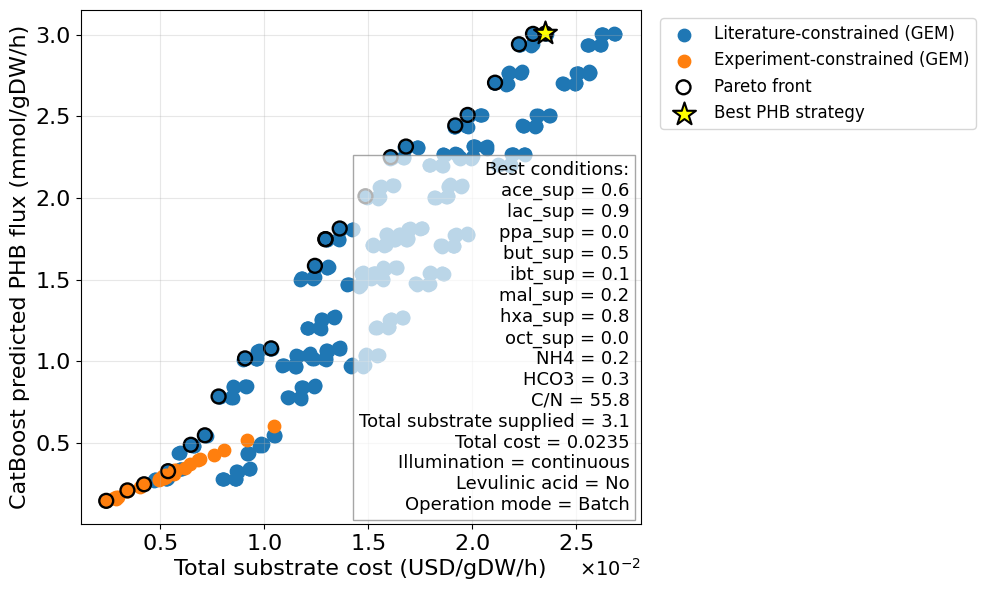


Synthetic ratio sensitivity analysis

Ratio 0:1
Experimental RMSE: 0.0364
Experimental R2:   0.9239

Ratio 1:1
Experimental RMSE: 0.0102
Experimental R2:   0.9940

Ratio 2:1
Experimental RMSE: 0.0076
Experimental R2:   0.9967

Ratio 4:1
Experimental RMSE: 0.0404
Experimental R2:   0.9062

Ratio 8:1
Experimental RMSE: 0.0495
Experimental R2:   0.8594

Ratio 16:1
Experimental RMSE: 0.0566
Experimental R2:   0.8165

Ratio sensitivity summary
   ratio  n_syn  exp_rmse    exp_r2
0      0      0  0.036423  0.923931
1      1     24  0.010242  0.993986
2      2     48  0.007627  0.996664
3      4     96  0.040446  0.906203
4      8    192  0.049516  0.859417
5     16    384  0.056575  0.816474


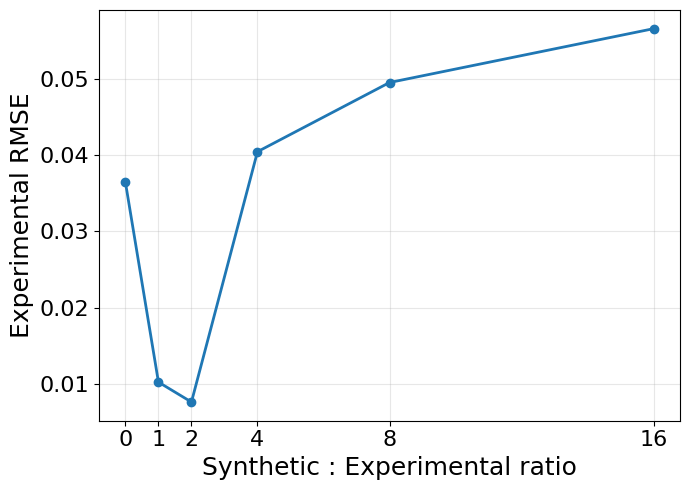

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import shap

from catboost import CatBoostRegressor, Pool, cv
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

PHB_SYN_UB_VALUES = [0.3978, 1000]

results_summary = []

for PHB_SYN_UB in PHB_SYN_UB_VALUES:

    print(f"\nPHB_SYN_UB_VALUE: {PHB_SYN_UB}")

    PHB_SYN_TAG = f"{PHB_SYN_UB:g}"

    # Load dataset
    df = pd.read_csv(
        PHB_GEM_AUGMENTATION_DIR /
        f"03_Buitron2025_dataset_augmented_VFAs_phb_with_cost_n2_{PHB_SYN_TAG}.csv"
    ).copy()

    # Detect substrate columns
    possible_substrates = [
        "ace", "lac", "ppa", "but",
        "ibt", "mal", "hxa", "oct"
    ]

    substrates = [
        c for c in df.columns
        if any(sub in c.lower() for sub in possible_substrates)
        and c.endswith("_sup")
        and not c.endswith("_con")
    ]

    print("\nDetected substrate columns")
    print(substrates)

    # Feature columns
    extra_features = [
        "C/N (molar base)_sup",
        "total_C_sup",
        "total_N_sup",
        "total_C_cost_sup",
        "total_cost_sup",
        "total_N_cost_sup",
        "total_hco3_cost_sup",
    ]

    extra_features = [
        c for c in extra_features
        if c in df.columns
    ]

    feature_cols = substrates + extra_features

    print("\nFinal feature columns")
    print(feature_cols)

    # Target
    target = "PHB_model_flux"
    y = df[target]

    print("\nUsing combined PHB flux target")

    # Categorical features
    cat_features = [
        "Type of substrate",
        "Illumination",
        "Levulinic acid",
        "Operation mode",
    ]

    existing_cat_features = [
        c for c in cat_features
        if c in df.columns
    ]

    print("\nCategorical features used")
    print(existing_cat_features)

    # Feature matrix
    X = df[feature_cols + existing_cat_features]

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=0
    )

    train_pool = Pool(
        X_train,
        y_train,
        cat_features=existing_cat_features
    )

    test_pool = Pool(
        X_test,
        y_test,
        cat_features=existing_cat_features
    )

    # Cross-validation
    cv_params = {
        "iterations": 600,
        "learning_rate": 0.03,
        "depth": 8,
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "random_seed": 0,
        "verbose": False
    }

    full_pool = Pool(
        X,
        y,
        cat_features=existing_cat_features
    )

    cv_results = cv(
        pool=full_pool,
        params=cv_params,
        fold_count=5,
        shuffle=True,
        partition_random_seed=0
    )

    cv_rmse_mean = cv_results["test-RMSE-mean"].iloc[-1]
    cv_rmse_std = cv_results["test-RMSE-std"].iloc[-1]

    print("\n5-fold Cross-Validation")
    print(f"CV RMSE: {cv_rmse_mean:.4f} \u00b1 {cv_rmse_std:.4f}")

    with open(
        PHB_CATBOOST_DIR /
        f"04_cv_metrics_SUP_{PHB_SYN_TAG}.txt",
        "w"
    ) as f:
        f.write(
            f"CV RMSE: {cv_rmse_mean:.4f} \u00b1 "
            f"{cv_rmse_std:.4f}\n"
        )

    # Train CatBoost model
    model = CatBoostRegressor(
        iterations=600,
        learning_rate=0.03,
        depth=8,
        loss_function="RMSE",
        verbose=100,
        random_seed=0
    )

    model.fit(train_pool, eval_set=test_pool)

    # Test-set evaluation
    pred_test = model.predict(test_pool)

    rmse = np.sqrt(
        mean_squared_error(y_test, pred_test)
    )

    r2 = r2_score(y_test, pred_test)

    print("\nCatBoost performance")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}")

    # Save model
    model_save_path = (
        PHB_CATBOOST_DIR /
        f"04_catboost_model_SUP_{PHB_SYN_TAG}.cbm"
    )

    model.save_model(model_save_path)

    print(f"\nModel saved to: {model_save_path}")

    # Retrain on ALL data
    model.fit(
        Pool(
            X,
            y,
            cat_features=existing_cat_features
        )
    )

    df["PHB_pred_flux"] = model.predict(
        Pool(
            X,
            cat_features=existing_cat_features
        )
    )

    # Experimental-only evaluation
    exp_mask = df["is_experimental"] == 1

    X_exp = df.loc[
        exp_mask,
        feature_cols + existing_cat_features
    ]

    y_exp = df.loc[exp_mask, target]

    exp_pool = Pool(
        X_exp,
        y_exp,
        cat_features=existing_cat_features
    )

    exp_pred = model.predict(exp_pool)

    exp_rmse = np.sqrt(
        mean_squared_error(y_exp, exp_pred)
    )

    exp_r2 = r2_score(y_exp, exp_pred)

    print("\nExperimental-only evaluation")
    print(f"Experimental RMSE: {exp_rmse:.4f}")
    print(f"Experimental R2:   {exp_r2:.4f}")

    # Synthetic-only evaluation
    syn_mask = df["is_experimental"] == 0

    syn_pool = Pool(
        df.loc[
            syn_mask,
            feature_cols + existing_cat_features
        ],
        cat_features=existing_cat_features
    )

    syn_pred = model.predict(syn_pool)

    syn_rmse = np.sqrt(
        mean_squared_error(
            df.loc[syn_mask, target],
            syn_pred
        )
    )

    syn_r2 = r2_score(
        df.loc[syn_mask, target],
        syn_pred
    )

    print("\nDomain shift check")
    print(f"Experimental RMSE: {exp_rmse:.4f}")
    print(f"Synthetic RMSE:    {syn_rmse:.4f}")
    print(f"Experimental R2:   {exp_r2:.4f}")
    print(f"Synthetic R2:      {syn_r2:.4f}")

    # SHAP analysis
    explainer = shap.TreeExplainer(
        model,
        feature_perturbation="tree_path_dependent"
    )

    shap_values = explainer.shap_values(X)

    # SHAP bar plot
    plt.figure(figsize=(18, 8))

    shap.summary_plot(
        shap_values,
        X,
        plot_type="bar",
        show=False
    )

    ax = plt.gca()

    ax.ticklabel_format(
        style='scientific',
        axis='x',
        scilimits=(0, 0)
    )

    ax.xaxis.get_major_formatter().set_useMathText(True)

    plt.gcf().subplots_adjust(
        left=0.45,
        right=1.1
    )

    ax.xaxis.set_major_formatter(
        mticker.ScalarFormatter(useMathText=True)
    )

    ax.ticklabel_format(
        style='sci',
        axis='x',
        scilimits=(-2, 2)
    )

    offset = ax.xaxis.get_offset_text()
    offset.set_size(11)
    offset.set_x(1.0)
    offset.set_y(-0.10)

    plt.xlabel(
        "Average impact on model output",
        fontsize=13,
        labelpad=25
    )

    for ext in ["pdf", "svg", "tiff"]:
        plt.savefig(
            PHB_FIGURES_DIR /
            f"04_catboost_shap_summary_SUP_{PHB_SYN_TAG}.{ext}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

    # SHAP beeswarm
    plt.figure(figsize=(10, 6))

    shap.summary_plot(
        shap_values,
        X,
        show=False
    )

    plt.tight_layout()

    for ext in ["pdf", "svg", "tiff"]:
        plt.savefig(
            PHB_FIGURES_DIR /
            f"04_catboost_shap_swarm_SUP_{PHB_SYN_TAG}.{ext}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

    # Best predicted solution
    best_idx = df["PHB_pred_flux"].idxmax()

    best_solution = df.loc[
        best_idx
    ].to_frame().T

    best_solution.to_csv(
        PHB_CATBOOST_DIR /
        f"04_catboost_optimal_conditions_SUP_{PHB_SYN_TAG}.csv",
        index=False
    )

    print("\nBest CatBoost predicted solution")
    print(best_solution)

    # Pareto front analysis
    def is_pareto_efficient(costs, maximize_cols=None):

        costs = np.asarray(costs, dtype=float)

        if maximize_cols is not None:
            costs[:, np.atleast_1d(maximize_cols)] *= -1

        n = costs.shape[0]
        is_eff = np.ones(n, dtype=bool)

        for i in range(n):

            if not is_eff[i]:
                continue

            others = np.arange(n) != i

            no_worse = np.all(
                costs[others] <= costs[i],
                axis=1
            )

            strictly_better = np.any(
                costs[others] < costs[i],
                axis=1
            )

            if np.any(no_worse & strictly_better):
                is_eff[i] = False

        return is_eff

    objectives = df[
        ["PHB_pred_flux", "total_cost_sup"]
    ].to_numpy()

    objectives = np.round(objectives, 3)

    pareto_mask = is_pareto_efficient(
        objectives,
        maximize_cols=[0]
    )

    pareto_solutions = df[pareto_mask]

    best_pareto_idx = pareto_solutions[
        "PHB_pred_flux"
    ].idxmax()

    best_pareto = pareto_solutions.loc[
        [best_pareto_idx]
    ]

    pareto_solutions.to_csv(
        PHB_PARETO_DIR /
        f"04_pareto_optimal_conditions_SUP_{PHB_SYN_TAG}.csv",
        index=False
    )

    best_pareto.to_csv(
        PHB_PARETO_DIR /
        f"04_best_pareto_conditions_SUP_{PHB_SYN_TAG}.csv",
        index=False
    )

    # Pareto plot
    COLOR_GEM = "#1f77b4"
    COLOR_EXP = "#ff7f0e"
    COLOR_BEST = "yellow"

    plt.figure(figsize=(10, 6))

    if "is_experimental" in df.columns:

        gem_points = df[
            df["is_experimental"] == 0
        ]

        plt.scatter(
            gem_points["total_cost_sup"],
            gem_points["PHB_pred_flux"],
            color=COLOR_GEM,
            s=80,
            label="Literature-constrained (GEM)"
        )

        exp_points = df[
            df["is_experimental"] == 1
        ]

        plt.scatter(
            exp_points["total_cost_sup"],
            exp_points["PHB_pred_flux"],
            color=COLOR_EXP,
            s=80,
            label="Experiment-constrained (GEM)"
        )

    plt.scatter(
        pareto_solutions["total_cost_sup"],
        pareto_solutions["PHB_pred_flux"],
        facecolors="none",
        edgecolors="black",
        s=100,
        linewidths=1.7,
        label="Pareto front"
    )

    plt.scatter(
        best_pareto["total_cost_sup"],
        best_pareto["PHB_pred_flux"],
        color=COLOR_BEST,
        s=300,
        marker="*",
        edgecolors="black",
        linewidths=1.5,
        label="Best PHB strategy"
    )

    # Annotation
    best_pareto_row = best_pareto.iloc[0]

    substrates = [
        "ace_sup", "lac_sup", "ppa_sup",
        "but_sup", "ibt_sup", "mal_sup",
        "hxa_sup", "oct_sup"
    ]

    annotation_lines = []

    for col in substrates:

        if col in best_pareto_row:

            val = best_pareto_row[col]

            if pd.notna(val):
                annotation_lines.append(
                    f"{col} = {abs(float(val)):.1f}"
                )

    if "nh4_sup" in best_pareto_row:

        val = best_pareto_row["nh4_sup"]

        if pd.notna(val):
            annotation_lines.append(
                f"NH4 = {abs(float(val)):.1f}"
            )

    if "hco3_sup" in best_pareto_row:

        val = best_pareto_row["hco3_sup"]

        if pd.notna(val):
            annotation_lines.append(
                f"HCO3 = {abs(float(val)):.1f}"
            )

    if "C/N (molar base)_sup" in best_pareto_row:

        val = best_pareto_row[
            "C/N (molar base)_sup"
        ]

        if pd.notna(val):

            val = abs(float(val))

            display_val = (
                "inf"
                if val > 1e6
                else f"{val:.1f}"
            )

            annotation_lines.append(
                f"C/N = {display_val}"
            )

    if "total_C_sup" in best_pareto_row:

        val = best_pareto_row["total_C_sup"]

        if pd.notna(val):
            annotation_lines.append(
                f"Total substrate supplied = "
                f"{abs(float(val)):.1f}"
            )

    if "total_cost_sup" in best_pareto_row:

        val = best_pareto_row["total_cost_sup"]

        if pd.notna(val):
            annotation_lines.append(
                f"Total cost = "
                f"{abs(float(val)):.4f}"
            )

    for col in existing_cat_features:

        if col == "Type of substrate":
            continue

        if col in best_pareto_row:

            val = best_pareto_row[col]

            if pd.notna(val):
                annotation_lines.append(
                    f"{col} = {val}"
                )

    feature_text = (
        "Best conditions:\n" +
        "\n".join(annotation_lines)
    )

    plt.annotate(
        feature_text,
        xy=(0.98, 0.02),
        xycoords='axes fraction',
        fontsize=13,
        ha='right',
        va='bottom',
        bbox=dict(
            facecolor='white',
            edgecolor='gray',
            alpha=0.7
        )
    )

    plt.xlabel(
        "Total substrate cost (USD/gDW/h)",
        fontsize=16
    )

    plt.ylabel(
        "CatBoost predicted PHB flux (mmol/gDW/h)",
        fontsize=16
    )

    ax = plt.gca()

    ax.ticklabel_format(
        style='scientific',
        axis='x',
        scilimits=(0, 0)
    )

    ax.xaxis.get_major_formatter().set_useMathText(True)

    ax.tick_params(
        axis='x',
        labelsize=14
    )

    offset = ax.xaxis.get_offset_text()
    offset.set_fontsize(14)
    offset.set_x(1.0)
    offset.set_y(-0.10)

    plt.grid(True, alpha=0.3)

    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    plt.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        fontsize=12
    )

    plt.tight_layout()

    for ext in ["pdf", "svg", "tiff"]:

        plt.savefig(
            PHB_FIGURES_DIR /
            f"04_PHB_catboost_pareto_plot_SUP_{PHB_SYN_TAG}.{ext}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

    # Save summary metrics
    results_summary.append({
        "PHB_SYN_UB": PHB_SYN_UB,
        "n_exp": (df["is_experimental"] == 1).sum(),
        "n_syn": (df["is_experimental"] == 0).sum(),
        "rmse": rmse,
        "r2": r2,
        "cv_rmse_mean": cv_rmse_mean,
        "cv_rmse_std": cv_rmse_std,
        "exp_rmse": exp_rmse,
        "exp_r2": exp_r2,
        "syn_rmse": syn_rmse,
        "syn_r2": syn_r2
    })

    # Synthetic ratio sensitivity analysis
    print("\nSynthetic ratio sensitivity analysis")

    exp_df = df[
        df["is_experimental"] == 1
    ].copy()

    syn_df = df[
        df["is_experimental"] == 0
    ].copy()

    exp_train_df, exp_test_df = train_test_split(
        exp_df,
        test_size=0.2,
        random_state=42
    )

    ratios = [0, 1, 2, 4, 8, 16]

    ratio_results = []

    for ratio in ratios:

        print(f"\nRatio {ratio}:1")

        n_exp_train = len(exp_train_df)

        n_syn = min(
            len(syn_df),
            ratio * n_exp_train
        )

        syn_subset = syn_df.sample(
            n=n_syn,
            random_state=42
        )

        train_df_ratio = pd.concat(
            [exp_train_df, syn_subset],
            ignore_index=True
        )

        X_train_ratio = train_df_ratio[
            feature_cols + existing_cat_features
        ]

        y_train_ratio = train_df_ratio[target]

        X_test_exp = exp_test_df[
            feature_cols + existing_cat_features
        ]

        y_test_exp = exp_test_df[target]

        train_pool_ratio = Pool(
            X_train_ratio,
            y_train_ratio,
            cat_features=existing_cat_features
        )

        test_pool_exp = Pool(
            X_test_exp,
            y_test_exp,
            cat_features=existing_cat_features
        )

        model_ratio = CatBoostRegressor(
            iterations=600,
            learning_rate=0.03,
            depth=8,
            loss_function="RMSE",
            verbose=False,
            random_seed=42
        )

        model_ratio.fit(train_pool_ratio)

        pred_exp = model_ratio.predict(
            test_pool_exp
        )

        exp_rmse_ratio = np.sqrt(
            mean_squared_error(
                y_test_exp,
                pred_exp
            )
        )

        exp_r2_ratio = r2_score(
            y_test_exp,
            pred_exp
        )

        print(
            f"Experimental RMSE: "
            f"{exp_rmse_ratio:.4f}"
        )

        print(
            f"Experimental R2:   "
            f"{exp_r2_ratio:.4f}"
        )

        ratio_results.append({
            "ratio": ratio,
            "n_syn": n_syn,
            "exp_rmse": exp_rmse_ratio,
            "exp_r2": exp_r2_ratio
        })

    ratio_results_df = pd.DataFrame(
        ratio_results
    )

    print("\nRatio sensitivity summary")
    print(ratio_results_df)

    ratio_results_df.to_csv(
        PHB_CATBOOST_DIR /
        f"synthetic_ratio_sensitivity_SUP_{PHB_SYN_TAG}.csv",
        index=False
    )

    # Sensitivity plot
    plt.figure(figsize=(7, 5))

    plt.plot(
        ratio_results_df["ratio"],
        ratio_results_df["exp_rmse"],
        marker="o",
        linewidth=2
    )

    plt.xlabel(
        "Synthetic : Experimental ratio",
        fontsize=18
    )

    plt.ylabel(
        "Experimental RMSE",
        fontsize=18
    )

    plt.xticks(
        ratio_results_df["ratio"],
        fontsize=16
    )

    plt.yticks(fontsize=16)

    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    for ext in ["pdf", "svg", "tiff"]:

        plt.savefig(
            PHB_FIGURES_DIR /
            f"synthetic_ratio_sensitivity_rmse_SUP_{PHB_SYN_TAG}.{ext}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

# Save overall summary
pd.DataFrame(results_summary).to_csv(
    PHB_CATBOOST_DIR /
    "synthetic_ratio_sensitivity_SUP_all_PHB_SYN_UB.csv",
    index=False
)


## *B.1 Version with SHAP plot (consumed in FBA)


PHB_SYN_UB_VALUE: 0.3978

Detected substrate columns:
['ace_con', 'lac_con', 'ppa_con', 'but_con', 'ibt_con', 'mal_con', 'hxa_con', 'oct_con']

Final feature columns:
['ace_con', 'lac_con', 'ppa_con', 'but_con', 'ibt_con', 'mal_con', 'hxa_con', 'oct_con', 'C/N (molar base)_con', 'total_C_con', 'total_N_con', 'total_C_cost_con', 'total_cost_con', 'total_N_cost_con', 'total_hco3_cost_con']

Categorical features:
['Type of substrate', 'Illumination', 'Levulinic acid', 'Operation mode']
Training on fold [0/5]

bestTest = 0.001742555732
bestIteration = 599

Training on fold [1/5]

bestTest = 0.0003731511989
bestIteration = 599

Training on fold [2/5]

bestTest = 0.0007626519086
bestIteration = 599

Training on fold [3/5]

bestTest = 0.001311955516
bestIteration = 594

Training on fold [4/5]

bestTest = 0.00229552001
bestIteration = 291


5-fold cross-validation
CV RMSE: 0.0013 ± 0.0008
0:	learn: 0.0368422	test: 0.0394514	best: 0.0394514 (0)	total: 570us	remaining: 342ms
100:	learn: 0.00547

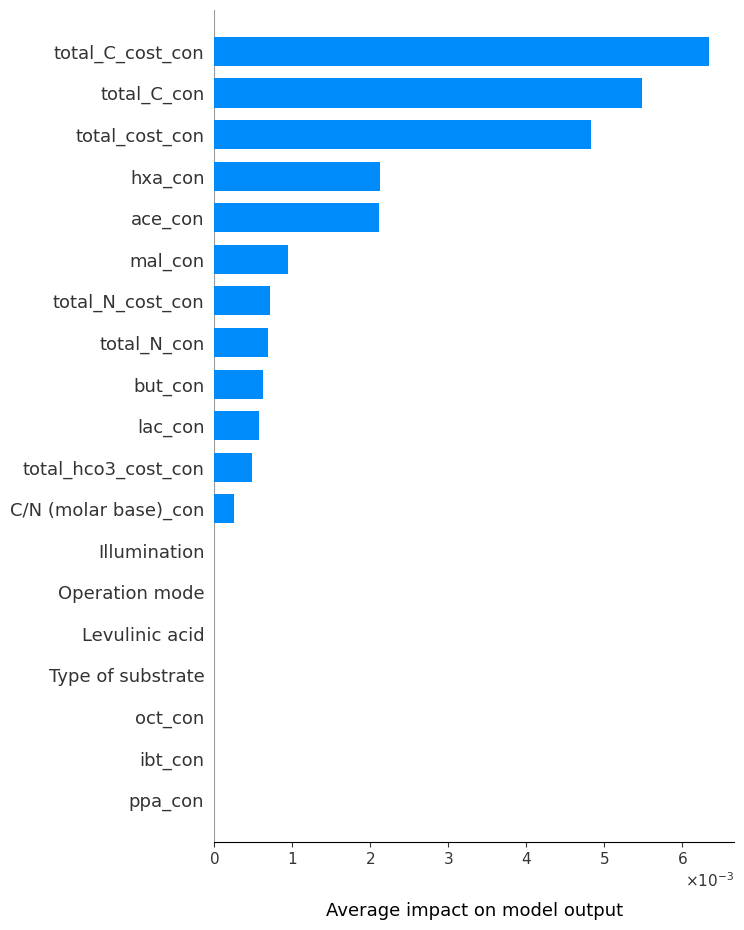

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


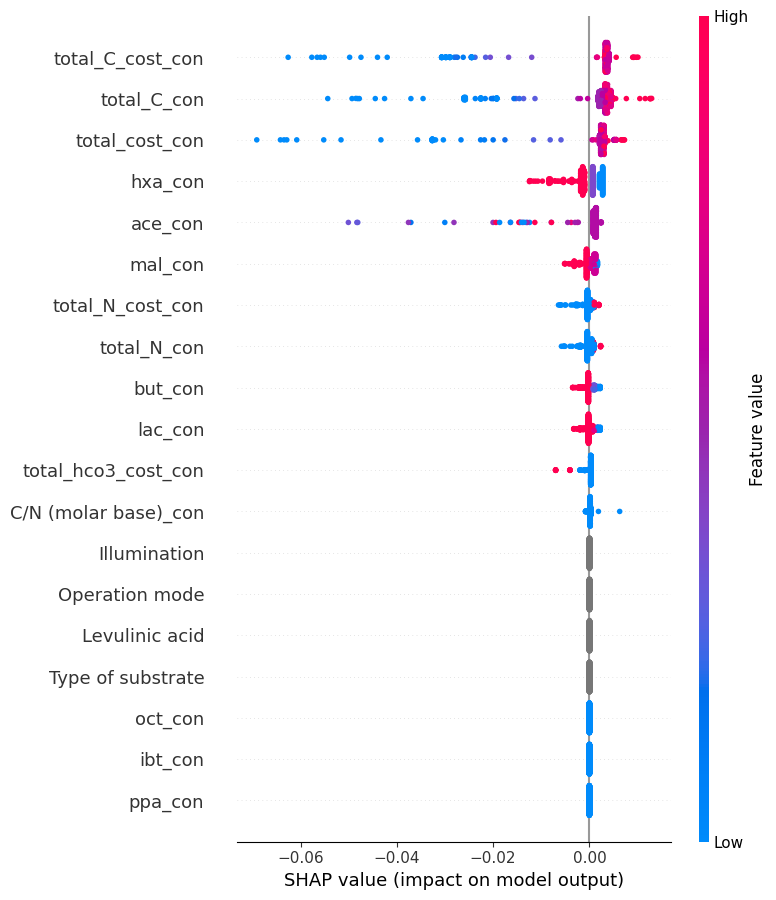


Best CatBoost predicted solution
   Unnamed: 0 Experiment Biomass (mg dw/L) PHB (mg/L) % PHB PHV (mg/L) % PHV  \
15         15         17               817    74.8372  9.16       4.89   0.6   

   5-ALA (micromol/L) Q10 (mg/g dw) Carotenoids (mg/g dw)  ...  \
15                NaN           NaN                   NaN  ...   

   total_C_con_pfba_molar PHB_yield_con_pfba total_N_con_pfba  \
15                2.39048            0.33282              0.0   

   total_N_con_pfba_molar C/N (molar base)_con_pfba total_C_cost_con_pfba  \
15                    0.0                       inf              0.010124   

   total_hco3_cost_con_pfba total_N_cost_con_pfba total_cost_con_pfba  \
15                      0.0                   0.0            0.010124   

   PHB_pred_flux  
15      0.398113  

[1 rows x 100 columns]


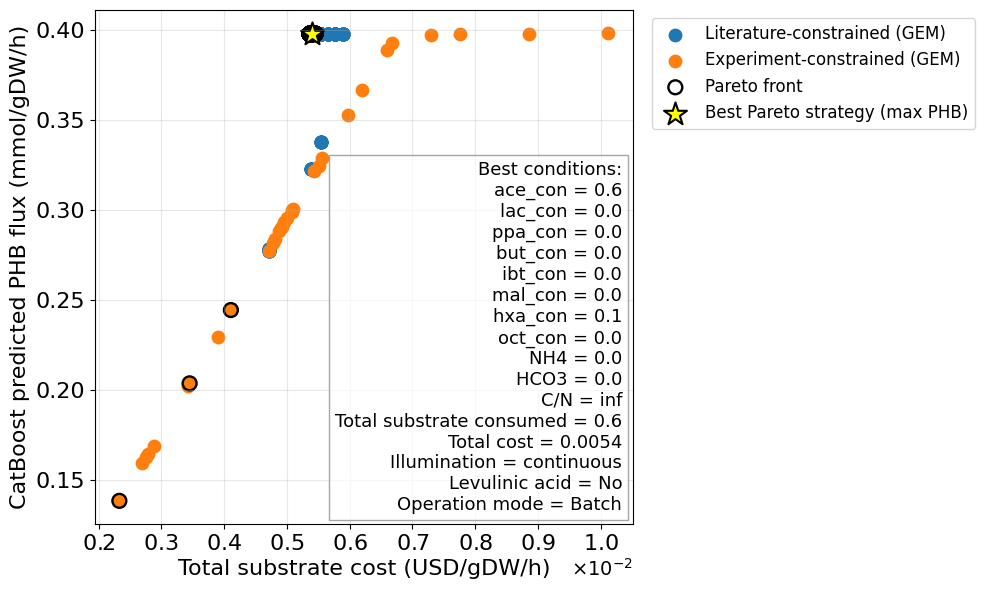


Synthetic ratio sensitivity analysis

Ratio 0:1
Experimental RMSE: 0.0047
Experimental R²:   0.9964

Ratio 1:1
Experimental RMSE: 0.0047
Experimental R²:   0.9965

Ratio 2:1
Experimental RMSE: 0.0057
Experimental R²:   0.9947

Ratio 4:1
Experimental RMSE: 0.0056
Experimental R²:   0.9949

Ratio 8:1
Experimental RMSE: 0.0054
Experimental R²:   0.9952

Ratio 16:1
Experimental RMSE: 0.0056
Experimental R²:   0.9949

Ratio sensitivity summary
   ratio  n_syn  exp_rmse    exp_r2
0      0      0  0.004697  0.996428
1      1     24  0.004665  0.996477
2      2     48  0.005697  0.994745
3      4     96  0.005631  0.994865
4      8    192  0.005437  0.995214
5     16    384  0.005613  0.994898


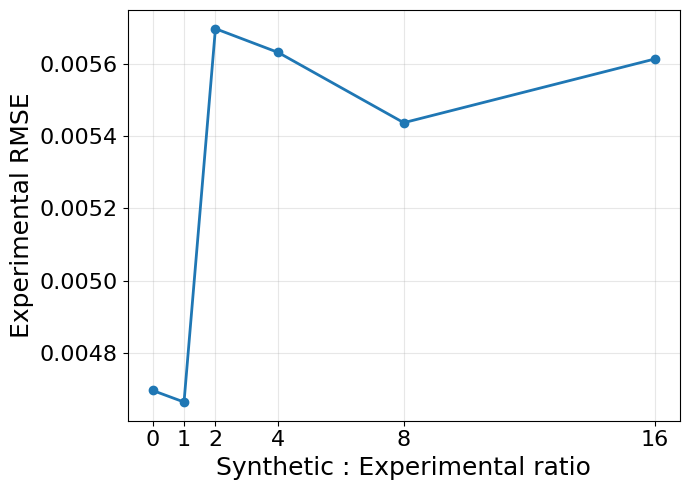


PHB_SYN_UB_VALUE: 1000

Detected substrate columns:
['ace_con', 'lac_con', 'ppa_con', 'but_con', 'ibt_con', 'mal_con', 'hxa_con', 'oct_con']

Final feature columns:
['ace_con', 'lac_con', 'ppa_con', 'but_con', 'ibt_con', 'mal_con', 'hxa_con', 'oct_con', 'C/N (molar base)_con', 'total_C_con', 'total_N_con', 'total_C_cost_con', 'total_cost_con', 'total_N_cost_con', 'total_hco3_cost_con']

Categorical features:
['Type of substrate', 'Illumination', 'Levulinic acid', 'Operation mode']
Training on fold [0/5]

bestTest = 0.003306091642
bestIteration = 599

Training on fold [1/5]

bestTest = 0.001339723649
bestIteration = 596

Training on fold [2/5]

bestTest = 0.00251364554
bestIteration = 599

Training on fold [3/5]

bestTest = 0.002460138029
bestIteration = 597

Training on fold [4/5]

bestTest = 0.002594856085
bestIteration = 599


5-fold cross-validation
CV RMSE: 0.0024 ± 0.0007
0:	learn: 0.7778891	test: 0.8236854	best: 0.8236854 (0)	total: 1.35ms	remaining: 807ms
100:	learn: 0.0697792	

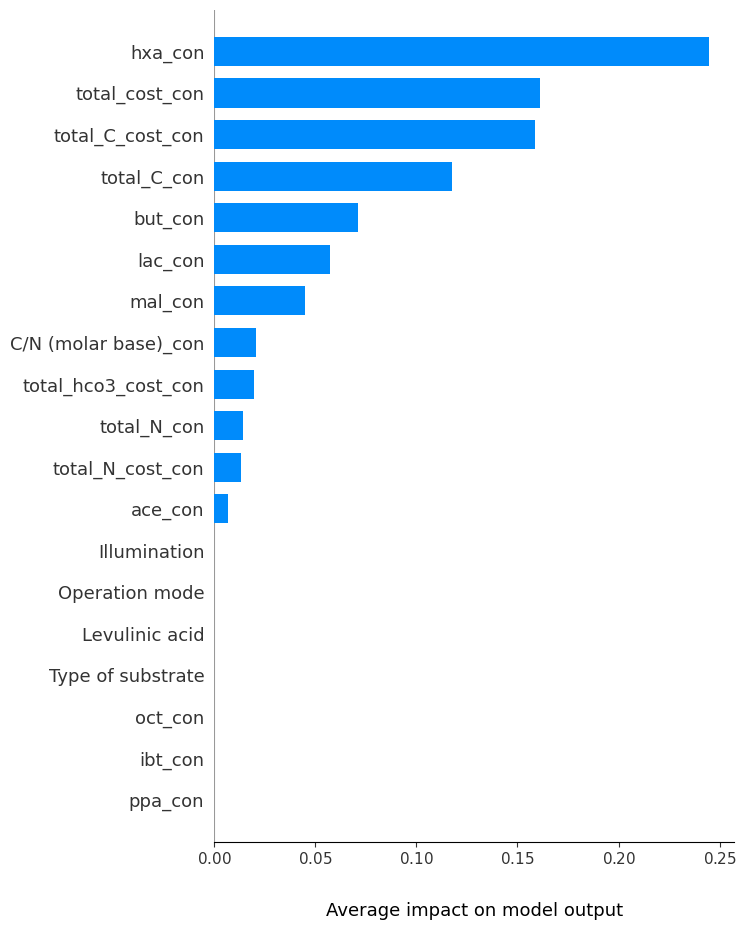

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


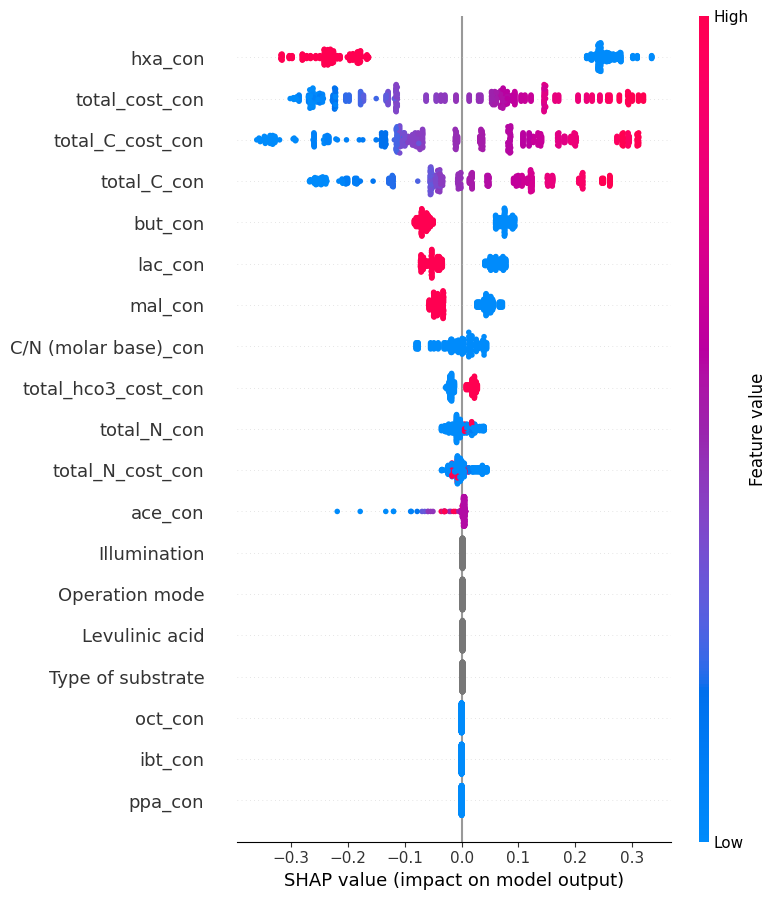


Best CatBoost predicted solution
    Unnamed: 0 Experiment Biomass (mg dw/L) PHB (mg/L)  % PHB PHV (mg/L)  \
245        245         21              1417     238.44  16.83      10.65   

    % PHV 5-ALA (micromol/L) Q10 (mg/g dw) Carotenoids (mg/g dw)  ...  \
245  0.75                NaN           NaN                   NaN  ...   

    total_C_con_pfba_molar PHB_yield_con_pfba total_N_con_pfba  \
245              12.029508           0.989482              0.0   

    total_N_con_pfba_molar C/N (molar base)_con_pfba total_C_cost_con_pfba  \
245                    0.0                       inf              0.022233   

    total_hco3_cost_con_pfba total_N_cost_con_pfba total_cost_con_pfba  \
245                 0.000674                   0.0            0.022907   

    PHB_pred_flux  
245      3.006556  

[1 rows x 100 columns]


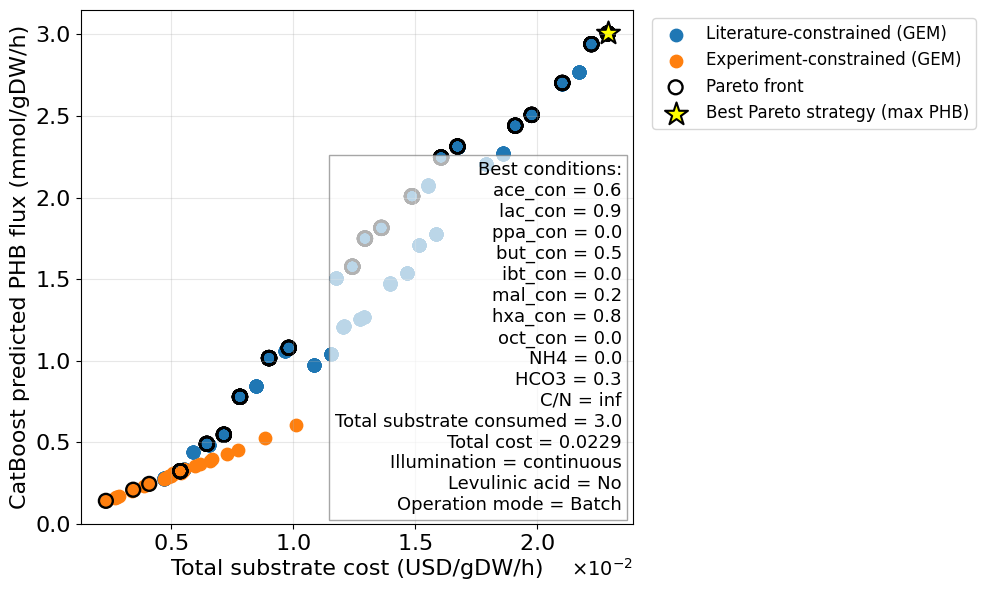


Synthetic ratio sensitivity analysis

Ratio 0:1
Experimental RMSE: 0.0309
Experimental R²:   0.9454

Ratio 1:1
Experimental RMSE: 0.0119
Experimental R²:   0.9919

Ratio 2:1
Experimental RMSE: 0.0130
Experimental R²:   0.9903

Ratio 4:1
Experimental RMSE: 0.0577
Experimental R²:   0.8094

Ratio 8:1
Experimental RMSE: 0.0450
Experimental R²:   0.8837

Ratio 16:1
Experimental RMSE: 0.0632
Experimental R²:   0.7712

Ratio sensitivity summary
   ratio  n_syn  exp_rmse    exp_r2
0      0      0  0.030864  0.945381
1      1     24  0.011913  0.991862
2      2     48  0.013028  0.990268
3      4     96  0.057662  0.809356
4      8    192  0.045041  0.883678
5     16    384  0.063175  0.771158


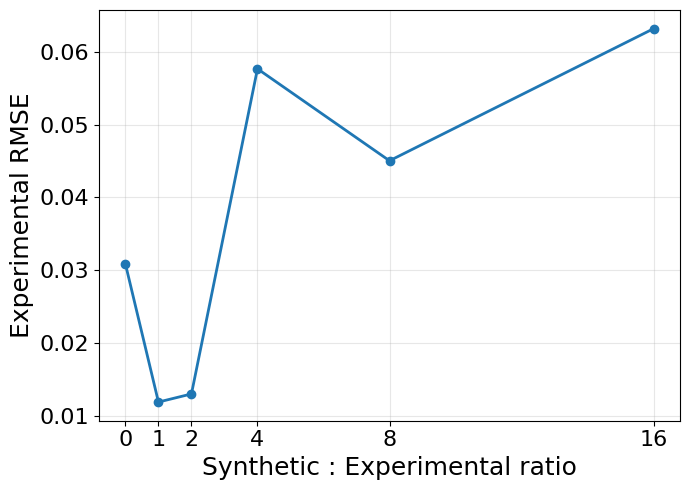

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from catboost import CatBoostRegressor, Pool, cv
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import shap
import joblib


results_summary = []

PHB_SYN_UB_VALUES = [0.3978, 1000]


for PHB_SYN_UB in PHB_SYN_UB_VALUES:

    print(f"\nPHB_SYN_UB_VALUE: {PHB_SYN_UB}")

    PHB_SYN_TAG = f"{PHB_SYN_UB:g}"

    # Load dataset
    df = pd.read_csv(
        PHB_GEM_AUGMENTATION_DIR /
        f"03_Buitron2025_dataset_augmented_VFAs_phb_with_cost_n2_{PHB_SYN_TAG}.csv"
    )

    df = df.copy()

    # Detect substrate columns
    possible_substrates = [
        "ace", "lac", "ppa", "but",
        "ibt", "mal", "hxa", "oct"
    ]

    substrates = [
        c for c in df.columns
        if any(sub in c.lower() for sub in possible_substrates)
        and c.endswith("_con")
        and not c.endswith("_pfba")
        and not c.endswith("_sup")
    ]

    print("\nDetected substrate columns:")
    print(substrates)

    # Feature columns
    extra_features = [
        "C/N (molar base)_con",
        "total_C_con",
        "total_N_con",
        "total_C_cost_con",
        "total_cost_con",
        "total_N_cost_con",
        "total_hco3_cost_con",
    ]

    extra_features = [
        c for c in extra_features
        if c in df.columns
    ]

    feature_cols = substrates + extra_features

    print("\nFinal feature columns:")
    print(feature_cols)

    # Target
    target = "PHB_model_flux"

    # Categorical features
    cat_features = [
        "Type of substrate",
        "Illumination",
        "Levulinic acid",
        "Operation mode",
    ]

    existing_cat_features = [
        c for c in cat_features
        if c in df.columns
    ]

    print("\nCategorical features:")
    print(existing_cat_features)

    X = df[feature_cols + existing_cat_features]
    y = df[target]

    # Train / test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=0,
        stratify=df["is_experimental"]
    )

    train_pool = Pool(
        X_train,
        y_train,
        cat_features=existing_cat_features
    )

    test_pool = Pool(
        X_test,
        y_test,
        cat_features=existing_cat_features
    )

    # 5-fold cross-validation
    cv_params = {
        "iterations": 600,
        "learning_rate": 0.03,
        "depth": 8,
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "random_seed": 0,
        "verbose": False
    }

    full_pool = Pool(
        X,
        y,
        cat_features=existing_cat_features
    )

    cv_results = cv(
        pool=full_pool,
        params=cv_params,
        fold_count=5,
        shuffle=True,
        partition_random_seed=0
    )

    cv_rmse_mean = cv_results["test-RMSE-mean"].iloc[-1]
    cv_rmse_std = cv_results["test-RMSE-std"].iloc[-1]

    print("\n5-fold cross-validation")
    print(f"CV RMSE: {cv_rmse_mean:.4f} ± {cv_rmse_std:.4f}")

    with open(
        PHB_CATBOOST_DIR /
        f"04_cv_metrics_CON_{PHB_SYN_TAG}.txt",
        "w"
    ) as f:

        f.write(
            f"CV RMSE: {cv_rmse_mean:.4f} ± {cv_rmse_std:.4f}\n"
        )

    # Train CatBoost model
    model = CatBoostRegressor(
        iterations=600,
        learning_rate=0.03,
        depth=8,
        loss_function="RMSE",
        verbose=100,
        random_seed=0
    )

    model.fit(
        train_pool,
        eval_set=test_pool
    )

    # Standard test-set evaluation
    pred_test = model.predict(test_pool)

    rmse = np.sqrt(
        mean_squared_error(y_test, pred_test)
    )

    r2 = r2_score(
        y_test,
        pred_test
    )

    print("\nStandard test evaluation")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")

    # Save model
    model_save_path = (
        PHB_CATBOOST_DIR /
        f"04_catboost_model_CON_{PHB_SYN_TAG}.cbm"
    )

    model.save_model(model_save_path)

    print(f"\nModel saved to:\n{model_save_path}")

    # Retrain on ALL data
    model.fit(
        Pool(
            X,
            y,
            cat_features=existing_cat_features
        )
    )

    df["PHB_pred_flux"] = model.predict(
        Pool(
            X,
            cat_features=existing_cat_features
        )
    )

    # Experimental-domain fit (in-sample)
    exp_mask = df["is_experimental"] == 1

    X_exp = df.loc[
        exp_mask,
        feature_cols + existing_cat_features
    ]

    y_exp = df.loc[
        exp_mask,
        target
    ]

    exp_pool = Pool(
        X_exp,
        y_exp,
        cat_features=existing_cat_features
    )

    exp_pred = model.predict(exp_pool)

    exp_rmse = np.sqrt(
        mean_squared_error(y_exp, exp_pred)
    )

    exp_r2 = r2_score(
        y_exp,
        exp_pred
    )

    print("\nExperimental subset performance (in-sample)")
    print(f"RMSE: {exp_rmse:.4f}")
    print(f"R²:   {exp_r2:.4f}")

    # Synthetic-domain fit
    syn_mask = df["is_experimental"] == 0

    X_syn = df.loc[
        syn_mask,
        feature_cols + existing_cat_features
    ]

    y_syn = df.loc[
        syn_mask,
        target
    ]

    syn_pool = Pool(
        X_syn,
        y_syn,
        cat_features=existing_cat_features
    )

    syn_pred = model.predict(syn_pool)

    syn_rmse = np.sqrt(
        mean_squared_error(y_syn, syn_pred)
    )

    syn_r2 = r2_score(
        y_syn,
        syn_pred
    )

    print("\nDomain shift check")
    print(f"Experimental RMSE: {exp_rmse:.4f}")
    print(f"Synthetic RMSE:    {syn_rmse:.4f}")

    # SHAP analysis
    explainer = shap.TreeExplainer(
        model,
        feature_perturbation="tree_path_dependent"
    )

    shap_values = explainer.shap_values(X)

    # SHAP bar plot
    plt.figure(figsize=(18, 8))

    shap.summary_plot(
        shap_values,
        X,
        plot_type="bar",
        show=False
    )

    ax = plt.gca()

    ax.xaxis.set_major_formatter(
        mticker.ScalarFormatter(useMathText=True)
    )

    ax.ticklabel_format(
        style='sci',
        axis='x',
        scilimits=(-2, 2)
    )

    offset = ax.xaxis.get_offset_text()

    offset.set_size(11)
    offset.set_x(1.0)
    offset.set_y(-0.10)

    plt.gcf().subplots_adjust(
        left=0.45,
        right=1.1
    )

    plt.xlabel(
        "Average impact on model output",
        fontsize=13,
        labelpad=25
    )

    for ext in ["pdf", "svg", "tiff"]:

        plt.savefig(
            PHB_FIGURES_DIR /
            f"04_catboost_shap_summary_CON_{PHB_SYN_TAG}.{ext}",
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

    # SHAP beeswarm
    plt.figure(figsize=(10, 6))

    shap.summary_plot(
        shap_values,
        X,
        show=False
    )

    plt.tight_layout()

    for ext in ["pdf", "svg", "tiff"]:

        plt.savefig(
            PHB_FIGURES_DIR /
            f"04_catboost_shap_swarm_CON_{PHB_SYN_TAG}.{ext}",
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

    # Best predicted solution
    best_idx = df["PHB_pred_flux"].idxmax()

    best_solution = df.loc[
        best_idx
    ].to_frame().T

    best_solution.to_csv(
        PHB_CATBOOST_DIR /
        f"04_catboost_optimal_conditions_CON_{PHB_SYN_TAG}.csv",
        index=False
    )

    print("\nBest CatBoost predicted solution")
    print(best_solution)

    # Pareto front analysis
    def is_pareto_efficient(costs, maximize_cols=None):

        costs = np.asarray(costs, dtype=float)

        if maximize_cols is not None:
            costs[:, np.atleast_1d(maximize_cols)] *= -1

        n = costs.shape[0]

        is_eff = np.ones(n, dtype=bool)

        for i in range(n):

            if not is_eff[i]:
                continue

            others = np.arange(n) != i

            no_worse = np.all(
                costs[others] <= costs[i],
                axis=1
            )

            strictly_better = np.any(
                costs[others] < costs[i],
                axis=1
            )

            if np.any(no_worse & strictly_better):
                is_eff[i] = False

        return is_eff

    objectives = df[
        ["PHB_pred_flux", "total_cost_con"]
    ].to_numpy()

    objectives = np.round(objectives, 3)

    pareto_mask = is_pareto_efficient(
        objectives,
        maximize_cols=[0]
    )

    pareto_solutions = df[pareto_mask]

    best_pareto_idx = pareto_solutions[
        "PHB_pred_flux"
    ].idxmax()

    best_pareto = pareto_solutions.loc[
        [best_pareto_idx]
    ]

    pareto_solutions.to_csv(
        PHB_PARETO_DIR /
        f"04_pareto_optimal_conditions_CON_{PHB_SYN_TAG}.csv",
        index=False,
    )

    best_pareto.to_csv(
        PHB_PARETO_DIR /
        f"04_best_pareto_conditions_CON_{PHB_SYN_TAG}.csv",
        index=False,
    )

    # PHB flux vs cost plot
    COLOR_GEM = "#1f77b4"
    COLOR_EXP = "#ff7f0e"
    COLOR_BEST = "yellow"

    plt.figure(figsize=(10, 6))

    if "is_experimental" in df.columns:

        gem_points = df[
            df["is_experimental"] == 0
        ]

        plt.scatter(
            gem_points["total_cost_con"],
            gem_points["PHB_pred_flux"],
            color=COLOR_GEM,
            s=80,
            label="Literature-constrained (GEM)",
        )

        exp_points = df[
            df["is_experimental"] == 1
        ]

        plt.scatter(
            exp_points["total_cost_con"],
            exp_points["PHB_pred_flux"],
            color=COLOR_EXP,
            s=80,
            label="Experiment-constrained (GEM)",
        )

    plt.scatter(
        pareto_solutions["total_cost_con"],
        pareto_solutions["PHB_pred_flux"],
        facecolors="none",
        edgecolors="black",
        s=100,
        linewidths=1.7,
        label="Pareto front",
    )

    plt.scatter(
        best_pareto["total_cost_con"],
        best_pareto["PHB_pred_flux"],
        color=COLOR_BEST,
        s=300,
        marker="*",
        edgecolors="black",
        linewidths=1.5,
        label="Best Pareto strategy (max PHB)",
    )

    # Annotation
    best_pareto_row = best_pareto.iloc[0]

    annotation_lines = []

    for col in substrates:

        if col in best_pareto_row:

            val = best_pareto_row[col]

            if pd.notna(val):

                annotation_lines.append(
                    f"{col} = {abs(float(val)):.1f}"
                )

    for special_col, label in [
        ("nh4_con", "NH4"),
        ("hco3_con", "HCO3")
    ]:

        if special_col in best_pareto_row:

            val = best_pareto_row[special_col]

            if pd.notna(val):

                annotation_lines.append(
                    f"{label} = {abs(float(val)):.1f}"
                )

    if "C/N (molar base)_con" in best_pareto_row:

        val = best_pareto_row[
            "C/N (molar base)_con"
        ]

        if pd.notna(val):

            val = abs(float(val))

            display_val = (
                "inf"
                if val > 1e6
                else f"{val:.1f}"
            )

            annotation_lines.append(
                f"C/N = {display_val}"
            )

    if "total_C_con" in best_pareto_row:

        val = best_pareto_row["total_C_con"]

        if pd.notna(val):

            annotation_lines.append(
                f"Total substrate consumed = {abs(float(val)):.1f}"
            )

    if "total_cost_con" in best_pareto_row:

        val = best_pareto_row["total_cost_con"]

        if pd.notna(val):

            annotation_lines.append(
                f"Total cost = {abs(float(val)):.4f}"
            )

    for col in existing_cat_features:

        if col == "Type of substrate":
            continue

        if col in best_pareto_row:

            val = best_pareto_row[col]

            if pd.notna(val):

                annotation_lines.append(
                    f"{col} = {val}"
                )

    feature_text = (
        "Best conditions:\n" +
        "\n".join(annotation_lines)
    )

    plt.annotate(
        feature_text,
        xy=(0.98, 0.02),
        xycoords='axes fraction',
        fontsize=13,
        ha='right',
        va='bottom',
        bbox=dict(
            facecolor='white',
            edgecolor='gray',
            alpha=0.7
        )
    )

    plt.xlabel(
        "Total substrate cost (USD/gDW/h)",
        fontsize=16
    )

    plt.ylabel(
        "CatBoost predicted PHB flux (mmol/gDW/h)",
        fontsize=16
    )

    ax = plt.gca()

    ax.ticklabel_format(
        style='scientific',
        axis='x',
        scilimits=(0, 0)
    )

    ax.xaxis.get_major_formatter().set_useMathText(True)

    ax.tick_params(
        axis='x',
        labelsize=14
    )

    offset = ax.xaxis.get_offset_text()

    offset.set_fontsize(14)
    offset.set_x(1.0)
    offset.set_y(-0.10)

    plt.grid(True, alpha=0.3)

    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    plt.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        fontsize=12
    )

    plt.tight_layout()

    for ext in ["pdf", "svg", "tiff"]:

        plt.savefig(
            PHB_FIGURES_DIR /
            f"04_PHB_catboost_pareto_plot_CON_{PHB_SYN_TAG}.{ext}",
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

    # Results summary
    results_summary.append({
        "PHB_SYN_UB": PHB_SYN_UB,
        "n_exp": (df["is_experimental"] == 1).sum(),
        "n_syn": (df["is_experimental"] == 0).sum(),
        "rmse": rmse,
        "r2": r2,
        "cv_rmse_mean": cv_rmse_mean,
        "cv_rmse_std": cv_rmse_std,
        "exp_rmse": exp_rmse,
        "exp_r2": exp_r2,
        "syn_rmse": syn_rmse,
        "syn_r2": syn_r2,
    })

    # Synthetic ratio sensitivity analysis
    print("\nSynthetic ratio sensitivity analysis")

    exp_df = df[
        df["is_experimental"] == 1
    ].copy()

    syn_df = df[
        df["is_experimental"] == 0
    ].copy()

    exp_train_df, exp_test_df = train_test_split(
        exp_df,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )

    ratios = [0, 1, 2, 4, 8, 16]

    ratio_results = []

    for ratio in ratios:

        print(f"\nRatio {ratio}:1")

        n_exp_train = len(exp_train_df)

        n_syn = min(
            len(syn_df),
            ratio * n_exp_train
        )

        syn_subset = syn_df.sample(
            n=n_syn,
            random_state=42
        )

        train_df_ratio = pd.concat(
            [exp_train_df, syn_subset],
            ignore_index=True
        )

        X_train_ratio = train_df_ratio[
            feature_cols + existing_cat_features
        ]

        y_train_ratio = train_df_ratio[target]

        X_test_exp = exp_test_df[
            feature_cols + existing_cat_features
        ]

        y_test_exp = exp_test_df[target]

        train_pool_ratio = Pool(
            X_train_ratio,
            y_train_ratio,
            cat_features=existing_cat_features
        )

        test_pool_exp = Pool(
            X_test_exp,
            y_test_exp,
            cat_features=existing_cat_features
        )

        model_ratio = CatBoostRegressor(
            iterations=600,
            learning_rate=0.03,
            depth=8,
            loss_function="RMSE",
            verbose=False,
            random_seed=42
        )

        model_ratio.fit(train_pool_ratio)

        pred_exp = model_ratio.predict(
            test_pool_exp
        )

        exp_rmse_ratio = np.sqrt(
            mean_squared_error(
                y_test_exp,
                pred_exp
            )
        )

        exp_r2_ratio = r2_score(
            y_test_exp,
            pred_exp
        )

        print(f"Experimental RMSE: {exp_rmse_ratio:.4f}")
        print(f"Experimental R²:   {exp_r2_ratio:.4f}")

        ratio_results.append({
            "ratio": ratio,
            "n_syn": n_syn,
            "exp_rmse": exp_rmse_ratio,
            "exp_r2": exp_r2_ratio
        })

    ratio_results_df = pd.DataFrame(
        ratio_results
    )

    print("\nRatio sensitivity summary")
    print(ratio_results_df)

    ratio_results_df.to_csv(
        PHB_CATBOOST_DIR /
        f"synthetic_ratio_sensitivity_CON_{PHB_SYN_TAG}.csv",
        index=False
    )

    # Sensitivity plot
    plt.figure(figsize=(7, 5))

    plt.plot(
        ratio_results_df["ratio"],
        ratio_results_df["exp_rmse"],
        marker="o",
        linewidth=2
    )

    plt.xlabel(
        "Synthetic : Experimental ratio",
        fontsize=18
    )

    plt.ylabel(
        "Experimental RMSE",
        fontsize=18
    )

    plt.xticks(
        ratio_results_df["ratio"],
        fontsize=16
    )

    plt.yticks(fontsize=16)

    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    for ext in ["pdf", "svg", "tiff"]:

        plt.savefig(
            PHB_FIGURES_DIR /
            f"synthetic_ratio_sensitivity_rmse_CON_{PHB_SYN_TAG}.{ext}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()


# Save overall summary
pd.DataFrame(results_summary).to_csv(
    PHB_CATBOOST_DIR /
    "synthetic_ratio_sensitivity_CON_all_PHB_SYN_UB.csv",
    index=False
)

## *B.2 Version with SHAP plot (consumed in pFBA)


PHB_SYN_UB_VALUE: 0.3978

Detected substrate columns:
['ace_con_pfba', 'lac_con_pfba', 'ppa_con_pfba', 'but_con_pfba', 'ibt_con_pfba', 'mal_con_pfba', 'hxa_con_pfba', 'oct_con_pfba']

Final feature columns:
['ace_con_pfba', 'lac_con_pfba', 'ppa_con_pfba', 'but_con_pfba', 'ibt_con_pfba', 'mal_con_pfba', 'hxa_con_pfba', 'oct_con_pfba', 'C/N (molar base)_con_pfba', 'total_C_con_pfba', 'total_N_con_pfba', 'total_C_cost_con_pfba', 'total_cost_con_pfba', 'total_N_cost_con_pfba', 'total_hco3_cost_con_pfba']

Categorical features:
['Type of substrate', 'Illumination', 'Levulinic acid', 'Operation mode']
Training on fold [0/5]

bestTest = 0.02170728117
bestIteration = 599

Training on fold [1/5]

bestTest = 0.001356891188
bestIteration = 598

Training on fold [2/5]

bestTest = 0.00312449811
bestIteration = 599

Training on fold [3/5]

bestTest = 0.001825953893
bestIteration = 599

Training on fold [4/5]

bestTest = 0.003910334303
bestIteration = 599


5-fold cross-validation
CV RMSE: 0.0064 ± 

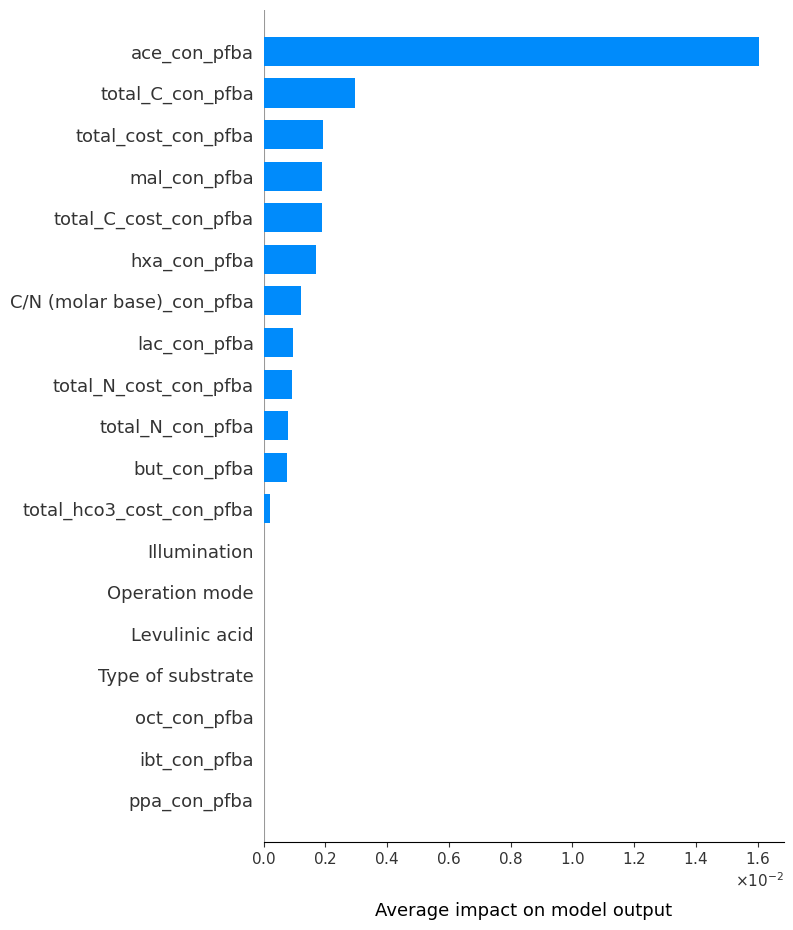

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


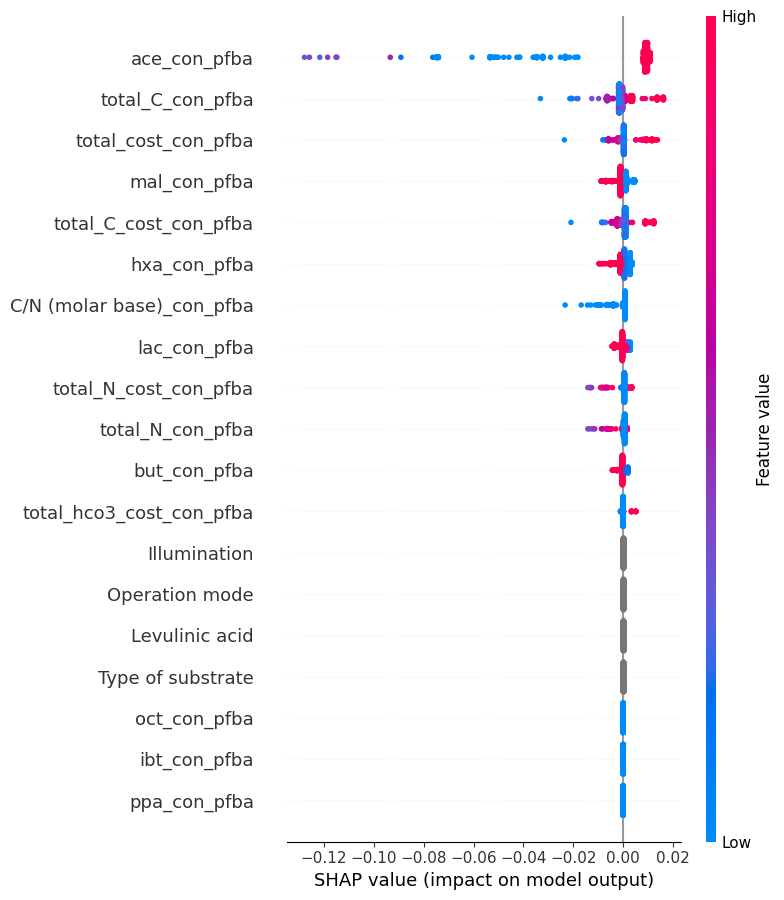


Best CatBoost predicted solution
   Unnamed: 0 Experiment Biomass (mg dw/L) PHB (mg/L) % PHB PHV (mg/L) % PHV  \
10         10         12              1237       99.0   8.4        9.5   0.8   

   5-ALA (micromol/L) Q10 (mg/g dw) Carotenoids (mg/g dw)  ...  \
10                NaN           NaN                   NaN  ...   

   total_C_con_pfba_molar PHB_yield_con_pfba total_N_con_pfba  \
10               1.830381           0.434663          0.12398   

   total_N_con_pfba_molar C/N (molar base)_con_pfba total_C_cost_con_pfba  \
10                0.12398                 14.763578              0.007752   

   total_hco3_cost_con_pfba total_N_cost_con_pfba total_cost_con_pfba  \
10                      0.0              0.000335            0.008086   

   PHB_pred_flux  
10      0.397943  

[1 rows x 100 columns]


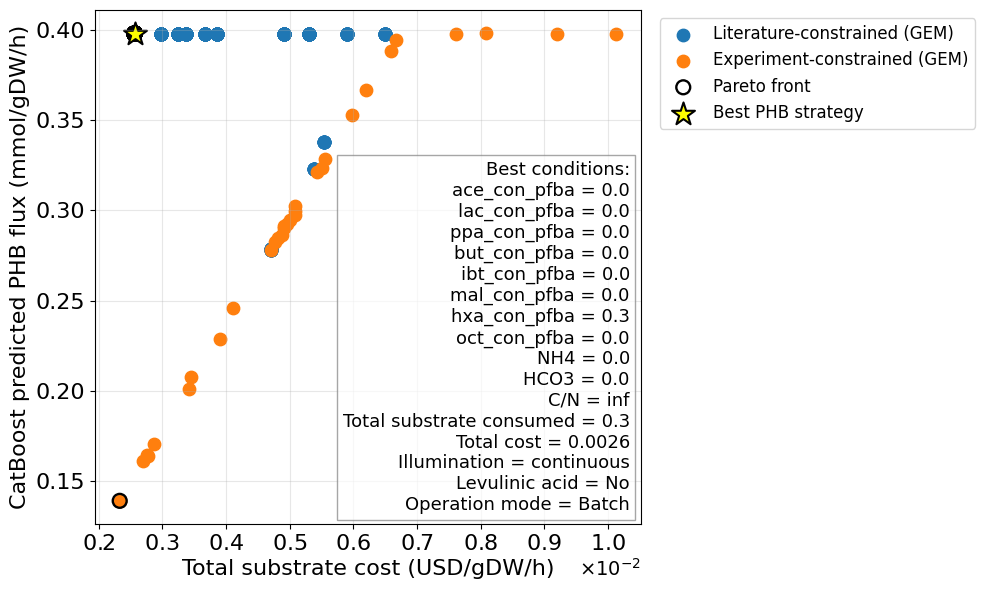


Synthetic ratio sensitivity analysis

Ratio 0:1
Experimental RMSE: 0.0386
Experimental R²:   0.7581

Ratio 1:1
Experimental RMSE: 0.0196
Experimental R²:   0.9378

Ratio 2:1
Experimental RMSE: 0.0090
Experimental R²:   0.9869

Ratio 4:1
Experimental RMSE: 0.0070
Experimental R²:   0.9921

Ratio 8:1
Experimental RMSE: 0.0040
Experimental R²:   0.9974

Ratio 16:1
Experimental RMSE: 0.0041
Experimental R²:   0.9973

Ratio sensitivity summary
   ratio  n_syn  exp_rmse    exp_r2
0      0      0  0.038650  0.758145
1      1     24  0.019600  0.937804
2      2     48  0.008980  0.986942
3      4     96  0.006964  0.992149
4      8    192  0.004002  0.997406
5     16    384  0.004076  0.997310


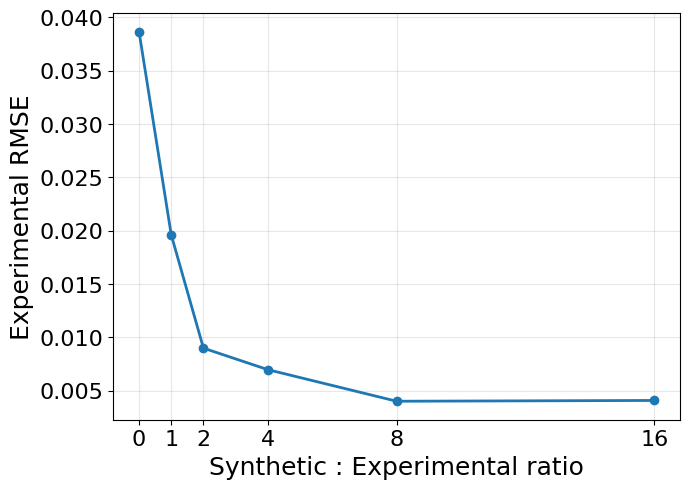


PHB_SYN_UB_VALUE: 1000

Detected substrate columns:
['ace_con_pfba', 'lac_con_pfba', 'ppa_con_pfba', 'but_con_pfba', 'ibt_con_pfba', 'mal_con_pfba', 'hxa_con_pfba', 'oct_con_pfba']

Final feature columns:
['ace_con_pfba', 'lac_con_pfba', 'ppa_con_pfba', 'but_con_pfba', 'ibt_con_pfba', 'mal_con_pfba', 'hxa_con_pfba', 'oct_con_pfba', 'C/N (molar base)_con_pfba', 'total_C_con_pfba', 'total_N_con_pfba', 'total_C_cost_con_pfba', 'total_cost_con_pfba', 'total_N_cost_con_pfba', 'total_hco3_cost_con_pfba']

Categorical features:
['Type of substrate', 'Illumination', 'Levulinic acid', 'Operation mode']
Training on fold [0/5]

bestTest = 0.009438939418
bestIteration = 599

Training on fold [1/5]

bestTest = 0.004094125723
bestIteration = 599

Training on fold [2/5]

bestTest = 0.003574655392
bestIteration = 591

Training on fold [3/5]

bestTest = 0.004527744119
bestIteration = 476

Training on fold [4/5]

bestTest = 0.003796934696
bestIteration = 553


5-fold cross-validation
CV RMSE: 0.0051 ± 

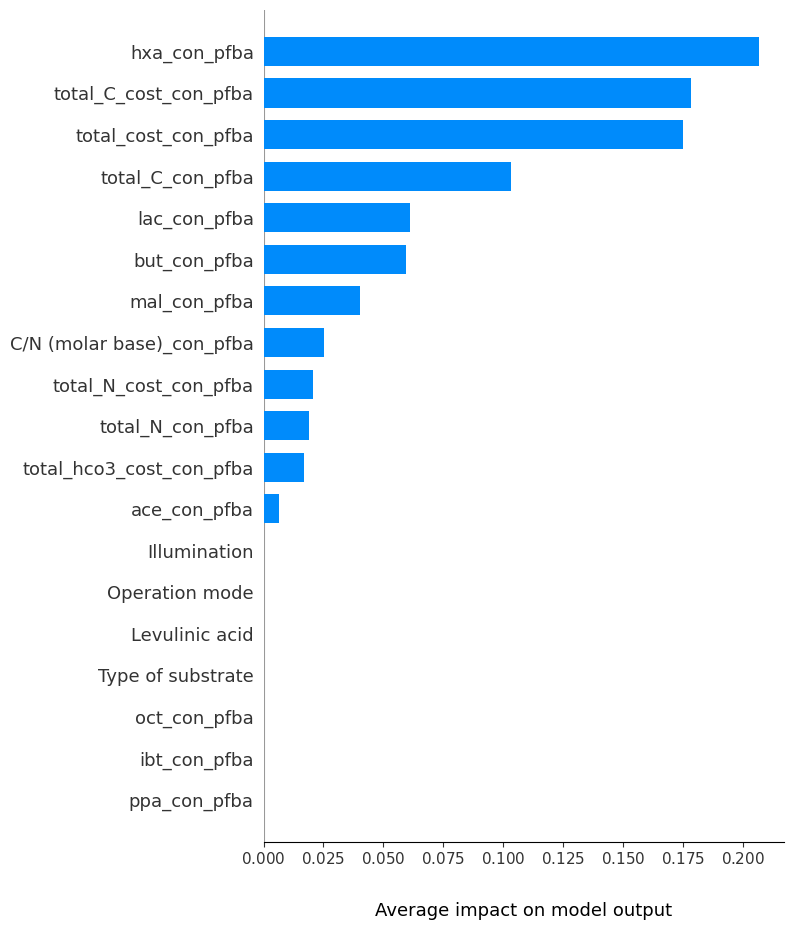

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


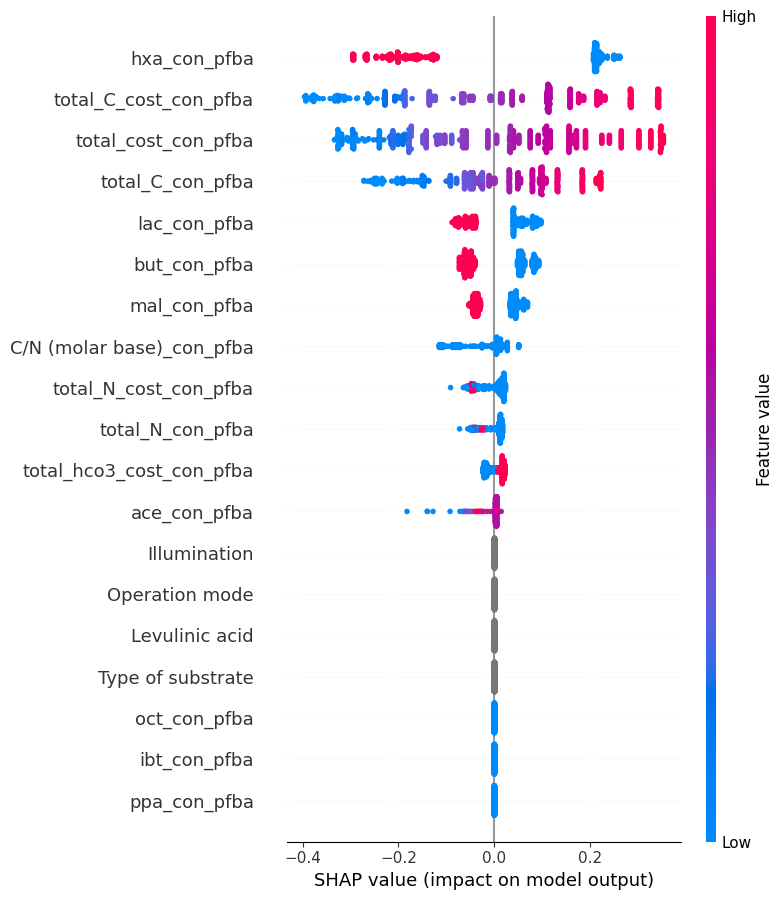


Best CatBoost predicted solution
    Unnamed: 0 Experiment Biomass (mg dw/L) PHB (mg/L)  % PHB PHV (mg/L)  \
245        245         21              1417     238.44  16.83      10.65   

    % PHV 5-ALA (micromol/L) Q10 (mg/g dw) Carotenoids (mg/g dw)  ...  \
245  0.75                NaN           NaN                   NaN  ...   

    total_C_con_pfba_molar PHB_yield_con_pfba total_N_con_pfba  \
245              12.029508           0.989482              0.0   

    total_N_con_pfba_molar C/N (molar base)_con_pfba total_C_cost_con_pfba  \
245                    0.0                       inf              0.022233   

    total_hco3_cost_con_pfba total_N_cost_con_pfba total_cost_con_pfba  \
245                 0.000674                   0.0            0.022907   

    PHB_pred_flux  
245         3.006  

[1 rows x 100 columns]


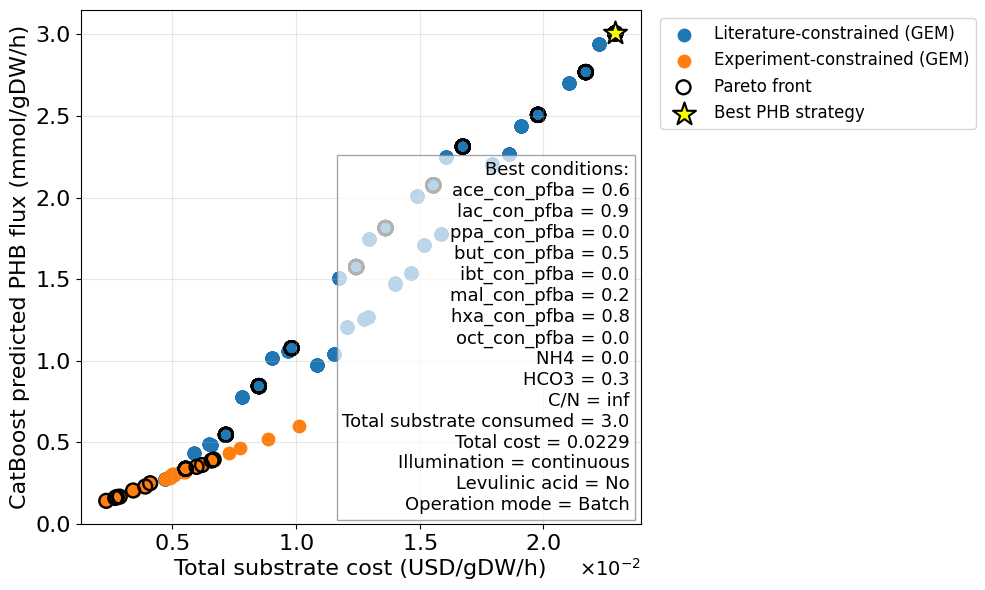


Synthetic ratio sensitivity analysis

Ratio 0:1
Experimental RMSE: 0.0524
Experimental R²:   0.8426

Ratio 1:1
Experimental RMSE: 0.0415
Experimental R²:   0.9013

Ratio 2:1
Experimental RMSE: 0.0371
Experimental R²:   0.9212

Ratio 4:1
Experimental RMSE: 0.0913
Experimental R²:   0.5219

Ratio 8:1
Experimental RMSE: 0.0775
Experimental R²:   0.6555

Ratio 16:1
Experimental RMSE: 0.1025
Experimental R²:   0.3973

Ratio sensitivity summary
   ratio  n_syn  exp_rmse    exp_r2
0      0      0  0.052402  0.842551
1      1     24  0.041487  0.901311
2      2     48  0.037070  0.921205
3      4     96  0.091309  0.521943
4      8    192  0.077515  0.655480
5     16    384  0.102525  0.397289


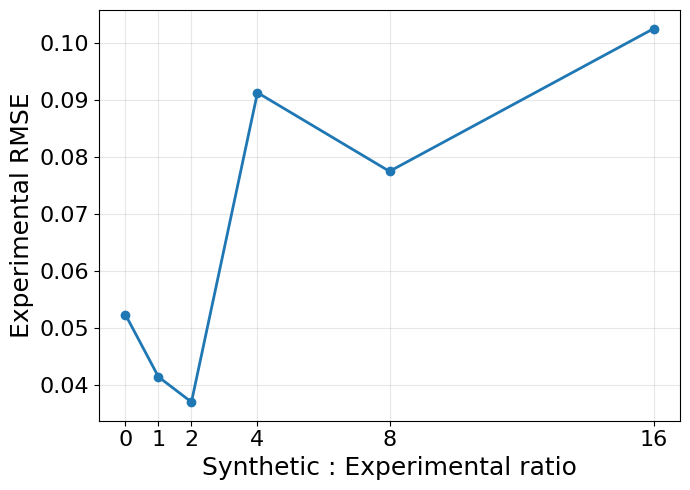

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from catboost import CatBoostRegressor, Pool, cv
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import shap
import joblib


results_summary = []

PHB_SYN_UB_VALUES = [0.3978, 1000]


for PHB_SYN_UB in PHB_SYN_UB_VALUES:

    print(f"\nPHB_SYN_UB_VALUE: {PHB_SYN_UB}")

    PHB_SYN_TAG = f"{PHB_SYN_UB:g}"

    # Load dataset
    df = pd.read_csv(
        PHB_GEM_AUGMENTATION_DIR /
        f"03_Buitron2025_dataset_augmented_VFAs_phb_with_cost_n2_{PHB_SYN_TAG}.csv"
    )

    df = df.copy()

    # Detect substrate columns
    possible_substrates = [
        "ace", "lac", "ppa", "but",
        "ibt", "mal", "hxa", "oct"
    ]

    substrates = [
        c for c in df.columns
        if any(sub in c.lower() for sub in possible_substrates)
        and c.endswith("_pfba")
        and not c.endswith("_con")
        and not c.endswith("_sup")
    ]

    print("\nDetected substrate columns:")
    print(substrates)

    # Feature columns
    extra_features = [
        "C/N (molar base)_con_pfba",
        "total_C_con_pfba",
        "total_N_con_pfba",
        "total_C_cost_con_pfba",
        "total_cost_con_pfba",
        "total_N_cost_con_pfba",
        "total_hco3_cost_con_pfba",
    ]

    extra_features = [
        c for c in extra_features
        if c in df.columns
    ]

    feature_cols = substrates + extra_features

    print("\nFinal feature columns:")
    print(feature_cols)

    # Target
    target = "PHB_model_flux"

    # Categorical features
    cat_features = [
        "Type of substrate",
        "Illumination",
        "Levulinic acid",
        "Operation mode",
    ]

    existing_cat_features = [
        c for c in cat_features
        if c in df.columns
    ]

    print("\nCategorical features:")
    print(existing_cat_features)

    X = df[feature_cols + existing_cat_features]
    y = df[target]

    # Train / test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=0,
        stratify=df["is_experimental"]
    )

    train_pool = Pool(
        X_train,
        y_train,
        cat_features=existing_cat_features
    )

    test_pool = Pool(
        X_test,
        y_test,
        cat_features=existing_cat_features
    )

    # 5-fold cross-validation
    cv_params = {
        "iterations": 600,
        "learning_rate": 0.03,
        "depth": 8,
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "random_seed": 0,
        "verbose": False
    }

    full_pool = Pool(
        X,
        y,
        cat_features=existing_cat_features
    )

    cv_results = cv(
        pool=full_pool,
        params=cv_params,
        fold_count=5,
        shuffle=True,
        partition_random_seed=0
    )

    cv_rmse_mean = cv_results["test-RMSE-mean"].iloc[-1]
    cv_rmse_std = cv_results["test-RMSE-std"].iloc[-1]

    print("\n5-fold cross-validation")
    print(f"CV RMSE: {cv_rmse_mean:.4f} \u00b1 {cv_rmse_std:.4f}")

    with open(
        PHB_CATBOOST_DIR /
        f"04_cv_metrics_CON_PFBA_{PHB_SYN_TAG}.txt",
        "w"
    ) as f:

        f.write(
            f"CV RMSE: {cv_rmse_mean:.4f} \u00b1 {cv_rmse_std:.4f}\n"
        )

    # Train CatBoost model
    model = CatBoostRegressor(
        iterations=600,
        learning_rate=0.03,
        depth=8,
        loss_function="RMSE",
        verbose=100,
        random_seed=0
    )

    model.fit(
        train_pool,
        eval_set=test_pool
    )

    # Standard test-set evaluation
    pred_test = model.predict(test_pool)

    rmse = np.sqrt(
        mean_squared_error(y_test, pred_test)
    )

    r2 = r2_score(
        y_test,
        pred_test
    )

    print("\nStandard test evaluation")
    print(f"RMSE: {rmse:.4f}")
    print(f"R\u00b2:   {r2:.4f}")

    # Save model
    model_save_path = (
        PHB_CATBOOST_DIR /
        f"04_catboost_model_CON_PFBA_{PHB_SYN_TAG}.cbm"
    )

    model.save_model(model_save_path)

    print(f"\nModel saved to:\n{model_save_path}")

    # Retrain on ALL data
    model.fit(
        Pool(
            X,
            y,
            cat_features=existing_cat_features
        )
    )

    df["PHB_pred_flux"] = model.predict(
        Pool(
            X,
            cat_features=existing_cat_features
        )
    )

    # Experimental-domain fit (in-sample)
    exp_mask = df["is_experimental"] == 1

    X_exp = df.loc[
        exp_mask,
        feature_cols + existing_cat_features
    ]

    y_exp = df.loc[
        exp_mask,
        target
    ]

    exp_pool = Pool(
        X_exp,
        y_exp,
        cat_features=existing_cat_features
    )

    exp_pred = model.predict(exp_pool)

    exp_rmse = np.sqrt(
        mean_squared_error(y_exp, exp_pred)
    )

    exp_r2 = r2_score(
        y_exp,
        exp_pred
    )

    print("\nExperimental subset performance (in-sample)")
    print(f"RMSE: {exp_rmse:.4f}")
    print(f"R\u00b2:   {exp_r2:.4f}")

    # Synthetic-domain fit
    syn_mask = df["is_experimental"] == 0

    X_syn = df.loc[
        syn_mask,
        feature_cols + existing_cat_features
    ]

    y_syn = df.loc[
        syn_mask,
        target
    ]

    syn_pool = Pool(
        X_syn,
        y_syn,
        cat_features=existing_cat_features
    )

    syn_pred = model.predict(syn_pool)

    syn_rmse = np.sqrt(
        mean_squared_error(y_syn, syn_pred)
    )

    syn_r2 = r2_score(
        y_syn,
        syn_pred
    )

    print("\nDomain shift check")
    print(f"Experimental RMSE: {exp_rmse:.4f}")
    print(f"Synthetic RMSE:    {syn_rmse:.4f}")

    # SHAP analysis
    explainer = shap.TreeExplainer(
        model,
        feature_perturbation="tree_path_dependent"
    )

    shap_values = explainer.shap_values(X)

    # SHAP bar plot
    plt.figure(figsize=(18, 8))

    shap.summary_plot(
        shap_values,
        X,
        plot_type="bar",
        show=False
    )

    ax = plt.gca()

    ax.xaxis.set_major_formatter(
        mticker.ScalarFormatter(useMathText=True)
    )

    ax.ticklabel_format(
        style='sci',
        axis='x',
        scilimits=(-2, 2)
    )

    offset = ax.xaxis.get_offset_text()

    offset.set_size(11)
    offset.set_x(1.0)
    offset.set_y(-0.10)

    plt.gcf().subplots_adjust(
        left=0.45,
        right=1.1
    )

    plt.xlabel(
        "Average impact on model output",
        fontsize=13,
        labelpad=25
    )

    for ext in ["pdf", "svg", "tiff"]:

        plt.savefig(
            PHB_FIGURES_DIR /
            f"04_catboost_shap_summary_CON_PFBA_{PHB_SYN_TAG}.{ext}",
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

    # SHAP beeswarm
    plt.figure(figsize=(10, 6))

    shap.summary_plot(
        shap_values,
        X,
        show=False
    )

    plt.tight_layout()

    for ext in ["pdf", "svg", "tiff"]:

        plt.savefig(
            PHB_FIGURES_DIR /
            f"04_catboost_shap_swarm_CON_PFBA_{PHB_SYN_TAG}.{ext}",
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

    # Best predicted solution
    best_idx = df["PHB_pred_flux"].idxmax()

    best_solution = df.loc[
        best_idx
    ].to_frame().T

    best_solution.to_csv(
        PHB_CATBOOST_DIR /
        f"04_catboost_optimal_conditions_CON_PFBA_{PHB_SYN_TAG}.csv",
        index=False
    )

    print("\nBest CatBoost predicted solution")
    print(best_solution)

    # Pareto front analysis
    def is_pareto_efficient(costs, maximize_cols=None):

        costs = np.asarray(costs, dtype=float)

        if maximize_cols is not None:
            costs[:, np.atleast_1d(maximize_cols)] *= -1

        n = costs.shape[0]

        is_eff = np.ones(n, dtype=bool)

        for i in range(n):

            if not is_eff[i]:
                continue

            others = np.arange(n) != i

            no_worse = np.all(
                costs[others] <= costs[i],
                axis=1
            )

            strictly_better = np.any(
                costs[others] < costs[i],
                axis=1
            )

            if np.any(no_worse & strictly_better):
                is_eff[i] = False

        return is_eff

    objectives = df[
        ["PHB_pred_flux", "total_C_con_pfba"]
    ].to_numpy()

    objectives = np.round(
        objectives,
        3
    )

    pareto_mask = is_pareto_efficient(
        objectives,
        maximize_cols=[0]
    )

    pareto_solutions = df[pareto_mask]

    best_pareto_idx = (
        pareto_solutions["PHB_pred_flux"]
        .idxmax()
    )

    best_pareto = pareto_solutions.loc[
        [best_pareto_idx]
    ]

    pareto_solutions.to_csv(
        PHB_PARETO_DIR /
        f"04_pareto_optimal_conditions_CON_PFBA_{PHB_SYN_TAG}.csv",
        index=False
    )

    best_pareto.to_csv(
        PHB_PARETO_DIR /
        f"04_best_pareto_conditions_CON_PFBA_{PHB_SYN_TAG}.csv",
        index=False
    )

    # Pareto plot
    COLOR_GEM = "#1f77b4"
    COLOR_EXP = "#ff7f0e"
    COLOR_BEST = "yellow"

    plt.figure(figsize=(10, 6))

    if "is_experimental" in df.columns:

        gem_points = df[
            df["is_experimental"] == 0
        ]

        plt.scatter(
            gem_points["total_cost_con_pfba"],
            gem_points["PHB_pred_flux"],
            color=COLOR_GEM,
            s=80,
            label="Literature-constrained (GEM)"
        )

        exp_points = df[
            df["is_experimental"] == 1
        ]

        plt.scatter(
            exp_points["total_cost_con_pfba"],
            exp_points["PHB_pred_flux"],
            color=COLOR_EXP,
            s=80,
            label="Experiment-constrained (GEM)"
        )

    plt.scatter(
        pareto_solutions["total_cost_con_pfba"],
        pareto_solutions["PHB_pred_flux"],
        facecolors="none",
        edgecolors="black",
        s=100,
        linewidths=1.7,
        label="Pareto front"
    )

    plt.scatter(
        best_pareto["total_cost_con_pfba"],
        best_pareto["PHB_pred_flux"],
        color=COLOR_BEST,
        s=300,
        marker="*",
        edgecolors="black",
        linewidths=1.5,
        label="Best PHB strategy"
    )

    # Annotation block

    best_pareto_row = best_pareto.iloc[0]

    substrates = [
        "ace_con_pfba",
        "lac_con_pfba",
        "ppa_con_pfba",
        "but_con_pfba",
        "ibt_con_pfba",
        "mal_con_pfba",
        "hxa_con_pfba",
        "oct_con_pfba"
    ]

    annotation_lines = []

    for col in substrates:

        if col in best_pareto_row:

            val = best_pareto_row[col]

            if pd.notna(val):

                annotation_lines.append(
                    f"{col} = {abs(float(val)):.1f}"
                )

    if "nh4_con_pfba" in best_pareto_row:

        val = best_pareto_row["nh4_con_pfba"]

        if pd.notna(val):

            annotation_lines.append(
                f"NH4 = {abs(float(val)):.1f}"
            )

    if "hco3_con_pfba" in best_pareto_row:

        val = best_pareto_row["hco3_con_pfba"]

        if pd.notna(val):

            annotation_lines.append(
                f"HCO3 = {abs(float(val)):.1f}"
            )

    if "C/N (molar base)_con_pfba" in best_pareto_row:

        val = best_pareto_row[
            "C/N (molar base)_con_pfba"
        ]

        if pd.notna(val):

            val = abs(float(val))

            display_val = (
                "inf"
                if val > 1e6
                else f"{val:.1f}"
            )

            annotation_lines.append(
                f"C/N = {display_val}"
            )

    if "total_C_con_pfba" in best_pareto_row:

        val = best_pareto_row[
            "total_C_con_pfba"
        ]

        if pd.notna(val):

            annotation_lines.append(
                f"Total substrate consumed = "
                f"{abs(float(val)):.1f}"
            )

    if "total_cost_con_pfba" in best_pareto_row:

        val = best_pareto_row[
            "total_cost_con_pfba"
        ]

        if pd.notna(val):

            annotation_lines.append(
                f"Total cost = "
                f"{abs(float(val)):.4f}"
            )

    for col in existing_cat_features:

        if col == "Type of substrate":
            continue

        if col in best_pareto_row:

            val = best_pareto_row[col]

            if pd.notna(val):

                annotation_lines.append(
                    f"{col} = {val}"
                )

    feature_text = (
        "Best conditions:\n"
        + "\n".join(annotation_lines)
    )

    plt.annotate(
        feature_text,
        xy=(0.98, 0.02),
        xycoords="axes fraction",
        fontsize=13,
        ha="right",
        va="bottom",
        bbox=dict(
            facecolor="white",
            edgecolor="gray",
            alpha=0.7
        )
    )

    plt.xlabel(
        "Total substrate cost (USD/gDW/h)",
        fontsize=16
    )

    plt.ylabel(
        "CatBoost predicted PHB flux (mmol/gDW/h)",
        fontsize=16
    )

    ax = plt.gca()

    ax.ticklabel_format(
        style="scientific",
        axis="x",
        scilimits=(0, 0)
    )

    ax.xaxis.get_major_formatter().set_useMathText(True)

    ax.tick_params(
        axis="x",
        labelsize=14
    )

    offset = ax.xaxis.get_offset_text()

    offset.set_fontsize(14)
    offset.set_x(1.0)
    offset.set_y(-0.10)

    plt.grid(True, alpha=0.3)

    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    plt.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        fontsize=12
    )

    plt.tight_layout()

    for ext in ["pdf", "svg", "tiff"]:

        plt.savefig(
            PHB_FIGURES_DIR /
            f"04_PHB_catboost_pareto_plot_CON_PFBA_{PHB_SYN_TAG}.{ext}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

    # Save summary metrics

    results_summary.append({

        "PHB_SYN_UB": PHB_SYN_UB,

        "rmse": rmse,
        "r2": r2,

        "cv_rmse_mean": cv_rmse_mean,
        "cv_rmse_std": cv_rmse_std,

        "exp_rmse": exp_rmse,
        "exp_r2": exp_r2,

        "syn_rmse": syn_rmse,
        "syn_r2": syn_r2
    })

    # Synthetic ratio sensitivity analysis
    print("\nSynthetic ratio sensitivity analysis")

    exp_df = df[
        df["is_experimental"] == 1
    ].copy()

    syn_df = df[
        df["is_experimental"] == 0
    ].copy()

    exp_train_df, exp_test_df = train_test_split(
        exp_df,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )

    ratios = [0, 1, 2, 4, 8, 16]

    ratio_results = []

    for ratio in ratios:

        print(f"\nRatio {ratio}:1")

        n_exp_train = len(exp_train_df)

        n_syn = min(
            len(syn_df),
            ratio * n_exp_train
        )

        syn_subset = syn_df.sample(
            n=n_syn,
            random_state=42
        )

        train_df_ratio = pd.concat(
            [exp_train_df, syn_subset],
            ignore_index=True
        )

        X_train_ratio = train_df_ratio[
            feature_cols + existing_cat_features
        ]

        y_train_ratio = train_df_ratio[target]

        X_test_exp = exp_test_df[
            feature_cols + existing_cat_features
        ]

        y_test_exp = exp_test_df[target]

        train_pool_ratio = Pool(
            X_train_ratio,
            y_train_ratio,
            cat_features=existing_cat_features
        )

        test_pool_exp = Pool(
            X_test_exp,
            y_test_exp,
            cat_features=existing_cat_features
        )

        model_ratio = CatBoostRegressor(
            iterations=600,
            learning_rate=0.03,
            depth=8,
            loss_function="RMSE",
            verbose=False,
            random_seed=42
        )

        model_ratio.fit(train_pool_ratio)

        pred_exp = model_ratio.predict(
            test_pool_exp
        )

        exp_rmse_ratio = np.sqrt(
            mean_squared_error(
                y_test_exp,
                pred_exp
            )
        )

        exp_r2_ratio = r2_score(
            y_test_exp,
            pred_exp
        )

        print(f"Experimental RMSE: {exp_rmse_ratio:.4f}")
        print(f"Experimental R\u00b2:   {exp_r2_ratio:.4f}")

        ratio_results.append({
            "ratio": ratio,
            "n_syn": n_syn,
            "exp_rmse": exp_rmse_ratio,
            "exp_r2": exp_r2_ratio
        })

    ratio_results_df = pd.DataFrame(
        ratio_results
    )

    print("\nRatio sensitivity summary")
    print(ratio_results_df)

    ratio_results_df.to_csv(
        PHB_CATBOOST_DIR /
        f"synthetic_ratio_sensitivity_CON_PFBA_{PHB_SYN_TAG}.csv",
        index=False
    )

    # Sensitivity plot
    plt.figure(figsize=(7, 5))

    plt.plot(
        ratio_results_df["ratio"],
        ratio_results_df["exp_rmse"],
        marker="o",
        linewidth=2
    )

    plt.xlabel(
        "Synthetic : Experimental ratio",
        fontsize=18
    )

    plt.ylabel(
        "Experimental RMSE",
        fontsize=18
    )

    plt.xticks(
        ratio_results_df["ratio"],
        fontsize=16
    )

    plt.yticks(fontsize=16)

    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    for ext in ["pdf", "svg", "tiff"]:

        plt.savefig(
            PHB_FIGURES_DIR /
            f"synthetic_ratio_sensitivity_rmse_CON_PFBA_{PHB_SYN_TAG}.{ext}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

pd.DataFrame(results_summary).to_csv(
    PHB_CATBOOST_DIR /
    "synthetic_ratio_sensitivity_CON_PFBA_all_PHB_SYN_UB.csv",
    index=False
)

## *C.1 Version with SHAP plot (supplemented and consumed in FBA)


PHB_SYN_UB value: 0.3978

Detected substrate columns:
['ace_sup', 'ace_con', 'ace_con_pfba', 'lac_sup', 'lac_con', 'lac_con_pfba', 'ppa_sup', 'ppa_con', 'ppa_con_pfba', 'but_sup', 'but_con', 'but_con_pfba', 'ibt_sup', 'ibt_con', 'ibt_con_pfba', 'mal_sup', 'mal_con', 'mal_con_pfba', 'hxa_sup', 'hxa_con', 'hxa_con_pfba', 'oct_sup', 'oct_con', 'oct_con_pfba']

Final feature columns:
['ace_sup', 'ace_con', 'lac_sup', 'lac_con', 'ppa_sup', 'ppa_con', 'but_sup', 'but_con', 'ibt_sup', 'ibt_con', 'mal_sup', 'mal_con', 'hxa_sup', 'hxa_con', 'oct_sup', 'oct_con', 'C/N (molar base)_sup', 'total_C_sup', 'total_N_sup', 'total_C_cost_sup', 'total_cost_sup', 'total_N_cost_sup', 'total_hco3_cost_sup', 'C/N (molar base)_con', 'total_C_con', 'total_N_con', 'total_C_cost_con', 'total_cost_con', 'total_N_cost_con', 'total_hco3_cost_con']

Using combined PHB flux target

Categorical features used:
['Type of substrate', 'Illumination', 'Levulinic acid', 'Operation mode']
Training on fold [0/5]

bestTest = 

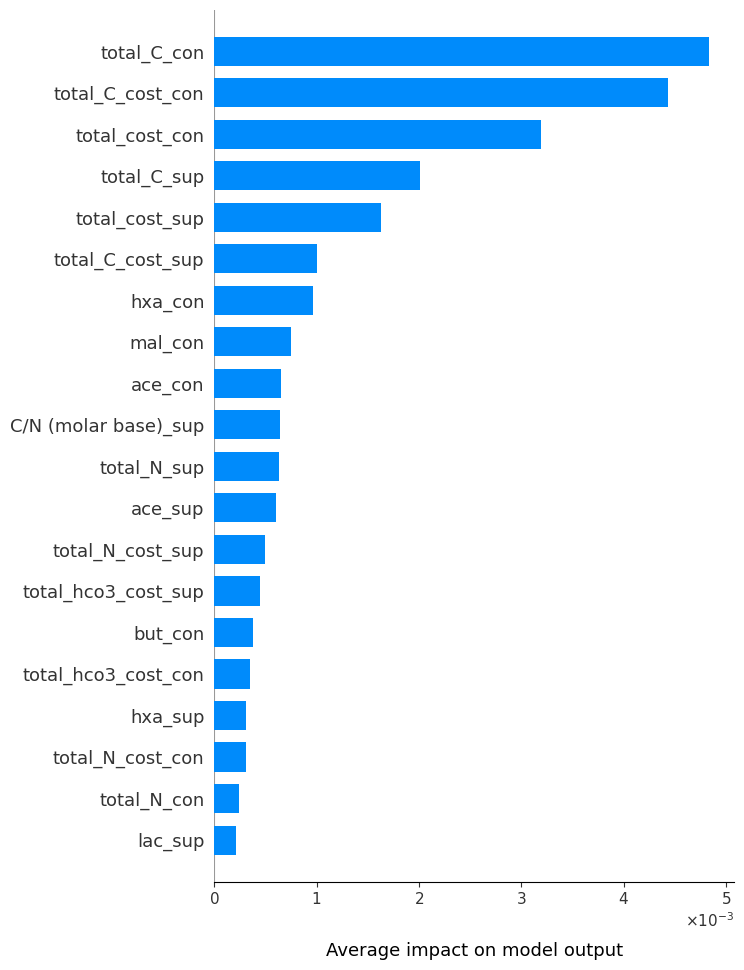

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


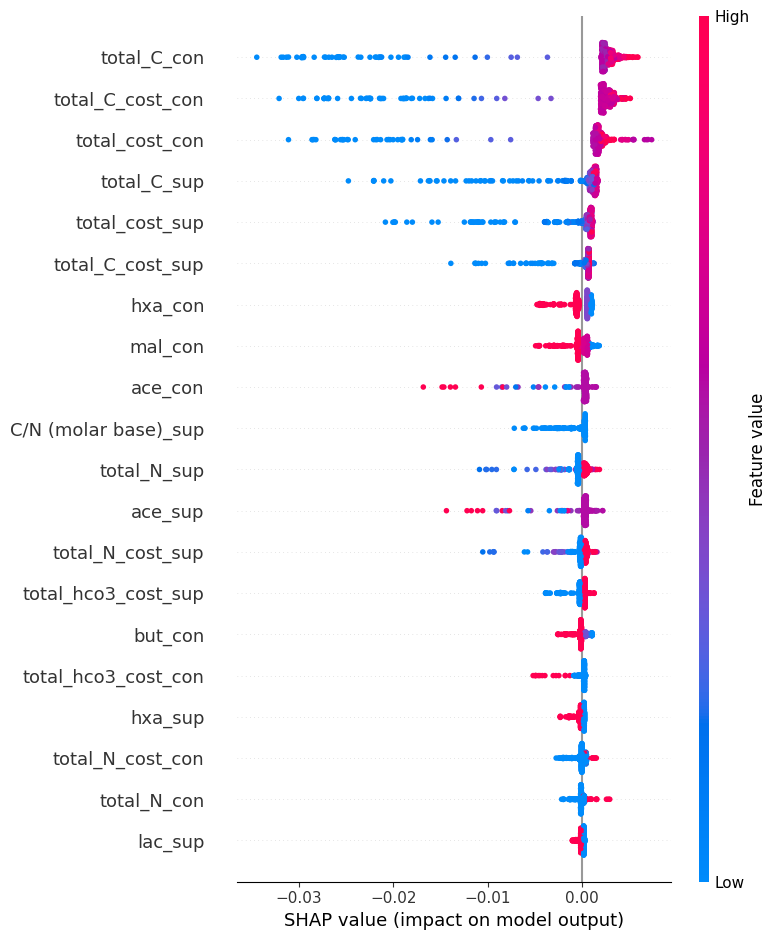


Best CatBoost predicted solution
    Unnamed: 0 Experiment Biomass (mg dw/L) PHB (mg/L)  % PHB PHV (mg/L)  \
355        355         21              1417     238.44  16.83      10.65   

    % PHV 5-ALA (micromol/L) Q10 (mg/g dw) Carotenoids (mg/g dw)  ...  \
355  0.75                NaN           NaN                   NaN  ...   

    total_C_con_pfba_molar PHB_yield_con_pfba total_N_con_pfba  \
355               2.625457           0.499874              0.0   

    total_N_con_pfba_molar C/N (molar base)_con_pfba total_C_cost_con_pfba  \
355                    0.0                       inf              0.004905   

    total_hco3_cost_con_pfba total_N_cost_con_pfba total_cost_con_pfba  \
355                      0.0                   0.0            0.004905   

    PHB_pred_flux  
355      0.398093  

[1 rows x 100 columns]


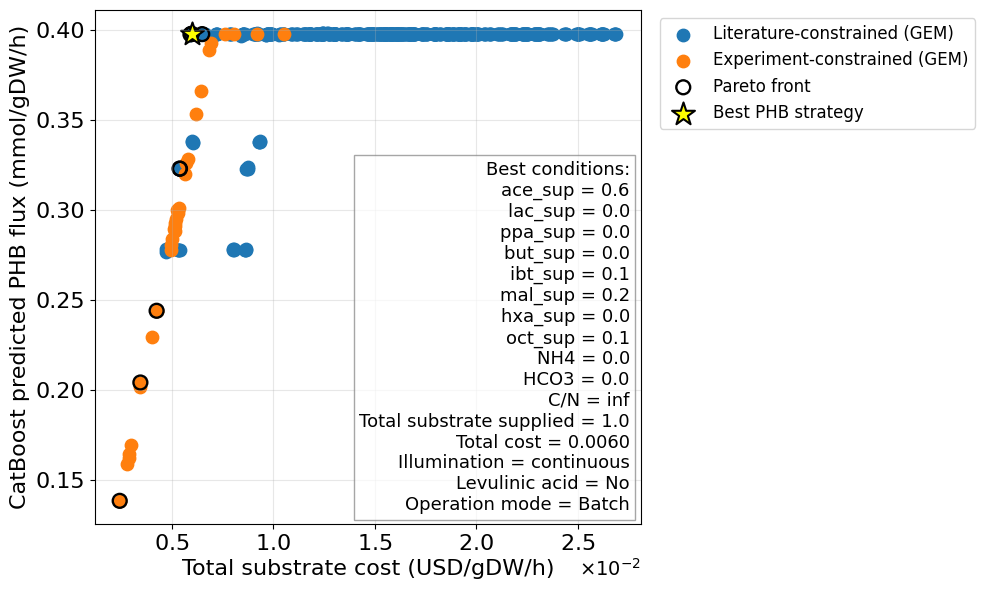


Synthetic ratio sensitivity analysis

Ratio 0:1
Experimental RMSE: 0.0049
Experimental R²:   0.9961

Ratio 1:1
Experimental RMSE: 0.0049
Experimental R²:   0.9962

Ratio 2:1
Experimental RMSE: 0.0044
Experimental R²:   0.9968

Ratio 4:1
Experimental RMSE: 0.0051
Experimental R²:   0.9958

Ratio 8:1
Experimental RMSE: 0.0058
Experimental R²:   0.9946

Ratio 16:1
Experimental RMSE: 0.0053
Experimental R²:   0.9955

Ratio sensitivity summary
   ratio  n_syn  exp_rmse    exp_r2
0      0      0  0.004908  0.996101
1      1     24  0.004857  0.996181
2      2     48  0.004446  0.996799
3      4     96  0.005065  0.995847
4      8    192  0.005752  0.994642
5     16    384  0.005257  0.995525


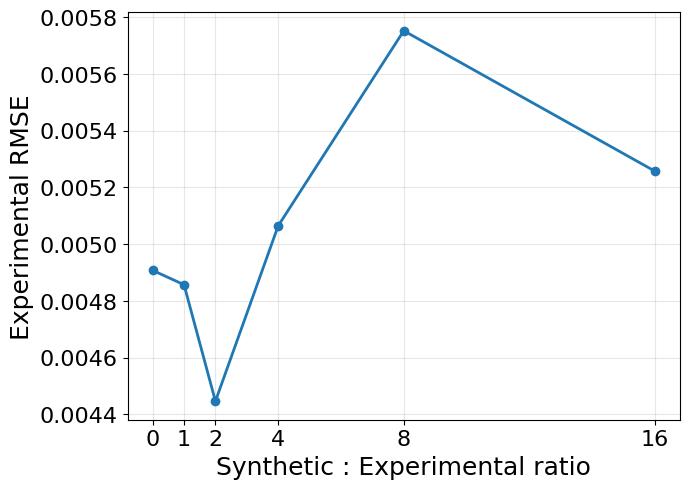


PHB_SYN_UB value: 1000

Detected substrate columns:
['ace_sup', 'ace_con', 'ace_con_pfba', 'lac_sup', 'lac_con', 'lac_con_pfba', 'ppa_sup', 'ppa_con', 'ppa_con_pfba', 'but_sup', 'but_con', 'but_con_pfba', 'ibt_sup', 'ibt_con', 'ibt_con_pfba', 'mal_sup', 'mal_con', 'mal_con_pfba', 'hxa_sup', 'hxa_con', 'hxa_con_pfba', 'oct_sup', 'oct_con', 'oct_con_pfba']

Final feature columns:
['ace_sup', 'ace_con', 'lac_sup', 'lac_con', 'ppa_sup', 'ppa_con', 'but_sup', 'but_con', 'ibt_sup', 'ibt_con', 'mal_sup', 'mal_con', 'hxa_sup', 'hxa_con', 'oct_sup', 'oct_con', 'C/N (molar base)_sup', 'total_C_sup', 'total_N_sup', 'total_C_cost_sup', 'total_cost_sup', 'total_N_cost_sup', 'total_hco3_cost_sup', 'C/N (molar base)_con', 'total_C_con', 'total_N_con', 'total_C_cost_con', 'total_cost_con', 'total_N_cost_con', 'total_hco3_cost_con']

Using combined PHB flux target

Categorical features used:
['Type of substrate', 'Illumination', 'Levulinic acid', 'Operation mode']
Training on fold [0/5]

bestTest = 0.

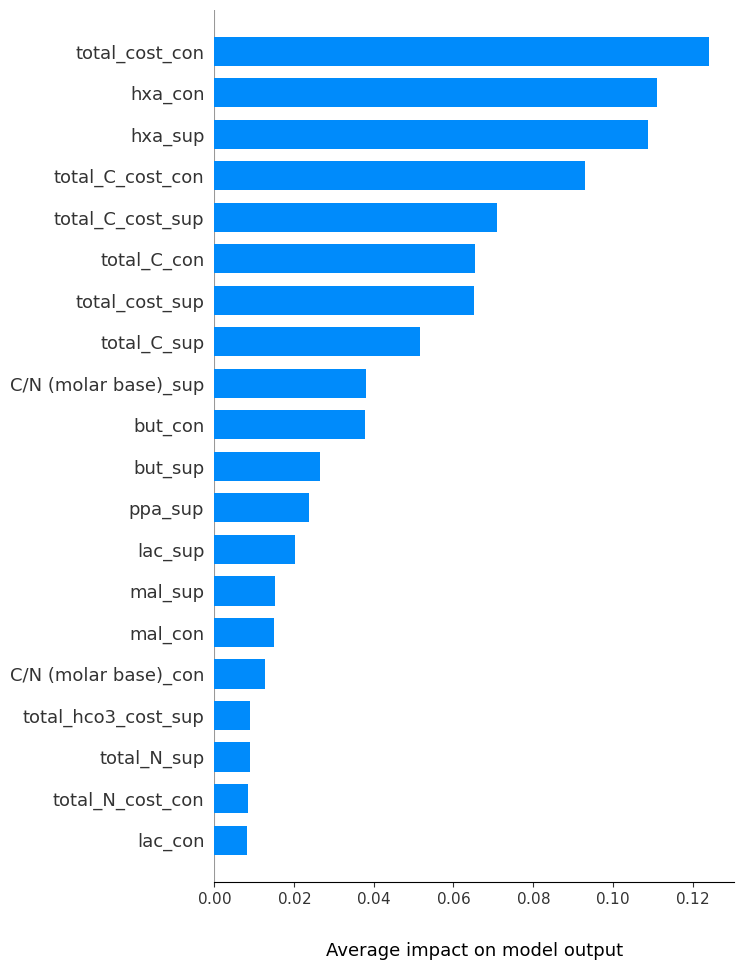

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


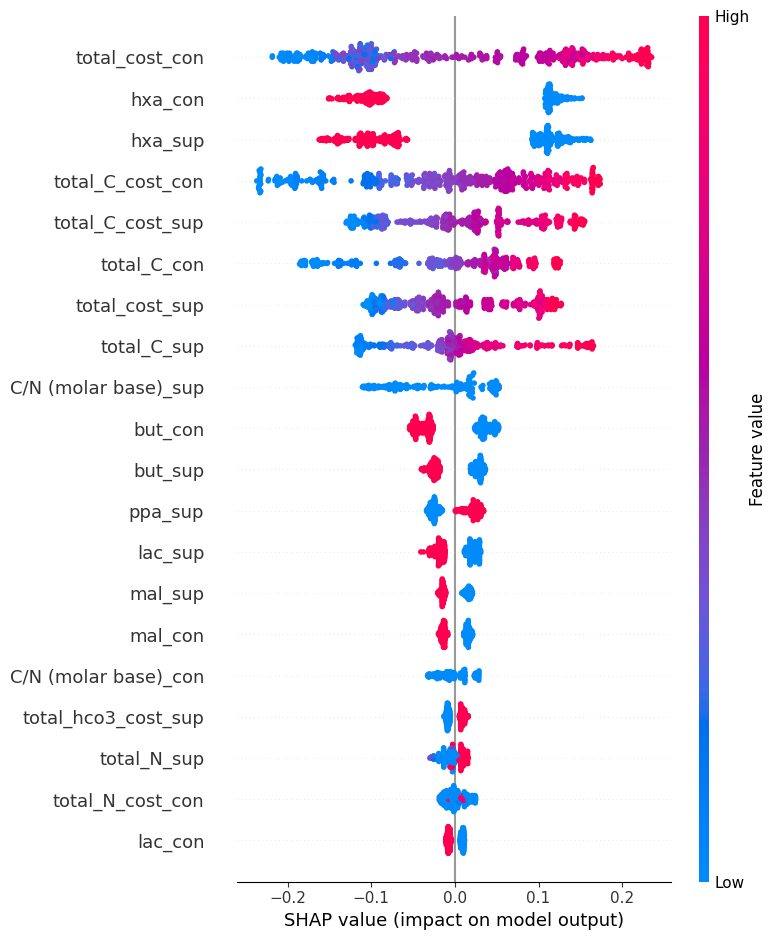


Best CatBoost predicted solution
    Unnamed: 0 Experiment Biomass (mg dw/L) PHB (mg/L)  % PHB PHV (mg/L)  \
246        246         21              1417     238.44  16.83      10.65   

    % PHV 5-ALA (micromol/L) Q10 (mg/g dw) Carotenoids (mg/g dw)  ...  \
246  0.75                NaN           NaN                   NaN  ...   

    total_C_con_pfba_molar PHB_yield_con_pfba total_N_con_pfba  \
246              12.029508           0.989482              0.0   

    total_N_con_pfba_molar C/N (molar base)_con_pfba total_C_cost_con_pfba  \
246                    0.0                       inf              0.022233   

    total_hco3_cost_con_pfba total_N_cost_con_pfba total_cost_con_pfba  \
246                 0.000674                   0.0            0.022907   

    PHB_pred_flux  
246      3.009876  

[1 rows x 100 columns]


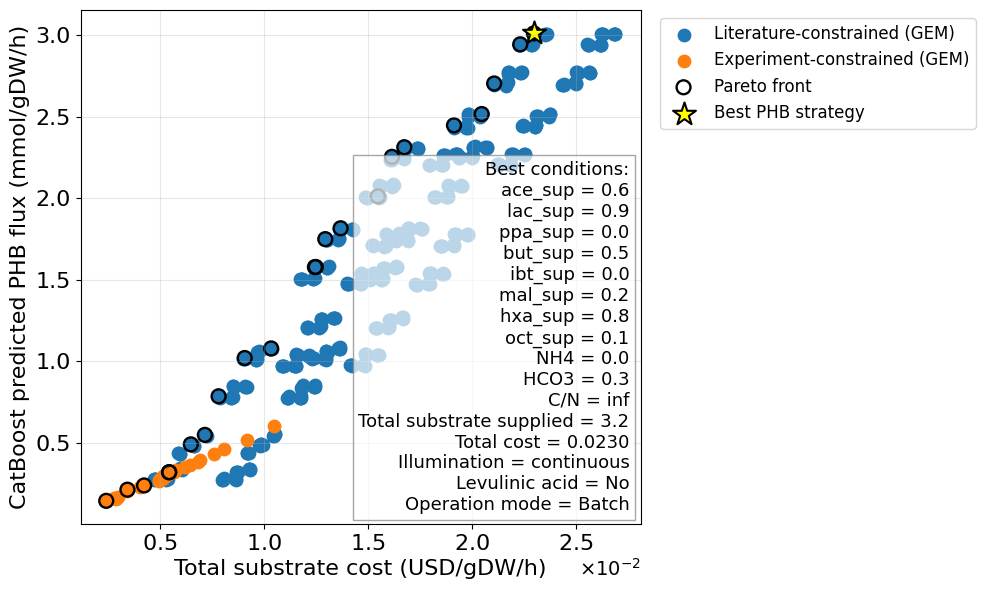


Synthetic ratio sensitivity analysis

Ratio 0:1
Experimental RMSE: 0.0345
Experimental R²:   0.9318

Ratio 1:1
Experimental RMSE: 0.0097
Experimental R²:   0.9946

Ratio 2:1
Experimental RMSE: 0.0134
Experimental R²:   0.9897

Ratio 4:1
Experimental RMSE: 0.0354
Experimental R²:   0.9283

Ratio 8:1
Experimental RMSE: 0.0821
Experimental R²:   0.6136

Ratio 16:1
Experimental RMSE: 0.0523
Experimental R²:   0.8430

Ratio sensitivity summary
   ratio  n_syn  exp_rmse    exp_r2
0      0      0  0.034489  0.931795
1      1     24  0.009743  0.994558
2      2     48  0.013387  0.989724
3      4     96  0.035362  0.928298
4      8    192  0.082093  0.613583
5     16    384  0.052335  0.842950


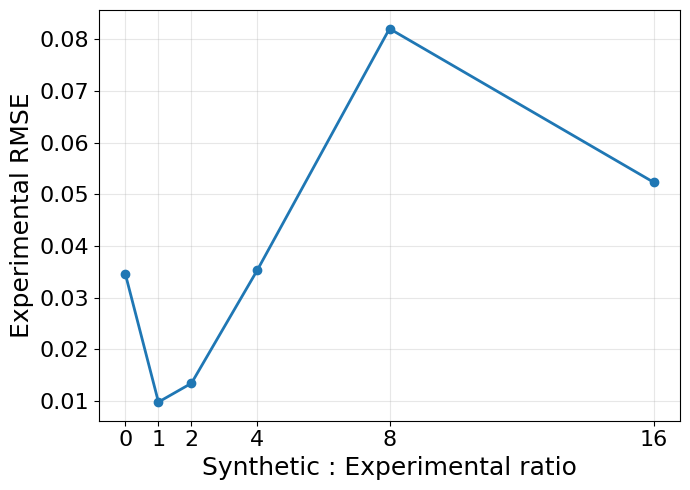

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from catboost import CatBoostRegressor, Pool, cv
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import shap
import joblib


PHB_SYN_UB_VALUES = [0.3978, 1000]

results_summary = []

for PHB_SYN_UB in PHB_SYN_UB_VALUES:

    print(f"\nPHB_SYN_UB value: {PHB_SYN_UB}")

    PHB_SYN_TAG = f"{PHB_SYN_UB:g}"

    df = pd.read_csv(
        PHB_GEM_AUGMENTATION_DIR /
        f"03_Buitron2025_dataset_augmented_VFAs_phb_with_cost_n2_{PHB_SYN_TAG}.csv"
    ).copy()

    # Detect substrate columns

    possible_substrates = [
        "ace", "lac", "ppa", "but",
        "ibt", "mal", "hxa", "oct"
    ]

    detected_substrates = []

    for sub in possible_substrates:
        matches = (
            c for c in df.columns
            if sub.lower() in c.lower()
        )
        detected_substrates.extend(matches)

    print("\nDetected substrate columns:")
    print(detected_substrates)

    # Feature columns

    substrates = [
        c for c in df.columns
        if any(sub in c.lower() for sub in possible_substrates)
        and not c.endswith("_con_pfba")
    ]

    extra_features = [
        "C/N (molar base)_sup",
        "total_C_sup",
        "total_N_sup",
        "total_C_cost_sup",
        "total_cost_sup",
        "total_N_cost_sup",
        "total_hco3_cost_sup",
        "C/N (molar base)_con",
        "total_C_con",
        "total_N_con",
        "total_C_cost_con",
        "total_cost_con",
        "total_N_cost_con",
        "total_hco3_cost_con"
    ]

    extra_features = [
        c for c in extra_features
        if c in df.columns
    ]

    feature_cols = substrates + extra_features

    print("\nFinal feature columns:")
    print(feature_cols)

    # Target

    target = "PHB_model_flux"
    y = df[target]

    print("\nUsing combined PHB flux target")

    # Categorical features

    cat_features = [
        "Type of substrate",
        "Illumination",
        "Levulinic acid",
        "Operation mode",
    ]

    existing_cat_features = [
        c for c in cat_features
        if c in df.columns
    ]

    print("\nCategorical features used:")
    print(existing_cat_features)

    X = df[feature_cols + existing_cat_features]

    # Train / test split

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=0,
        stratify=df["is_experimental"]
    )

    train_pool = Pool(
        X_train,
        y_train,
        cat_features=existing_cat_features
    )

    test_pool = Pool(
        X_test,
        y_test,
        cat_features=existing_cat_features
    )

    # Cross-validation

    cv_params = {
        "iterations": 600,
        "learning_rate": 0.03,
        "depth": 8,
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "random_seed": 0,
        "verbose": False
    }

    full_pool = Pool(
        X,
        y,
        cat_features=existing_cat_features
    )

    cv_results = cv(
        pool=full_pool,
        params=cv_params,
        fold_count=5,
        shuffle=True,
        partition_random_seed=0
    )

    cv_rmse_mean = cv_results["test-RMSE-mean"].iloc[-1]
    cv_rmse_std = cv_results["test-RMSE-std"].iloc[-1]

    print("\n5-fold cross-validation results")
    print(f"CV RMSE: {cv_rmse_mean:.4f} \u00b1 {cv_rmse_std:.4f}")

    with open(
        PHB_CATBOOST_DIR /
        f"04_cv_metrics_SUP_CON_{PHB_SYN_TAG}.txt",
        "w"
    ) as f:
        f.write(
            f"CV RMSE: {cv_rmse_mean:.4f} \u00b1 "
            f"{cv_rmse_std:.4f}\n"
        )

    # Train CatBoost model

    model = CatBoostRegressor(
        iterations=600,
        learning_rate=0.03,
        depth=8,
        loss_function="RMSE",
        verbose=100,
        random_seed=0
    )

    model.fit(train_pool, eval_set=test_pool)

    pred_test = model.predict(test_pool)

    rmse = np.sqrt(
        mean_squared_error(y_test, pred_test)
    )

    r2 = r2_score(y_test, pred_test)

    print("\nCatBoost performance")
    print(f"RMSE: {rmse:.4f}")
    print(f"R\u00b2: {r2:.4f}")

    # Save model

    model_save_path = (
        PHB_CATBOOST_DIR /
        f"04_catboost_model_SUP_CON_{PHB_SYN_TAG}.cbm"
    )

    model.save_model(model_save_path)

    print(f"\nCatBoost model saved to:")
    print(model_save_path)

    # Retrain on full dataset

    model.fit(
        Pool(
            X,
            y,
            cat_features=existing_cat_features
        )
    )

    df["PHB_pred_flux"] = model.predict(
        Pool(
            X,
            cat_features=existing_cat_features
        )
    )

    # Experimental-only evaluation

    exp_mask = df["is_experimental"] == 1

    X_exp = df.loc[
        exp_mask,
        feature_cols + existing_cat_features
    ]

    y_exp = df.loc[exp_mask, target]

    exp_pool = Pool(
        X_exp,
        y_exp,
        cat_features=existing_cat_features
    )

    exp_pred = model.predict(exp_pool)

    exp_rmse = np.sqrt(
        mean_squared_error(y_exp, exp_pred)
    )

    exp_r2 = r2_score(y_exp, exp_pred)

    print("\nExperimental-only evaluation")
    print(f"Experimental RMSE: {exp_rmse:.4f}")
    print(f"Experimental R\u00b2: {exp_r2:.4f}")

    # Synthetic-only evaluation

    syn_mask = df["is_experimental"] == 0

    syn_pred = model.predict(
        Pool(
            df.loc[
                syn_mask,
                feature_cols + existing_cat_features
            ],
            cat_features=existing_cat_features
        )
    )

    syn_rmse = np.sqrt(
        mean_squared_error(
            df.loc[syn_mask, target],
            syn_pred
        )
    )

    syn_r2 = r2_score(
        df.loc[syn_mask, target],
        syn_pred
    )

    print("\nDomain shift evaluation")
    print(f"Synthetic RMSE: {syn_rmse:.4f}")
    print(f"Synthetic R\u00b2: {syn_r2:.4f}")

    # SHAP analysis

    explainer = shap.TreeExplainer(
        model,
        feature_perturbation="tree_path_dependent"
    )

    shap_values = explainer.shap_values(X)

    # SHAP summary bar plot

    plt.figure(figsize=(18, 8))

    shap.summary_plot(
        shap_values,
        X,
        plot_type="bar",
        show=False
    )

    ax = plt.gca()

    ax.ticklabel_format(
        style="scientific",
        axis="x",
        scilimits=(0, 0)
    )

    ax.xaxis.get_major_formatter().set_useMathText(True)

    ax.xaxis.set_major_formatter(
        mticker.ScalarFormatter(useMathText=True)
    )

    ax.ticklabel_format(
        style="sci",
        axis="x",
        scilimits=(-2, 2)
    )

    offset = ax.xaxis.get_offset_text()
    offset.set_size(11)
    offset.set_x(1.0)
    offset.set_y(-0.10)

    plt.gcf().subplots_adjust(left=0.45, right=1.1)

    plt.xlabel(
        "Average impact on model output",
        fontsize=13,
        labelpad=25
    )

    for ext in ["pdf", "svg", "tiff"]:
        plt.savefig(
            PHB_FIGURES_DIR /
            f"04_catboost_shap_summary_SUP_CON_{PHB_SYN_TAG}.{ext}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

    # SHAP beeswarm plot

    plt.figure(figsize=(10, 6))

    shap.summary_plot(
        shap_values,
        X,
        show=False
    )

    plt.tight_layout()

    for ext in ["pdf", "svg", "tiff"]:
        plt.savefig(
            PHB_FIGURES_DIR /
            f"04_catboost_shap_swarm_SUP_CON_{PHB_SYN_TAG}.{ext}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

    # Best predicted solution

    best_idx = df["PHB_pred_flux"].idxmax()

    best_solution = df.loc[
        best_idx
    ].to_frame().T

    best_solution.to_csv(
        PHB_CATBOOST_DIR /
        f"04_catboost_optimal_conditions_SUP_CON_{PHB_SYN_TAG}.csv",
        index=False
    )

    print("\nBest CatBoost predicted solution")
    print(best_solution)

    # Pareto analysis

    def is_pareto_efficient(costs, maximize_cols=None):

        costs = np.asarray(costs, dtype=float)

        if maximize_cols is not None:
            costs[:, np.atleast_1d(maximize_cols)] *= -1

        n = costs.shape[0]

        is_eff = np.ones(n, dtype=bool)

        for i in range(n):

            if not is_eff[i]:
                continue

            others = np.arange(n) != i

            no_worse = np.all(
                costs[others] <= costs[i],
                axis=1
            )

            strictly_better = np.any(
                costs[others] < costs[i],
                axis=1
            )

            if np.any(no_worse & strictly_better):
                is_eff[i] = False

        return is_eff

    objectives = df[
        ["PHB_pred_flux", "total_cost_sup"]
    ].to_numpy()

    objectives = np.round(objectives, 3)

    pareto_mask = is_pareto_efficient(
        objectives,
        maximize_cols=[0]
    )

    pareto_solutions = df[pareto_mask]

    best_pareto_idx = (
        pareto_solutions["PHB_pred_flux"]
        .idxmax()
    )

    best_pareto = pareto_solutions.loc[
        [best_pareto_idx]
    ]

    pareto_solutions.to_csv(
        PHB_PARETO_DIR /
        f"04_pareto_optimal_conditions_SUP_CON_{PHB_SYN_TAG}.csv",
        index=False
    )

    best_pareto.to_csv(
        PHB_PARETO_DIR /
        f"04_best_pareto_conditions_SUP_CON_{PHB_SYN_TAG}.csv",
        index=False
    )

    # Pareto plot

    COLOR_GEM = "#1f77b4"
    COLOR_EXP = "#ff7f0e"
    COLOR_BEST = "yellow"

    plt.figure(figsize=(10, 6))

    if "is_experimental" in df.columns:

        gem_points = df[
            df["is_experimental"] == 0
        ]

        plt.scatter(
            gem_points["total_cost_sup"],
            gem_points["PHB_pred_flux"],
            color=COLOR_GEM,
            s=80,
            label="Literature-constrained (GEM)"
        )

        exp_points = df[
            df["is_experimental"] == 1
        ]

        plt.scatter(
            exp_points["total_cost_sup"],
            exp_points["PHB_pred_flux"],
            color=COLOR_EXP,
            s=80,
            label="Experiment-constrained (GEM)"
        )

    plt.scatter(
        pareto_solutions["total_cost_sup"],
        pareto_solutions["PHB_pred_flux"],
        facecolors="none",
        edgecolors="black",
        s=100,
        linewidths=1.7,
        label="Pareto front"
    )

    plt.scatter(
        best_pareto["total_cost_sup"],
        best_pareto["PHB_pred_flux"],
        color=COLOR_BEST,
        s=300,
        marker="*",
        edgecolors="black",
        linewidths=1.5,
        label="Best PHB strategy"
    )

    # Annotation block

    best_pareto_row = best_pareto.iloc[0]

    substrates = [
        "ace_sup", "lac_sup", "ppa_sup", "but_sup",
        "ibt_sup", "mal_sup", "hxa_sup", "oct_sup"
    ]

    annotation_lines = []

    for col in substrates:

        if col in best_pareto_row:

            val = best_pareto_row[col]

            if pd.notna(val):
                annotation_lines.append(
                    f"{col} = {abs(float(val)):.1f}"
                )

    if "nh4_sup" in best_pareto_row:

        val = best_pareto_row["nh4_sup"]

        if pd.notna(val):
            annotation_lines.append(
                f"NH4 = {abs(float(val)):.1f}"
            )

    if "hco3_sup" in best_pareto_row:

        val = best_pareto_row["hco3_sup"]

        if pd.notna(val):
            annotation_lines.append(
                f"HCO3 = {abs(float(val)):.1f}"
            )

    if "C/N (molar base)_sup" in best_pareto_row:

        val = best_pareto_row[
            "C/N (molar base)_sup"
        ]

        if pd.notna(val):

            val = abs(float(val))

            display_val = (
                "inf"
                if val > 1e6
                else f"{val:.1f}"
            )

            annotation_lines.append(
                f"C/N = {display_val}"
            )

    if "total_C_sup" in best_pareto_row:

        val = best_pareto_row["total_C_sup"]

        if pd.notna(val):
            annotation_lines.append(
                f"Total substrate supplied = "
                f"{abs(float(val)):.1f}"
            )

    if "total_cost_sup" in best_pareto_row:

        val = best_pareto_row["total_cost_sup"]

        if pd.notna(val):
            annotation_lines.append(
                f"Total cost = "
                f"{abs(float(val)):.4f}"
            )

    for col in existing_cat_features:

        if col == "Type of substrate":
            continue

        if col in best_pareto_row:

            val = best_pareto_row[col]

            if pd.notna(val):
                annotation_lines.append(
                    f"{col} = {val}"
                )

    feature_text = (
        "Best conditions:\n"
        + "\n".join(annotation_lines)
    )

    plt.annotate(
        feature_text,
        xy=(0.98, 0.02),
        xycoords="axes fraction",
        fontsize=13,
        ha="right",
        va="bottom",
        bbox=dict(
            facecolor="white",
            edgecolor="gray",
            alpha=0.7
        )
    )

    plt.xlabel(
        "Total substrate cost (USD/gDW/h)",
        fontsize=16
    )

    plt.ylabel(
        "CatBoost predicted PHB flux (mmol/gDW/h)",
        fontsize=16
    )

    ax = plt.gca()

    ax.ticklabel_format(
        style="scientific",
        axis="x",
        scilimits=(0, 0)
    )

    ax.xaxis.get_major_formatter().set_useMathText(True)

    ax.tick_params(
        axis="x",
        labelsize=14
    )

    offset = ax.xaxis.get_offset_text()

    offset.set_fontsize(14)
    offset.set_x(1.0)
    offset.set_y(-0.10)

    plt.grid(True, alpha=0.3)

    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    plt.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        fontsize=12
    )

    plt.tight_layout()

    for ext in ["pdf", "svg", "tiff"]:

        plt.savefig(
            PHB_FIGURES_DIR /
            f"04_PHB_catboost_pareto_plot_SUP_CON_{PHB_SYN_TAG}.{ext}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

    # Save summary metrics

    results_summary.append({
        "PHB_SYN_UB": PHB_SYN_UB,
        "n_exp": (df["is_experimental"] == 1).sum(),
        "n_syn": (df["is_experimental"] == 0).sum(),
        "rmse": rmse,
        "r2": r2,
        "cv_rmse_mean": cv_rmse_mean,
        "cv_rmse_std": cv_rmse_std,
        "exp_rmse": exp_rmse,
        "exp_r2": exp_r2,
        "syn_rmse": syn_rmse,
        "syn_r2": syn_r2
    })

    # Synthetic ratio sensitivity analysis
    print("\nSynthetic ratio sensitivity analysis")

    exp_df = df[
        df["is_experimental"] == 1
    ].copy()

    syn_df = df[
        df["is_experimental"] == 0
    ].copy()

    exp_train_df, exp_test_df = train_test_split(
        exp_df,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )

    ratios = [0, 1, 2, 4, 8, 16]

    ratio_results = []

    for ratio in ratios:

        print(f"\nRatio {ratio}:1")

        n_exp_train = len(exp_train_df)

        n_syn = min(
            len(syn_df),
            ratio * n_exp_train
        )

        syn_subset = syn_df.sample(
            n=n_syn,
            random_state=42
        )

        train_df_ratio = pd.concat(
            [exp_train_df, syn_subset],
            ignore_index=True
        )

        X_train_ratio = train_df_ratio[
            feature_cols + existing_cat_features
        ]

        y_train_ratio = train_df_ratio[target]

        X_test_exp = exp_test_df[
            feature_cols + existing_cat_features
        ]

        y_test_exp = exp_test_df[target]

        train_pool_ratio = Pool(
            X_train_ratio,
            y_train_ratio,
            cat_features=existing_cat_features
        )

        test_pool_exp = Pool(
            X_test_exp,
            y_test_exp,
            cat_features=existing_cat_features
        )

        model_ratio = CatBoostRegressor(
            iterations=600,
            learning_rate=0.03,
            depth=8,
            loss_function="RMSE",
            verbose=False,
            random_seed=42
        )

        model_ratio.fit(train_pool_ratio)

        pred_exp = model_ratio.predict(
            test_pool_exp
        )

        exp_rmse_ratio = np.sqrt(
            mean_squared_error(
                y_test_exp,
                pred_exp
            )
        )

        exp_r2_ratio = r2_score(
            y_test_exp,
            pred_exp
        )

        print(f"Experimental RMSE: {exp_rmse_ratio:.4f}")
        print(f"Experimental R\u00b2:   {exp_r2_ratio:.4f}")

        ratio_results.append({
            "ratio": ratio,
            "n_syn": n_syn,
            "exp_rmse": exp_rmse_ratio,
            "exp_r2": exp_r2_ratio
        })

    ratio_results_df = pd.DataFrame(
        ratio_results
    )

    print("\nRatio sensitivity summary")
    print(ratio_results_df)

    ratio_results_df.to_csv(
        PHB_CATBOOST_DIR /
        f"synthetic_ratio_sensitivity_SUP_CON_{PHB_SYN_TAG}.csv",
        index=False
    )

    # Sensitivity plot
    plt.figure(figsize=(7, 5))

    plt.plot(
        ratio_results_df["ratio"],
        ratio_results_df["exp_rmse"],
        marker="o",
        linewidth=2
    )

    plt.xlabel(
        "Synthetic : Experimental ratio",
        fontsize=18
    )

    plt.ylabel(
        "Experimental RMSE",
        fontsize=18
    )

    plt.xticks(
        ratio_results_df["ratio"],
        fontsize=16
    )

    plt.yticks(fontsize=16)

    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    for ext in ["pdf", "svg", "tiff"]:

        plt.savefig(
            PHB_FIGURES_DIR /
            f"synthetic_ratio_sensitivity_rmse_SUP_CON_{PHB_SYN_TAG}.{ext}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

# Save overall results summary

pd.DataFrame(results_summary).to_csv(
    PHB_CATBOOST_DIR /
    "synthetic_ratio_sensitivity_SUP_CON_all_PHB_SYN_UB.csv",
    index=False
)

In [ ]:
df[["PHB_pred_flux", "total_cost_sup"]].corr()

,PHB_pred_flux,total_cost_sup
PHB_pred_flux,1.00000,0.93976
total_cost_sup,0.93976,1.00000


In [ ]:
# ============================================================
# CatBoost PHB Prediction + SHAP  DEPRICATED VERSION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import shap
import joblib  # for saving/loading models

# ============================================================
# 1. Load data
# ============================================================

PHB_SYN_UB_VALUES = [0.3978, 1.0, 1000] # 0.0167

for PHB_SYN_UB in PHB_SYN_UB_VALUES:

    print(f"PHB_SYN_UB_VALUE:{PHB_SYN_UB}")

    PHB_SYN_TAG = f"{PHB_SYN_UB:g}"

    df = pd.read_csv(
        results_path / f"Buitron2025_dataset_augmented_VFAs_phb_with_cost_n2_{PHB_SYN_TAG}.csv"
    )

    df = df.copy()

    # ============================================================
    # 2. Detect substrate columns
    # ============================================================
    possible_substrates = ["ace", "lac", "ppa", "but", "ibt", "mal", "hxa", "oct"]
    substrates = []
    for sub in possible_substrates:
        matches = [c for c in df.columns if sub.lower() in c.lower()]
        substrates.extend(matches)

    print("\n=== Detected substrate columns ===")
    print(substrates)

    # ============================================================
    # 3. Feature columns
    # ============================================================

    substrates = [
        c for c in df.columns
        if any(sub in c.lower() for sub in possible_substrates)
        and not c.endswith("_pfba")
    ]

    extra_features = [
        "C/N (molar base)_sup",
        "total_C_sup",
        "total_N_sup",
        "total_C_cost_sup",
        "total_cost_sup",
        "total_N_cost_sup",
        "total_hco3_cost_sup",
         "C/N (molar base)_con",
        "total_C_con",
        "total_N_con",
        "total_C_cost_con",
        "total_cost_con",
        "total_N_cost_con",
        "total_hco3_cost_con"
    ]

    extra_features = [c for c in extra_features if c in df.columns]
    feature_cols = substrates + extra_features

    print("\n=== Final feature columns ===")
    print(feature_cols)

    target = "PHB_model_flux"
    y = df[target]

    print("\n=== Using combined PHB flux target ===")

    # ============================================================
    # 4. Categorical features
    # ============================================================
    cat_features = [
        "Type of substrate",
        "Illumination",
        "Levulinic acid",
        "Operation mode",
    ]

    existing_cat_features = [c for c in cat_features if c in df.columns]

    print("\n=== Categorical features used ===")
    print(existing_cat_features)

    X = df[feature_cols + existing_cat_features]

    # ============================================================
    # 5. Train / Test split
    # ============================================================
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    train_pool = Pool(X_train, y_train, cat_features=existing_cat_features)
    test_pool = Pool(X_test, y_test, cat_features=existing_cat_features)


    # =========================================================
    # 6a. 5-fold Cross-Validation (dataset-level performance)
    # =========================================================
    from catboost import cv

    cv_params = {
        "iterations": 600,
        "learning_rate": 0.03,
        "depth": 8,
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "random_seed": 42,
        "verbose": False
    }

    full_pool = Pool(
        X,
        y,
        cat_features=existing_cat_features
    )

    cv_results = cv(
        pool=full_pool,
        params=cv_params,
        fold_count=5,
        shuffle=True,
        partition_random_seed=42
    )

    cv_rmse_mean = cv_results["test-RMSE-mean"].iloc[-1]
    cv_rmse_std  = cv_results["test-RMSE-std"].iloc[-1]

    print("\n=== 5-fold Cross-Validation (CatBoost) ===")
    print(f"CV RMSE: {cv_rmse_mean:.4f} ± {cv_rmse_std:.4f}")

    with open(results_path / f"cv_metrics_SUP_CON_{PHB_SYN_TAG}.txt", "w") as f:
        f.write(f"CV RMSE: {cv_rmse_mean:.4f} ± {cv_rmse_std:.4f}\n")

    # ============================================================
    # 6. Train CatBoost model
    # ============================================================
    model = CatBoostRegressor(
        iterations=600,
        learning_rate=0.03,
        depth=8,
        loss_function="RMSE",
        verbose=100,
    )

    model.fit(train_pool, eval_set=test_pool)

    pred_test = model.predict(test_pool)
    rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    r2 = r2_score(y_test, pred_test)

    print("\n=== CHECKPOINT 1: CatBoost Performance ===")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")



    # ============================================================
    # 7. Save model
    # ============================================================
    model_save_path = results_path / f"catboost_model_SUP_CON_{PHB_SYN_TAG}.cbm"
    model.save_model(model_save_path)

    print(f"\nCatBoost model saved to: {model_save_path}")

    # ============================================================
    # 8. Retrain on ALL data
    # ============================================================
    model.fit(Pool(X, y, cat_features=existing_cat_features))
    df["PHB_pred_flux"] = model.predict(Pool(X, cat_features=existing_cat_features))

    # ============================================================
    # 10. SHAP Feature Importance (bar)
    # ============================================================
    explainer = shap.TreeExplainer(
        model,
        feature_perturbation="tree_path_dependent",
    )

    shap_values = explainer.shap_values(X)

    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values,
        X,
        plot_type="bar",
        show=False,
    )

    plt.gcf().subplots_adjust(left=0.45)

    plt.savefig(
        results_path / f"catboost_shap_summary_SUP_CON_{PHB_SYN_TAG}.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    # ============================================================
    # 10b. SHAP Beeswarm
    # ============================================================
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_values,
        X,
        show=False,
    )

    plt.tight_layout()
    plt.savefig(
        results_path / f"catboost_shap_swarm_SUP_CON_{PHB_SYN_TAG}.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    # ============================================================
    # 11. Best predicted solution
    # ============================================================
    best_idx = df["PHB_pred_flux"].idxmax()
    best_solution = df.loc[best_idx].to_frame().T

    best_solution.to_csv(
        results_path / f"catboost_optimal_conditions_SUP_CON_{PHB_SYN_TAG}.csv",
        index=False,
    )

    print("\n=== Best CatBoost predicted solution ===")
    print(best_solution)

    # ============================================================
    # 12. Pareto front analysis
    # ============================================================
    def is_pareto_efficient(costs, maximize_cols=None):
        costs_adj = costs.copy()
        if maximize_cols:
            for col in maximize_cols:
                costs_adj[:, col] *= -1
        n = costs_adj.shape[0]
        is_efficient = np.ones(n, dtype=bool)
        for i in range(n):
            if is_efficient[i]:
                is_efficient[is_efficient] = np.any(
                    costs_adj[is_efficient] < costs_adj[i], axis=1
                )
                is_efficient[i] = True
        return is_efficient

    objectives = df[["PHB_pred_flux", "total_cost_sup"]].to_numpy()
    pareto_mask = is_pareto_efficient(objectives, maximize_cols=[0])
    pareto_solutions = df[pareto_mask]

    best_pareto_idx = pareto_solutions["PHB_pred_flux"].idxmax()
    best_pareto = pareto_solutions.loc[[best_pareto_idx]]

    pareto_solutions.to_csv(
        results_path / f"pareto_optimal_conditions_SUP_CON_{PHB_SYN_TAG}.csv",
        index=False,
    )
    best_pareto.to_csv(
        results_path / f"best_pareto_conditions_SUP_CON_{PHB_SYN_TAG}.csv",
        index=False,
    )

    # ============================================================
    # 13. PHB flux vs cost plot
    # ============================================================
    COLOR_GEM = "#1f77b4"
    COLOR_EXP = "#ff7f0e"
    COLOR_BEST = "yellow"

    plt.figure(figsize=(14, 6))

    if "is_experimental" in df.columns:
        gem_points = df[df["is_experimental"] == 0]
        plt.scatter(
            gem_points["total_cost_sup"],
            gem_points["PHB_pred_flux"],
            color=COLOR_GEM,
            s=80,
            label="Literature-constrained (GEM)",
        )

        exp_points = df[df["is_experimental"] == 1]
        plt.scatter(
            exp_points["total_cost_sup"],
            exp_points["PHB_pred_flux"],
            color=COLOR_EXP,
            s=80,
            label="Experiment-constrained (GEM)",
        )

    plt.scatter(
        pareto_solutions["total_cost_sup"],
        pareto_solutions["PHB_pred_flux"],
        facecolors="none",
        edgecolors="black",
        s=100,
        linewidths=1.7,
        label="Pareto front",
    )

    plt.scatter(
        best_pareto["total_cost_sup"],
        best_pareto["PHB_pred_flux"],
        color=COLOR_BEST,
        s=300,
        marker="*",
        edgecolors="black",
        linewidths=1.5,
        label="Best PHB strategy"
    )

    plt.xlabel("Total substrate cost (USD/gDW/h)", fontsize=16)
    plt.ylabel("CatBoost predicted PHB flux (mmol/gDW/h)", fontsize=16)
    plt.title(f"(C) Optimizing substrate supplied using both consumend and supplied variables (n={len(df)})", fontsize=16)

    ax = plt.gca()
    ax.ticklabel_format(style='scientific', axis='x', scilimits=(0, 0))
    ax.xaxis.get_major_formatter().set_useMathText(True)

    plt.grid(True, alpha=0.3)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=12)

    plt.tight_layout()
    plt.savefig(
        results_path / f"PHB_catboost_pareto_plot_SUP_CON_{PHB_SYN_TAG}.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## *C.2 Version with SHAP plot (supplemented and consumed in pFBA)

PHB_SYN_UB_VALUE:0.3978

=== Detected substrate columns ===
['ace_sup', 'ace_con', 'ace_con_pfba', 'lac_sup', 'lac_con', 'lac_con_pfba', 'ppa_sup', 'ppa_con', 'ppa_con_pfba', 'but_sup', 'but_con', 'but_con_pfba', 'ibt_sup', 'ibt_con', 'ibt_con_pfba', 'mal_sup', 'mal_con', 'mal_con_pfba', 'hxa_sup', 'hxa_con', 'hxa_con_pfba', 'oct_sup', 'oct_con', 'oct_con_pfba']

=== Final feature columns ===
['ace_sup', 'ace_con_pfba', 'lac_sup', 'lac_con_pfba', 'ppa_sup', 'ppa_con_pfba', 'but_sup', 'but_con_pfba', 'ibt_sup', 'ibt_con_pfba', 'mal_sup', 'mal_con_pfba', 'hxa_sup', 'hxa_con_pfba', 'oct_sup', 'oct_con_pfba', 'C/N (molar base)_sup', 'total_C_sup', 'total_N_sup', 'total_C_cost_sup', 'total_cost_sup', 'total_N_cost_sup', 'total_hco3_cost_sup', 'C/N (molar base)_con_pfba', 'total_C_con_pfba', 'total_N_con_pfba', 'total_C_cost_con_pfba', 'total_cost_con_pfba', 'total_N_cost_con_pfba', 'total_hco3_cost_con_pfba']

=== Using combined PHB flux target ===

=== Categorical features used ===
['Type 

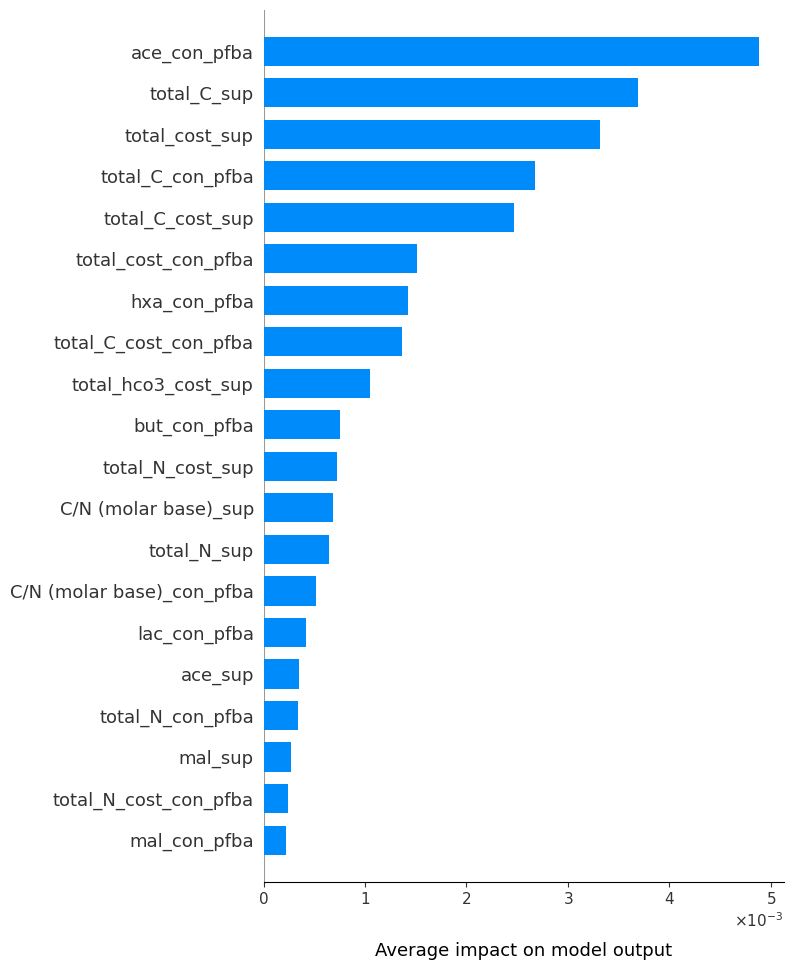

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


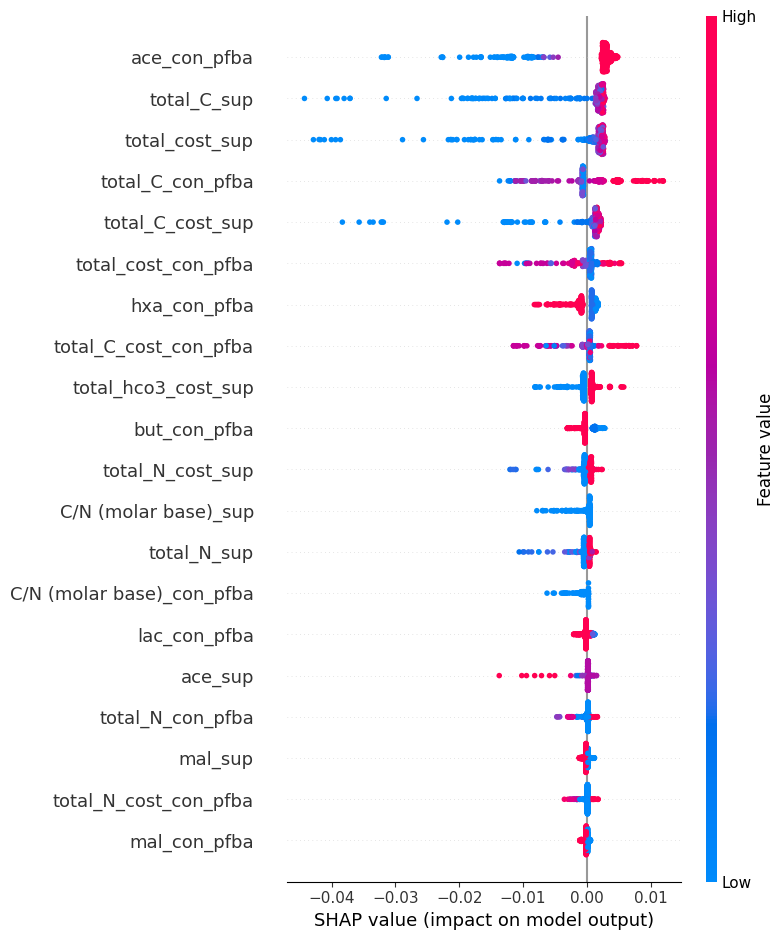


=== Best CatBoost predicted solution ===
    Unnamed: 0 Experiment Biomass (mg dw/L) PHB (mg/L)  % PHB PHV (mg/L)  \
172        172         21              1417     238.44  16.83      10.65   

    % PHV 5-ALA (micromol/L) Q10 (mg/g dw) Carotenoids (mg/g dw)  ...  \
172  0.75                NaN           NaN                   NaN  ...   

    total_C_con_pfba_molar PHB_yield_con_pfba total_N_con_pfba  \
172               2.064596           0.500919              0.0   

    total_N_con_pfba_molar C/N (molar base)_con_pfba total_C_cost_con_pfba  \
172                    0.0                       inf                0.0059   

    total_hco3_cost_con_pfba total_N_cost_con_pfba total_cost_con_pfba  \
172                      0.0                   0.0              0.0059   

    PHB_pred_flux  
172      0.398409  

[1 rows x 100 columns]


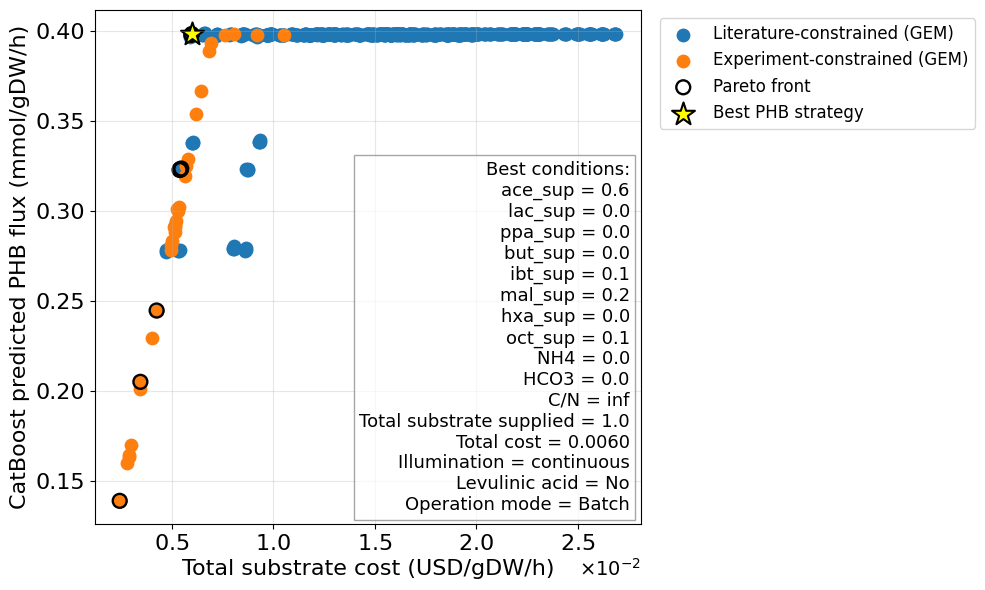


Synthetic ratio sensitivity analysis

Ratio 0:1
Experimental RMSE: 0.0270
Experimental R²:   0.8821

Ratio 1:1
Experimental RMSE: 0.0111
Experimental R²:   0.9800

Ratio 2:1
Experimental RMSE: 0.0077
Experimental R²:   0.9904

Ratio 4:1
Experimental RMSE: 0.0075
Experimental R²:   0.9909

Ratio 8:1
Experimental RMSE: 0.0042
Experimental R²:   0.9972

Ratio 16:1
Experimental RMSE: 0.0037
Experimental R²:   0.9977

Ratio sensitivity summary
   ratio  n_syn  exp_rmse    exp_r2
0      0      0  0.026983  0.882121
1      1     24  0.011110  0.980017
2      2     48  0.007711  0.990374
3      4     96  0.007509  0.990871
4      8    192  0.004168  0.997188
5     16    384  0.003739  0.997737


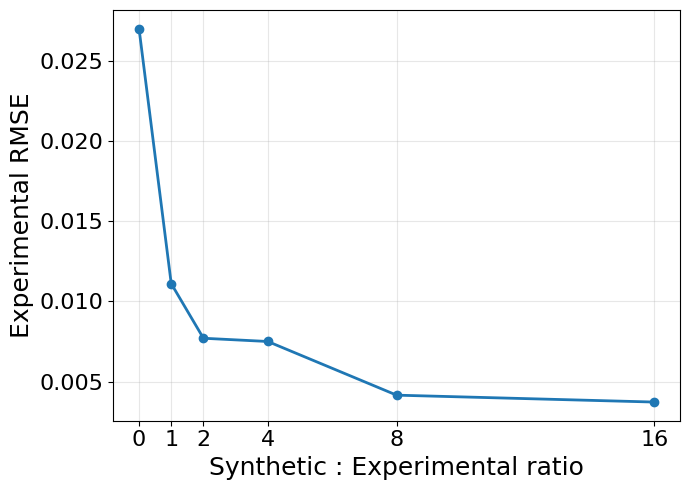

PHB_SYN_UB_VALUE:1000

=== Detected substrate columns ===
['ace_sup', 'ace_con', 'ace_con_pfba', 'lac_sup', 'lac_con', 'lac_con_pfba', 'ppa_sup', 'ppa_con', 'ppa_con_pfba', 'but_sup', 'but_con', 'but_con_pfba', 'ibt_sup', 'ibt_con', 'ibt_con_pfba', 'mal_sup', 'mal_con', 'mal_con_pfba', 'hxa_sup', 'hxa_con', 'hxa_con_pfba', 'oct_sup', 'oct_con', 'oct_con_pfba']

=== Final feature columns ===
['ace_sup', 'ace_con_pfba', 'lac_sup', 'lac_con_pfba', 'ppa_sup', 'ppa_con_pfba', 'but_sup', 'but_con_pfba', 'ibt_sup', 'ibt_con_pfba', 'mal_sup', 'mal_con_pfba', 'hxa_sup', 'hxa_con_pfba', 'oct_sup', 'oct_con_pfba', 'C/N (molar base)_sup', 'total_C_sup', 'total_N_sup', 'total_C_cost_sup', 'total_cost_sup', 'total_N_cost_sup', 'total_hco3_cost_sup', 'C/N (molar base)_con_pfba', 'total_C_con_pfba', 'total_N_con_pfba', 'total_C_cost_con_pfba', 'total_cost_con_pfba', 'total_N_cost_con_pfba', 'total_hco3_cost_con_pfba']

=== Using combined PHB flux target ===

=== Categorical features used ===
['Type of

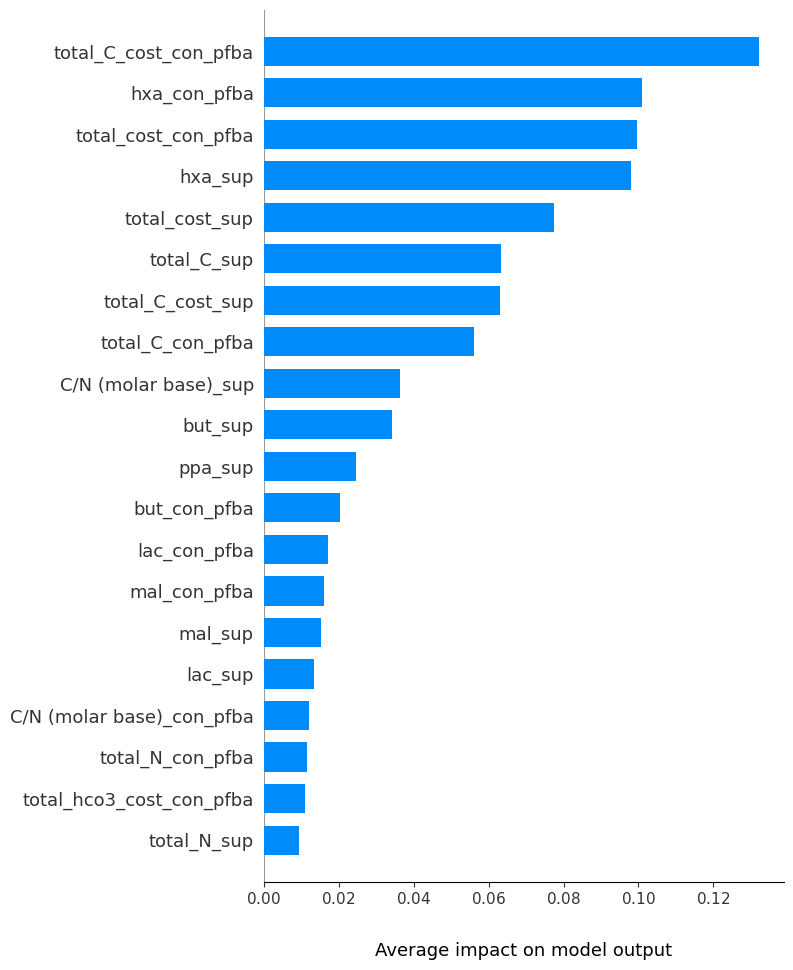

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


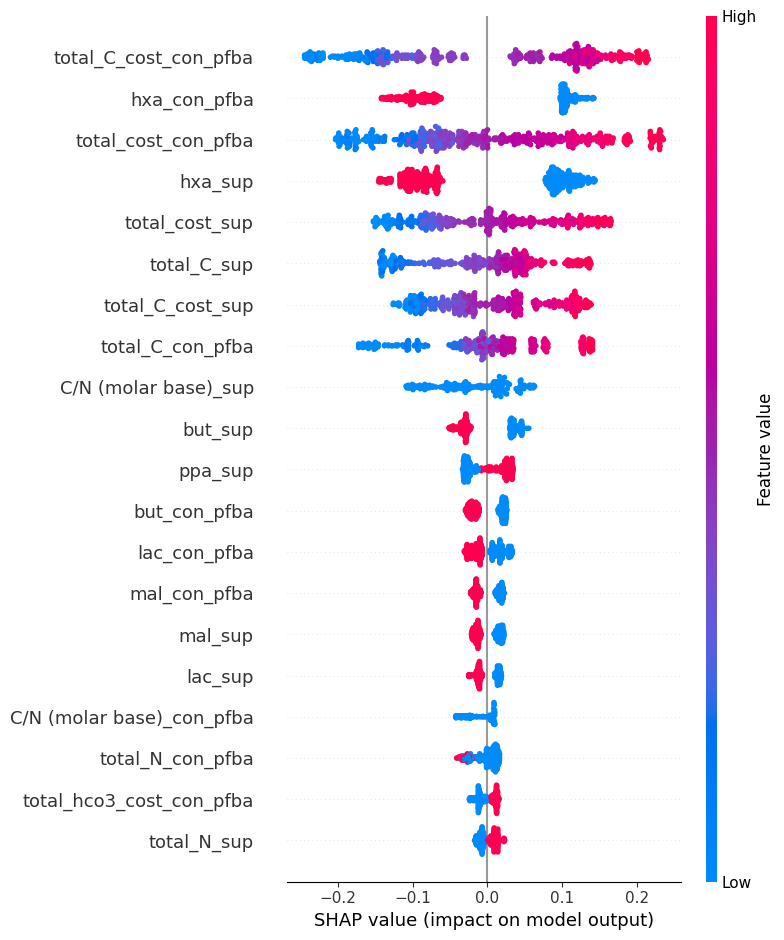


=== Best CatBoost predicted solution ===
    Unnamed: 0 Experiment Biomass (mg dw/L) PHB (mg/L)  % PHB PHV (mg/L)  \
245        245         21              1417     238.44  16.83      10.65   

    % PHV 5-ALA (micromol/L) Q10 (mg/g dw) Carotenoids (mg/g dw)  ...  \
245  0.75                NaN           NaN                   NaN  ...   

    total_C_con_pfba_molar PHB_yield_con_pfba total_N_con_pfba  \
245              12.029508           0.989482              0.0   

    total_N_con_pfba_molar C/N (molar base)_con_pfba total_C_cost_con_pfba  \
245                    0.0                       inf              0.022233   

    total_hco3_cost_con_pfba total_N_cost_con_pfba total_cost_con_pfba  \
245                 0.000674                   0.0            0.022907   

    PHB_pred_flux  
245       3.00896  

[1 rows x 100 columns]


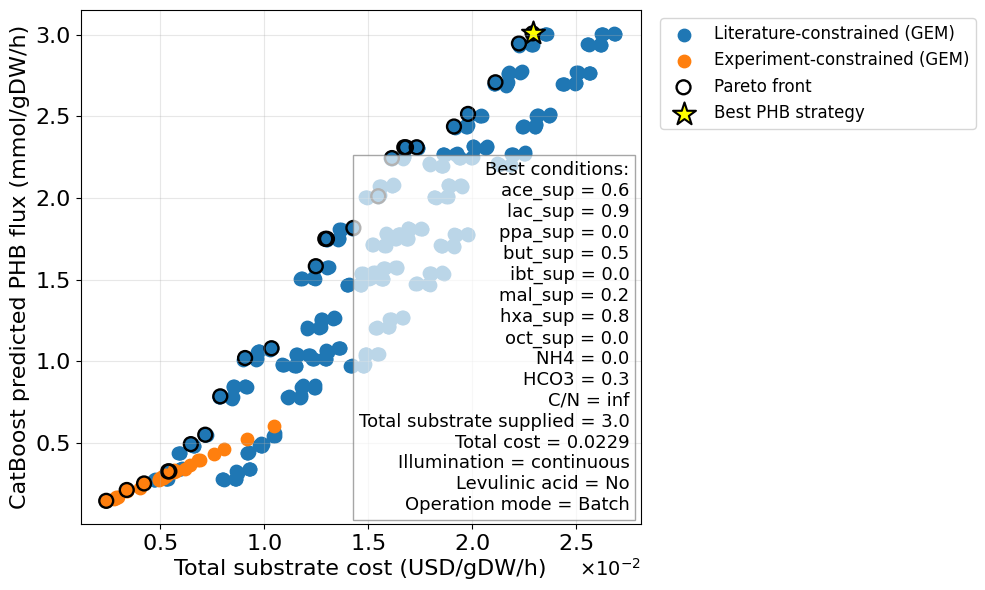


Synthetic ratio sensitivity analysis

Ratio 0:1
Experimental RMSE: 0.0512
Experimental R²:   0.8498

Ratio 1:1
Experimental RMSE: 0.0247
Experimental R²:   0.9649

Ratio 2:1
Experimental RMSE: 0.0343
Experimental R²:   0.9325

Ratio 4:1
Experimental RMSE: 0.0607
Experimental R²:   0.7886

Ratio 8:1
Experimental RMSE: 0.0983
Experimental R²:   0.4460

Ratio 16:1
Experimental RMSE: 0.0741
Experimental R²:   0.6851

Ratio sensitivity summary
   ratio  n_syn  exp_rmse    exp_r2
0      0      0  0.051181  0.849801
1      1     24  0.024726  0.964945
2      2     48  0.034306  0.932518
3      4     96  0.060726  0.788556
4      8    192  0.098295  0.445996
5     16    384  0.074111  0.685067


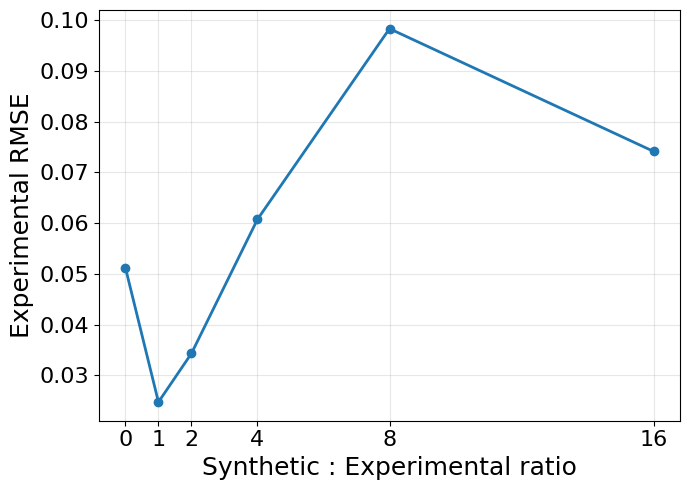

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from catboost import CatBoostRegressor, Pool, cv
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import shap
import joblib  # for saving/loading models


PHB_SYN_UB_VALUES = [0.3978, 1000] # 0.0167, 1.0,

results_summary = []

for PHB_SYN_UB in PHB_SYN_UB_VALUES:

    print(f"PHB_SYN_UB_VALUE:{PHB_SYN_UB}")

    PHB_SYN_TAG = f"{PHB_SYN_UB:g}"

    df = pd.read_csv(
        PHB_GEM_AUGMENTATION_DIR / f"03_Buitron2025_dataset_augmented_VFAs_phb_with_cost_n2_{PHB_SYN_TAG}.csv"
    )

    df = df.copy()

    # 2. Detect substrate columns
    possible_substrates = ["ace", "lac", "ppa", "but", "ibt", "mal", "hxa", "oct"]
    substrates = []
    for sub in possible_substrates:
        matches = [c for c in df.columns if sub.lower() in c.lower()]
        substrates.extend(matches)

    print("\n=== Detected substrate columns ===")
    print(substrates)

    # 3. Feature columns

    substrates = [
        c for c in df.columns
        if any(sub in c.lower() for sub in possible_substrates)
        and not c.endswith("_con")
    ]

    extra_features = [
        "C/N (molar base)_sup",
        "total_C_sup",
        "total_N_sup",
        "total_C_cost_sup",
        "total_cost_sup",
        "total_N_cost_sup",
        "total_hco3_cost_sup",
        "C/N (molar base)_con_pfba",
        "total_C_con_pfba",
        "total_N_con_pfba",
        "total_C_cost_con_pfba",
        "total_cost_con_pfba",
        "total_N_cost_con_pfba",
        "total_hco3_cost_con_pfba"
    ]

    extra_features = [c for c in extra_features if c in df.columns]
    feature_cols = substrates + extra_features

    print("\n=== Final feature columns ===")
    print(feature_cols)

    target = "PHB_model_flux"
    y = df[target]

    print("\n=== Using combined PHB flux target ===")

    # 4. Categorical features
    cat_features = [
        "Type of substrate",
        "Illumination",
        "Levulinic acid",
        "Operation mode",
    ]

    existing_cat_features = [c for c in cat_features if c in df.columns]

    print("\n=== Categorical features used ===")
    print(existing_cat_features)

    X = df[feature_cols + existing_cat_features]

    # 5. Train / Test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=0
    )

    train_pool = Pool(X_train, y_train, cat_features=existing_cat_features)
    test_pool = Pool(X_test, y_test, cat_features=existing_cat_features)


    # 6a. 5-fold Cross-Validation (dataset-level performance)

    cv_params = {
        "iterations": 600,
        "learning_rate": 0.03,
        "depth": 8,
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "random_seed": 0,
        "verbose": False
    }

    full_pool = Pool(
        X,
        y,
        cat_features=existing_cat_features
    )

    cv_results = cv(
        pool=full_pool,
        params=cv_params,
        fold_count=5,
        shuffle=True,
        partition_random_seed=0
    )

    cv_rmse_mean = cv_results["test-RMSE-mean"].iloc[-1]
    cv_rmse_std  = cv_results["test-RMSE-std"].iloc[-1]

    print("\n=== 5-fold Cross-Validation (CatBoost) ===")
    print(f"CV RMSE: {cv_rmse_mean:.4f} \u00b1 {cv_rmse_std:.4f}")

    with open(PHB_CATBOOST_DIR / f"04_cv_metrics_SUP_CON_PFBA_{PHB_SYN_TAG}.txt", "w") as f:
        f.write(f"CV RMSE: {cv_rmse_mean:.4f} \u00b1 {cv_rmse_std:.4f}\n")

    # 6. Train CatBoost model
    model = CatBoostRegressor(
        iterations=600,
        learning_rate=0.03,
        depth=8,
        loss_function="RMSE",
        verbose=100,
        random_seed=0
    )

    model.fit(train_pool, eval_set=test_pool)

    pred_test = model.predict(test_pool)
    rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    r2 = r2_score(y_test, pred_test)

    print("\n=== CHECKPOINT 1: CatBoost Performance ===")
    print(f"RMSE: {rmse:.4f}")
    print(f"R\u00b2:   {r2:.4f}")


    # 7. Save model
    model_save_path = PHB_CATBOOST_DIR / f"04_catboost_model_SUP_CON_PFBA_{PHB_SYN_TAG}.cbm"
    model.save_model(model_save_path)

    print(f"\nCatBoost model saved to: {model_save_path}")

    # 8. Retrain on ALL data
    model.fit(Pool(X, y, cat_features=existing_cat_features))
    df["PHB_pred_flux"] = model.predict(Pool(X, cat_features=existing_cat_features))

    # Experimental-domain fit (in-sample)
    exp_mask = df["is_experimental"] == 1

    X_exp = df.loc[
        exp_mask,
        feature_cols + existing_cat_features
    ]

    y_exp = df.loc[exp_mask, target]

    exp_pool = Pool(
        X_exp,
        y_exp,
        cat_features=existing_cat_features
    )

    exp_pred = model.predict(exp_pool)

    exp_rmse = np.sqrt(
        mean_squared_error(y_exp, exp_pred)
    )

    exp_r2 = r2_score(y_exp, exp_pred)

    print("\nExperimental subset performance (in-sample)")
    print(f"RMSE: {exp_rmse:.4f}")
    print(f"R\u00b2:   {exp_r2:.4f}")

    # Synthetic-domain fit
    syn_mask = df["is_experimental"] == 0

    X_syn = df.loc[
        syn_mask,
        feature_cols + existing_cat_features
    ]

    y_syn = df.loc[
        syn_mask,
        target
    ]

    syn_pool = Pool(
        X_syn,
        y_syn,
        cat_features=existing_cat_features
    )

    syn_pred = model.predict(syn_pool)

    syn_rmse = np.sqrt(
        mean_squared_error(y_syn, syn_pred)
    )

    syn_r2 = r2_score(
        y_syn,
        syn_pred
    )

    print("\nDomain shift check")
    print(f"Experimental RMSE: {exp_rmse:.4f}")
    print(f"Synthetic RMSE:    {syn_rmse:.4f}")
    print(f"Experimental R\u00b2:   {exp_r2:.4f}")
    print(f"Synthetic R\u00b2:      {syn_r2:.4f}")

    # 10. SHAP Feature Importance (bar)
    import matplotlib.ticker as mticker

    explainer = shap.TreeExplainer(
        model,
        feature_perturbation="tree_path_dependent",
    )

    shap_values = explainer.shap_values(X)

    plt.figure(figsize=(18, 8))

    shap.summary_plot(
        shap_values,
        X,
        plot_type="bar",
        show=False,
    )

    ax = plt.gca()
    ax.ticklabel_format(style='scientific', axis='x', scilimits=(0, 0))
    ax.xaxis.get_major_formatter().set_useMathText(True)

    plt.gcf().subplots_adjust(left=0.45,right=1.1)

    #  FORCE scientific notation properly
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='x', scilimits=(-2, 2))

    #  Reposition exponent text
    offset = ax.xaxis.get_offset_text()
    offset.set_size(11)
    offset.set_x(1.0)
    offset.set_y(-0.10)

    plt.xlabel(
        "Average impact on model output",
        fontsize=13,
        labelpad=25
    )


    for ext in ["pdf", "png", "tiff"]:
        plt.savefig(
            PHB_FIGURES_DIR / f"04_catboost_shap_summary_SUP_CON_PFBA_{PHB_SYN_TAG}.{ext}",
            dpi=300,
            bbox_inches="tight",
    )

    plt.show()

    # 10b. SHAP Beeswarm
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_values,
        X,
        show=False,
    )

    plt.tight_layout()

    for ext in ["pdf", "svg", "tiff"]:
        plt.savefig(
            PHB_FIGURES_DIR / f"04_catboost_shap_swarm_SUP_CON_PFBA_{PHB_SYN_TAG}.{ext}",
            dpi=300,
            bbox_inches="tight",
    )
    plt.show()

    # 11. Best predicted solution
    best_idx = df["PHB_pred_flux"].idxmax()
    best_solution = df.loc[best_idx].to_frame().T

    best_solution.to_csv(
        PHB_CATBOOST_DIR / f"04_catboost_optimal_conditions_SUP_CON_PFBA_{PHB_SYN_TAG}.csv",
        index=False,
    )

    print("\n=== Best CatBoost predicted solution ===")
    print(best_solution)

    # 12. Pareto front analysis

    def is_pareto_efficient(costs, maximize_cols=None):
      costs = np.asarray(costs, dtype=float)

      # convert maximization to minimization
      if maximize_cols is not None:
          costs[:, np.atleast_1d(maximize_cols)] *= -1

      n = costs.shape[0]
      is_eff = np.ones(n, dtype=bool)

      for i in range(n):
          if not is_eff[i]:
              continue

          others = np.arange(n) != i
          no_worse = np.all(costs[others] <= costs[i], axis=1)
          strictly_better = np.any(costs[others] < costs[i], axis=1)

          if np.any(no_worse & strictly_better):
              is_eff[i] = False

      return is_eff


    objectives = df[["PHB_pred_flux", "total_cost_sup"]].to_numpy()

    # Round to 3 decimal places
    objectives = np.round(objectives, 3)

    pareto_mask = is_pareto_efficient(objectives, maximize_cols=[0])
    pareto_solutions = df[pareto_mask]

    best_pareto_idx = pareto_solutions["PHB_pred_flux"].idxmax()
    best_pareto = pareto_solutions.loc[[best_pareto_idx]]

    pareto_solutions.to_csv(
        PHB_PARETO_DIR / f"04_pareto_optimal_conditions_SUP_CON_PFBA_{PHB_SYN_TAG}.csv",
        index=False,
    )
    best_pareto.to_csv(
        PHB_PARETO_DIR / f"04_best_pareto_conditions_SUP_CON_PFBA_{PHB_SYN_TAG}.csv",
        index=False,
    )

    # 13. PHB flux vs cost plot
    COLOR_GEM = "#1f77b4"
    COLOR_EXP = "#ff7f0e"
    COLOR_BEST = "yellow"

    plt.figure(figsize=(10, 6))

    if "is_experimental" in df.columns:
        gem_points = df[df["is_experimental"] == 0]
        plt.scatter(
            gem_points["total_cost_sup"],
            gem_points["PHB_pred_flux"],
            color=COLOR_GEM,
            s=80,
            label="Literature-constrained (GEM)"
        )

        exp_points = df[df["is_experimental"] == 1]
        plt.scatter(
            exp_points["total_cost_sup"],
            exp_points["PHB_pred_flux"],
            color=COLOR_EXP,
            s=80,
            label="Experiment-constrained (GEM)"
        )

    plt.scatter(
        pareto_solutions["total_cost_sup"],
        pareto_solutions["PHB_pred_flux"],
        facecolors="none",
        edgecolors="black",
        s=100,
        linewidths=1.7,
        label="Pareto front"
    )

    plt.scatter(
        best_pareto["total_cost_sup"],
        best_pareto["PHB_pred_flux"],
        color=COLOR_BEST,
        s=300,
        marker="*",
        edgecolors="black",
        linewidths=1.5,
        label="Best PHB strategy"
    )


    # Annotation
    best_solution = df.loc[best_idx]   # Series

    #substrates = ["ace", "lac", "ppa", "but", "ibt", "mal", "hxa", "oct"]
    #print("Unique substrates:", substrates)

    # FIXED ANNOTATION BLOCK (NO STRING NEGATION)

    best_pareto_row = best_pareto.iloc[0]

    substrates = ["ace_sup", "lac_sup", "ppa_sup", "but_sup",
                  "ibt_sup", "mal_sup", "hxa_sup", "oct_sup"]

    existing_cat_features = [c for c in cat_features if c in df.columns]

    annotation_lines = []

    # --- numeric substrate uptakes ---
    for col in substrates:
        if col in best_pareto_row:
            val = best_pareto_row[col]
            if pd.notna(val):
                annotation_lines.append(f"{col} = {abs(float(val)):.1f}")

    # --- nitrogen & bicarbonate ---
    if "nh4_sup" in best_pareto_row:
        val = best_pareto_row["nh4_sup"]
        if pd.notna(val):
            annotation_lines.append(f"NH4 = {abs(float(val)):.1f}")

    if "hco3_sup" in best_pareto_row:
        val = best_pareto_row["hco3_sup"]
        if pd.notna(val):
            annotation_lines.append(f"HCO3 = {abs(float(val)):.1f}")

    # --- C/N ratio ---
    if "C/N (molar base)_sup" in best_pareto_row:
        val = best_pareto_row["C/N (molar base)_sup"]
        if pd.notna(val):
            val = abs(float(val))
            display_val = "inf" if val > 1e6 else f"{val:.1f}"
            annotation_lines.append(f"C/N = {display_val}")

    # --- totals ---
    if "total_C_sup" in best_pareto_row:
        val = best_pareto_row["total_C_sup"]
        if pd.notna(val):
            annotation_lines.append(f"Total substrate supplied = {abs(float(val)):.1f}")

    if "total_cost_sup" in best_pareto_row:
        val = best_pareto_row["total_cost_sup"]
        if pd.notna(val):
            annotation_lines.append(f"Total cost = {abs(float(val)):.4f}")

    # --- categorical variables ---
    for col in existing_cat_features:
        if col == "Type of substrate":
            continue
        if col in best_pareto_row:
            val = best_pareto_row[col]
            if pd.notna(val):
                annotation_lines.append(f"{col} = {val}")

    # --- assemble text ---
    feature_text = "Best conditions:\n" + "\n".join(annotation_lines)

    # --- plot annotation ---
    plt.annotate(
        feature_text,
        xy=(0.98, 0.02),
        xycoords='axes fraction',
        fontsize=13,
        ha='right',
        va='bottom',
        bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7)
    )

    plt.xlabel("Total substrate cost (USD/gDW/h)", fontsize=16)
    plt.ylabel("CatBoost predicted PHB flux (mmol/gDW/h)", fontsize=16)
    #plt.title(f"(B) Optimizing substrate consumed in pFBA (n={len(df)})", fontsize=16)

    ax = plt.gca()

    ax.ticklabel_format(style='scientific', axis='x', scilimits=(0, 0))
    ax.xaxis.get_major_formatter().set_useMathText(True)

    # Tick labels size
    ax.tick_params(axis='x', labelsize=14)

    # Scientific notation (×10^n) size
    offset = ax.xaxis.get_offset_text()
    offset.set_fontsize(14)

    # Optional: reposition it (you already do this)
    offset.set_x(1.0)
    offset.set_y(-0.10)

    plt.grid(True, alpha=0.3)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=12)

    plt.tight_layout()

    for ext in ["pdf", "svg", "tiff"]:
        plt.savefig(
            PHB_FIGURES_DIR / f"04_PHB_catboost_pareto_plot_SUP_CON_PFBA_{PHB_SYN_TAG}.{ext}",
            dpi=300,
            bbox_inches="tight"
    )
    plt.show()

    # Save summary metrics
    results_summary.append({
        "PHB_SYN_UB": PHB_SYN_UB,
        "n_exp": (df["is_experimental"] == 1).sum(),
        "n_syn": (df["is_experimental"] == 0).sum(),
        "rmse": rmse,
        "r2": r2,
        "cv_rmse_mean": cv_rmse_mean,
        "cv_rmse_std": cv_rmse_std,
        "exp_rmse": exp_rmse,
        "exp_r2": exp_r2,
        "syn_rmse": syn_rmse,
        "syn_r2": syn_r2
    })

    # Synthetic ratio sensitivity analysis
    print("\nSynthetic ratio sensitivity analysis")

    exp_df = df[
        df["is_experimental"] == 1
    ].copy()

    syn_df = df[
        df["is_experimental"] == 0
    ].copy()

    exp_train_df, exp_test_df = train_test_split(
        exp_df,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )

    ratios = [0, 1, 2, 4, 8, 16]

    ratio_results = []

    for ratio in ratios:

        print(f"\nRatio {ratio}:1")

        n_exp_train = len(exp_train_df)

        n_syn = min(
            len(syn_df),
            ratio * n_exp_train
        )

        syn_subset = syn_df.sample(
            n=n_syn,
            random_state=42
        )

        train_df_ratio = pd.concat(
            [exp_train_df, syn_subset],
            ignore_index=True
        )

        X_train_ratio = train_df_ratio[
            feature_cols + existing_cat_features
        ]

        y_train_ratio = train_df_ratio[target]

        X_test_exp = exp_test_df[
            feature_cols + existing_cat_features
        ]

        y_test_exp = exp_test_df[target]

        train_pool_ratio = Pool(
            X_train_ratio,
            y_train_ratio,
            cat_features=existing_cat_features
        )

        test_pool_exp = Pool(
            X_test_exp,
            y_test_exp,
            cat_features=existing_cat_features
        )

        model_ratio = CatBoostRegressor(
            iterations=600,
            learning_rate=0.03,
            depth=8,
            loss_function="RMSE",
            verbose=False,
            random_seed=42
        )

        model_ratio.fit(train_pool_ratio)

        pred_exp = model_ratio.predict(
            test_pool_exp
        )

        exp_rmse_ratio = np.sqrt(
            mean_squared_error(
                y_test_exp,
                pred_exp
            )
        )

        exp_r2_ratio = r2_score(
            y_test_exp,
            pred_exp
        )

        print(f"Experimental RMSE: {exp_rmse_ratio:.4f}")
        print(f"Experimental R\u00b2:   {exp_r2_ratio:.4f}")

        ratio_results.append({
            "ratio": ratio,
            "n_syn": n_syn,
            "exp_rmse": exp_rmse_ratio,
            "exp_r2": exp_r2_ratio
        })

    ratio_results_df = pd.DataFrame(
        ratio_results
    )

    print("\nRatio sensitivity summary")
    print(ratio_results_df)

    ratio_results_df.to_csv(
        PHB_CATBOOST_DIR /
        f"synthetic_ratio_sensitivity_SUP_CON_PFBA_{PHB_SYN_TAG}.csv",
        index=False
    )

    # Sensitivity plot
    plt.figure(figsize=(7, 5))

    plt.plot(
        ratio_results_df["ratio"],
        ratio_results_df["exp_rmse"],
        marker="o",
        linewidth=2
    )

    plt.xlabel(
        "Synthetic : Experimental ratio",
        fontsize=18
    )

    plt.ylabel(
        "Experimental RMSE",
        fontsize=18
    )

    plt.xticks(
        ratio_results_df["ratio"],
        fontsize=16
    )

    plt.yticks(fontsize=16)

    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    for ext in ["pdf", "svg", "tiff"]:

        plt.savefig(
            PHB_FIGURES_DIR /
            f"synthetic_ratio_sensitivity_rmse_SUP_CON_PFBA_{PHB_SYN_TAG}.{ext}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

pd.DataFrame(results_summary).to_csv(
    PHB_CATBOOST_DIR /
    "synthetic_ratio_sensitivity_SUP_CON_PFBA_all_PHB_SYN_UB.csv",
    index=False
)

# Versions without SHAP plot (depricated)

## A.Substrate only supplied


=== Columns in dataset ===
['Unnamed: 0', 'Experiment', 'Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)', '% PHV', '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)', 'Experiment.1', 'Time (d)', 'g substrate COD/L', 'Type of substrate', 'mg N/L', 'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium', 'g NaHCO3/L', 'Illumination', 'Levulinic acid', 'Fe (mg Ferric citrate/L)', 'Operation mode', '% Volume exchange', 'Time_h', 'Biomass_gL', 'PHB_exp_flux', 'PHB_model_flux', 'PHB_model_flux_pFBA', 'PHB_fva_width', 'nh4_sup', 'nh4_con', 'nh4_use_pfba', 'hco3_sup', 'hco3_con', 'hco3_use_pfba', 'ace_sup', 'ace_con', 'ace_use_pfba', 'lac_sup', 'lac_con', 'lac_use_pfba', 'ppa_sup', 'ppa_con', 'ppa_use_pfba', 'but_sup', 'but_con', 'but_use_pfba', 'ibt_sup', 'ibt_con', 'ibt_use_pfba', 'mal_sup', 'mal_con', 'mal_use_pfba', 'hxa_sup', 'hxa_con', 'hxa_use_pfba', 'oct_sup', 'oct_con', 'oct_use_pfba', 'is_experimental', 'total_C_sup', 'total_C_in_molar', 'total_C_con', 'tot

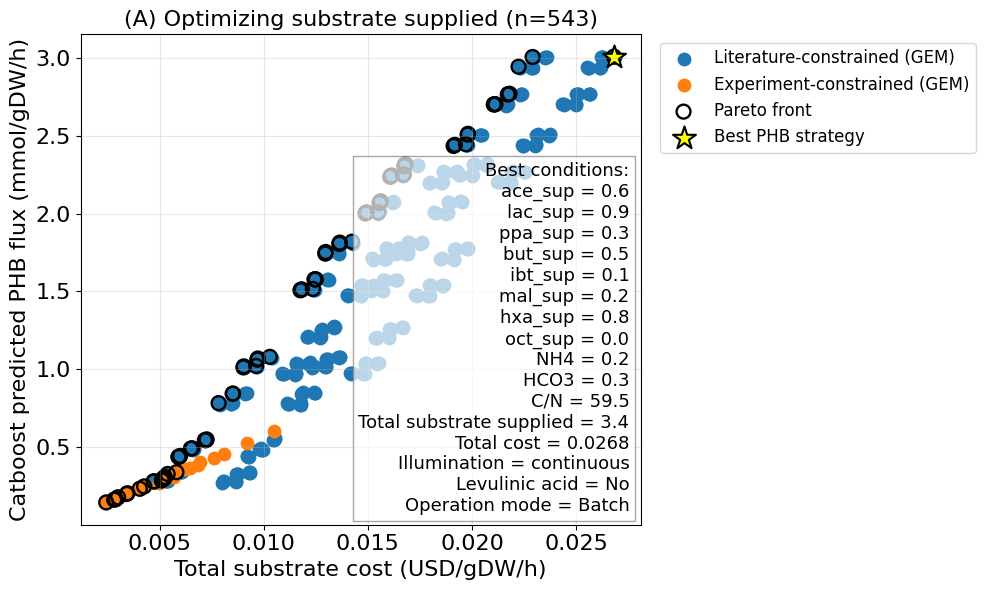

In [ ]:
# This version is convert predicted flux → PHB g/L and %PHB

from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


# =========================================================
# 1. Load data
# =========================================================
#df = pd.read_csv(results_path/ "Buitron2025_dataset_augmented_VFAs_phb_with_cost_n2.csv")

#df = df.rename(
#    columns=lambda c: c.replace("_in", "_sup") if c.endswith("_in") else c
#)
print("\n=== Columns in dataset ===")
print(df.columns.tolist())

# =========================================================
# 2. Detect substrate columns (robust search)
# =========================================================
possible_substrates = [
    "ace","lac","ppa","but",
    "ibt","mal","hxa","oct"
]

substrates = []
for sub in possible_substrates:
    matches = [c for c in df.columns if sub.lower() in c.lower()]
    substrates.extend(matches)

print("\n=== Detected substrate columns ===")
print(substrates)

# =========================================================
# 3. Feature columns
# =========================================================
extra_features = ["C/N (molar base)_sup",
                  "total_C_sup",
                  "total_N_sup",
                  "total_C_cost_sup", "total_cost_sup", "total_N_cost_sup", "total_hco3_cost_sup"]

extra_features = [c for c in extra_features if c in df.columns]

feature_cols = substrates + extra_features
print("\n=== Final feature columns ===")
print(feature_cols)

target = "PHB_model_flux"
y = df[target]

print("\n=== Using combined PHB flux target ===")

# =========================================================
# 5. Features with categorical variables
# =========================================================
cat_features = [
    'Type of substrate',
    'Illumination',
    'Levulinic acid',
    'Operation mode'#,
    #'Substrate_type',
    #'sub_rxn_id'
]

existing_cat_features = [c for c in cat_features if c in df.columns]
print("\n=== Categorical features used ===")
print(existing_cat_features)

X = df[feature_cols + existing_cat_features]

# =========================================================
# 6. Train / Test split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_pool = Pool(X_train, y_train, cat_features=existing_cat_features)
test_pool  = Pool(X_test,  y_test,  cat_features=existing_cat_features)

# =========================================================
# 7. Train CatBoost surrogate
# =========================================================
model = CatBoostRegressor(
    iterations=600,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    verbose=100
)

model.fit(train_pool, eval_set=test_pool)

pred_test = model.predict(test_pool)
rmse = np.sqrt(mean_squared_error(y_test, pred_test))
r2   = r2_score(y_test, pred_test)

print("\n=== CHECKPOINT 1: CatBoost Performance ===")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# =========================================================
# 8. Retrain on ALL data
# =========================================================
model.fit(Pool(X, y, cat_features=existing_cat_features))

df["PHB_pred_flux"] = model.predict(Pool(X, cat_features=existing_cat_features))

# =========================================================
# 9. Convert predicted flux → PHB g/L and %PHB
# =========================================================
# Define constants (adjust to your experimental assumptions)
#MW_PHB = 86        # g/mol (3HB monomer)
#X_gDW_L = 1.0      # biomass concentration (gDW/L)
#t = 1.0            # hours (if flux is mmol/gDW/h)

# Convert from mmol/gDW/h → g/L
#df["PHB_pred_gL"] = df["PHB_pred_flux"] * X_gDW_L * (MW_PHB / 1000) * t

# Convert to %PHB (g PHB / gDW)
#df["PHB_pred_percent"] = (df["PHB_pred_flux"] * MW_PHB * t) * 100 / (1000 * 1)

# Export best solution
best_idx = df["PHB_pred_flux"].idxmax()
best_solution = df.loc[best_idx].to_frame().T
best_solution.to_csv(results_path  / f"catboost_optimal_conditions_SUP_{PHB_SYN_TAG}.csv", index=False)


print("\n=== Best CatBoost predicted solution ===")
print(best_solution)

# =========================================================
# 10. Pareto Optimality
# =========================================================
def is_pareto_efficient(costs, maximize_cols=None):
    costs_adj = costs.copy()
    if maximize_cols:
        for col in maximize_cols:
            costs_adj[:, col] *= -1

    n = costs_adj.shape[0]
    is_efficient = np.ones(n, dtype=bool)

    for i in range(n):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(
                costs_adj[is_efficient] < costs_adj[i], axis=1
            )
            is_efficient[i] = True
    return is_efficient

objectives = df[["PHB_pred_flux", "total_cost_sup"]].to_numpy() #total_C_in

pareto_mask = is_pareto_efficient(objectives, maximize_cols=[0])
pareto_solutions = df[pareto_mask]

print("\n=== CHECKPOINT 2: Pareto Solutions ===")
print(f"Number of Pareto-optimal strategies: {pareto_solutions.shape[0]}")

best_pareto_idx = pareto_solutions["PHB_pred_flux"].idxmax()
best_pareto = pareto_solutions.loc[[best_pareto_idx]]

print("\nBest Pareto solution:")
print(best_pareto)

pareto_solutions.to_csv(results_path / f"pareto_optimal_conditions_SUP_{PHB_SYN_TAG}.csv", index=False)
best_pareto.to_csv(results_path / f"best_pareto_conditions_SUP_{PHB_SYN_TAG}.csv", index=False)

# =========================================================
# 11. PLOT — PHB flux vs cost
# =========================================================
COLOR_GEM  = "#1f77b4"
COLOR_EXP  = "#ff7f0e"
COLOR_BEST = "yellow"

plt.figure(figsize=(10,6))

if "is_experimental" in df.columns:
    gem_points = df[df["is_experimental"] == 0]
    plt.scatter(gem_points["total_cost_sup"], gem_points["PHB_pred_flux"],
                color=COLOR_GEM, s=80, label="Literature-constrained (GEM)")

    exp_points = df[df["is_experimental"] == 1]
    plt.scatter(exp_points["total_cost_sup"], exp_points["PHB_pred_flux"],
                color=COLOR_EXP, s=80,label="Experiment-constrained (GEM)")

plt.scatter(
    pareto_solutions["total_cost_sup"],
    pareto_solutions["PHB_pred_flux"],
    facecolors='none', edgecolors="black", s=100, linewidths=1.7,
    label="Pareto front"
)

plt.scatter(
    best_pareto["total_cost_sup"],
    best_pareto["PHB_pred_flux"],
    color=COLOR_BEST, s=300, marker="*",
    edgecolors="black", linewidths=1.5, label="Best PHB strategy"
)


# Annotation
best_solution = df.loc[best_idx]   # Series

#substrates = ["ace", "lac", "ppa", "but", "ibt", "mal", "hxa", "oct"]
#print("Unique substrates:", substrates)

# =========================================================
# FIXED ANNOTATION BLOCK (NO STRING NEGATION)
# =========================================================

substrates = ["ace_sup", "lac_sup", "ppa_sup", "but_sup", "ibt_sup", "mal_sup", "hxa_sup", "oct_sup"]
existing_cat_features = [c for c in cat_features if c in df.columns]

annotation_lines = []

# --- numeric substrate uptakes (negate for GEM convention) ---
for col in substrates:
    if col in best_solution.index:
        annotation_lines.append(
            f"{col} = {abs(float(best_solution[col])):.1f}"
        )

if "nh4_sup" in best_solution:
    annotation_lines.append(
        f"NH4 = {abs(float(best_solution['nh4_sup'])):.1f}"
    )

if "hco3_sup" in best_solution:
    annotation_lines.append(
        f"HCO3 = {abs(float(best_solution['hco3_sup'])):.1f}"
    )

if "C/N (molar base)_sup" in best_solution:
    annotation_lines.append(
        f"C/N = {abs(float(best_solution['C/N (molar base)_sup'])):.1f}"
    )

if "total_C_sup" in best_solution:
    annotation_lines.append(
        f"Total substrate supplied = {abs(float(best_solution['total_C_sup'])):.1f}"
    )

if "total_cost_sup" in best_solution:
    annotation_lines.append(
        f"Total cost = {abs(float(best_solution['total_cost_sup'])):.4f}"
    )


# --- categorical variables
for col in existing_cat_features:
    if col == "Type of substrate":
        continue
    if col not in substrates:
        annotation_lines.append(f"{col} = {best_solution[col]}")

# assemble text
feature_text = "Best conditions:\n" + "\n".join(annotation_lines)


plt.annotate(
    feature_text,
    xy=(0.98, 0.02),
    xycoords='axes fraction',
    fontsize=13,
    ha='right',
    va='bottom',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7)
)


plt.xlabel("Total substrate cost (USD/gDW/h)", fontsize=16)
plt.ylabel("Catboost predicted PHB flux (mmol/gDW/h)", fontsize=16)
plt.title(
    f"(A) Optimizing substrate supplied (n={len(df)})",
    fontsize=16
)

plt.grid(True, alpha=0.3)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(loc="upper left", bbox_to_anchor=(1.02,1), fontsize=12)
plt.tight_layout()
plt.savefig(results_path  / f"PHB_catboost_pareto_plot_SUP_{PHB_SYN_TAG}.png", dpi=300, bbox_inches="tight")
plt.show()



## B.Substrate only consumed (used)


=== Columns in dataset ===
['Experiment', 'Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)', '% PHV', '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)', 'Experiment.1', 'Time (d)', 'g substrate COD/L', 'Type of substrate', 'mg N/L', 'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium', 'g NaHCO3/L', 'Illumination', 'Levulinic acid', 'Fe (mg Ferric citrate/L)', 'Operation mode', '% Volume exchange', 'Time_h', 'Biomass_gL', 'PHB_exp_flux', 'PHB_model_flux', 'PHB_model_flux_pFBA', 'PHB_fva_width', 'nh4_sup', 'nh4_con', 'nh4_use_pfba', 'hco3_sup', 'hco3_con', 'hco3_use_pfba', 'ace_sup', 'ace_con', 'ace_use_pfba', 'lac_sup', 'lac_con', 'lac_use_pfba', 'ppa_sup', 'ppa_con', 'ppa_use_pfba', 'but_sup', 'but_con', 'but_use_pfba', 'ibt_sup', 'ibt_con', 'ibt_use_pfba', 'mal_sup', 'mal_con', 'mal_use_pfba', 'hxa_sup', 'hxa_con', 'hxa_use_pfba', 'oct_sup', 'oct_con', 'oct_use_pfba', 'is_experimental', 'total_C_sup', 'total_C_in_molar', 'total_C_con', 'total_C_use_molar

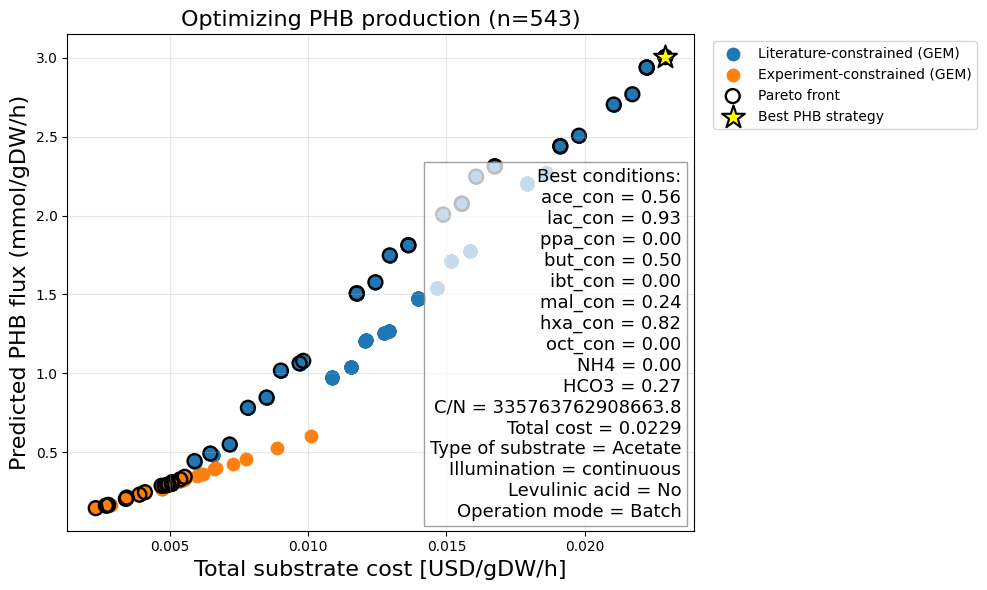

In [ ]:
# =========================================================
# CatBoost surrogate → PHB optimization (USE-based)
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# =========================================================
# 1. Inspect data
# =========================================================

print("\n=== Columns in dataset ===")
print(df.columns.tolist())

# =========================================================
# 2. Detect substrate columns (robust)
# =========================================================
possible_substrates = [
    "ace","lac","ppa","but",
    "ibt","mal","hxa","oct"
]

substrates = []
for sub in possible_substrates:
    matches = [c for c in df.columns if sub.lower() in c.lower()]
    substrates.extend(matches)

print("\n=== Detected substrate columns ===")
print(substrates)

# =========================================================
# 3. Feature columns (USE-based)
# =========================================================
extra_features = [
    "C/N (molar base)_con",
    "total_C_con",
    "total_N_con",
    "total_C_cost_con",
    "total_cost_con",
    "total_N_cost_con",
    "total_hco3_cost_con"
]

extra_features = [c for c in extra_features if c in df.columns]

feature_cols = substrates + extra_features

print("\n=== Final feature columns ===")
print(feature_cols)

# =========================================================
# 4. Target
# =========================================================
target = "PHB_model_flux"
y = df[target]

print("\n=== Using PHB_model_flux as target ===")

# =========================================================
# 5. Categorical features
# =========================================================
cat_features = [
    "Type of substrate",
    "Illumination",
    "Levulinic acid",
    "Operation mode"
]

existing_cat_features = [c for c in cat_features if c in df.columns]

print("\n=== Categorical features used ===")
print(existing_cat_features)

X = df[feature_cols + existing_cat_features]

# =========================================================
# 6. Train / test split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_pool = Pool(X_train, y_train, cat_features=existing_cat_features)
test_pool  = Pool(X_test,  y_test,  cat_features=existing_cat_features)

# =========================================================
# 7. Train CatBoost model
# =========================================================
model = CatBoostRegressor(
    iterations=600,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    verbose=100
)

model.fit(train_pool, eval_set=test_pool)

pred_test = model.predict(test_pool)
rmse = np.sqrt(mean_squared_error(y_test, pred_test))
r2   = r2_score(y_test, pred_test)

print("\n=== CHECKPOINT 1: CatBoost performance ===")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# =========================================================
# 8. Retrain on all data
# =========================================================
model.fit(Pool(X, y, cat_features=existing_cat_features))

df["PHB_pred_flux"] = model.predict(
    Pool(X, cat_features=existing_cat_features)
)

# =========================================================
# 9. Best predicted solution (USE-based)
# =========================================================
best_idx_use = df["PHB_pred_flux"].idxmax()

best_solution_df     = df.loc[[best_idx_use]]   # DataFrame (for CSV)
best_solution_series = df.loc[best_idx_use]     # Series (for annotation)

best_solution_df.to_csv(
    results_path / f"catboost_optimal_conditions_CON_{PHB_SYN_TAG}.csv",
    index=False
)

print("\n=== Best CatBoost predicted solution ===")
print(best_solution_df)

# =========================================================
# 10. Pareto optimality (PHB ↑, cost ↓)
# =========================================================
def is_pareto_efficient(costs, maximize_cols=None):
    costs_adj = costs.copy()
    if maximize_cols:
        for col in maximize_cols:
            costs_adj[:, col] *= -1

    n = costs_adj.shape[0]
    is_efficient = np.ones(n, dtype=bool)

    for i in range(n):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(
                costs_adj[is_efficient] < costs_adj[i], axis=1
            )
            is_efficient[i] = True
    return is_efficient

objectives = df[["PHB_pred_flux", "total_cost_con"]].to_numpy()

pareto_mask_use = is_pareto_efficient(objectives, maximize_cols=[0])
pareto_solutions_use = df[pareto_mask_use]

print("\n=== CHECKPOINT 2: Pareto front ===")
print(f"Number of Pareto-optimal strategies: {pareto_solutions_use.shape[0]}")

best_pareto_idx_use = pareto_solutions_use["PHB_pred_flux"].idxmax()
best_pareto_use = pareto_solutions_use.loc[[best_pareto_idx_use]]

pareto_solutions_use.to_csv(
    results_path / f"pareto_optimal_conditions_CON_{PHB_SYN_TAG}.csv",
    index=False
)

best_pareto_use.to_csv(
    results_path / f"best_pareto_conditions_CON_{PHB_SYN_TAG}.csv",
    index=False
)

# =========================================================
# 11. Plot — PHB vs cost
# =========================================================
plt.figure(figsize=(10,6))

COLOR_GEM  = "#1f77b4"
COLOR_EXP  = "#ff7f0e"
COLOR_BEST = "yellow"

if "is_experimental" in df.columns:
    gem = df[df["is_experimental"] == 0]
    exp = df[df["is_experimental"] == 1]

    plt.scatter(
        gem["total_cost_con"], gem["PHB_pred_flux"],
        color=COLOR_GEM, s=80, label="Literature-constrained (GEM)"
    )

    plt.scatter(
        exp["total_cost_con"], exp["PHB_pred_flux"],
        color=COLOR_EXP, s=80, label="Experiment-constrained (GEM)"
    )

plt.scatter(
    pareto_solutions_use["total_cost_con"],
    pareto_solutions_use["PHB_pred_flux"],
    facecolors="none", edgecolors="black",
    s=100, linewidths=1.7, label="Pareto front"
)

plt.scatter(
    best_pareto_use["total_cost_con"],
    best_pareto_use["PHB_pred_flux"],
    color=COLOR_BEST, s=300, marker="*",
    edgecolors="black", linewidths=1.5,
    label="Best PHB strategy"
)

# =========================================================
# Annotation (Series → scalars)
# =========================================================
annotation_lines = []

substrate_cols = [
    "ace_con","lac_con","ppa_con","but_con",
    "ibt_con","mal_con","hxa_con","oct_con"
]

for col in substrate_cols:
    if col in best_solution_series.index:
        annotation_lines.append(
            f"{col} = {abs(float(best_solution_series[col])):.2f}"
        )

if "nh4_con" in best_solution_series:
    annotation_lines.append(
        f"NH4 = {abs(float(best_solution_series['nh4_con'])):.2f}"
    )

if "hco3_con" in best_solution_series:
    annotation_lines.append(
        f"HCO3 = {abs(float(best_solution_series['hco3_con'])):.2f}"
    )

if "C/N (molar base)_con" in best_solution_series:
    annotation_lines.append(
        f"C/N = {abs(float(best_solution_series['C/N (molar base)_con'])):.1f}"
    )

annotation_lines.append(
    f"Total cost = {abs(float(best_solution_series['total_cost_con'])):.4f}"
)

for col in existing_cat_features:
    if col in best_solution_series.index:
        annotation_lines.append(f"{col} = {best_solution_series[col]}")

plt.annotate(
    "Best conditions:\n" + "\n".join(annotation_lines),
    xy=(0.98, 0.02),
    xycoords="axes fraction",
    ha="right", va="bottom",
    fontsize=13,
    bbox=dict(facecolor="white", edgecolor="gray", alpha=0.75)
)

plt.xlabel("Total substrate cost [USD/gDW/h]", fontsize=16)
plt.ylabel("Predicted PHB flux (mmol/gDW/h)", fontsize=16)
plt.title(f"Optimizing PHB production (n={len(df)})", fontsize=16)

plt.grid(True, alpha=0.3)
plt.legend(loc="upper left", bbox_to_anchor=(1.02,1))
plt.tight_layout()

plt.savefig(
    results_path / f"PHB_catboost_pareto_plot_CON_{PHB_SYN_TAG}.png",
    dpi=300, bbox_inches="tight"
)

plt.show()


## C.Substrate supplied & consumed


=== Columns in dataset ===
['Experiment', 'Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)', '% PHV', '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)', 'Experiment.1', 'Time (d)', 'g substrate COD/L', 'Type of substrate', 'mg N/L', 'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium', 'g NaHCO3/L', 'Illumination', 'Levulinic acid', 'Fe (mg Ferric citrate/L)', 'Operation mode', '% Volume exchange', 'Time_h', 'Biomass_gL', 'PHB_exp_flux', 'PHB_model_flux', 'PHB_model_flux_pFBA', 'PHB_fva_width', 'nh4_sup', 'nh4_con', 'nh4_use_pfba', 'hco3_sup', 'hco3_con', 'hco3_use_pfba', 'ace_sup', 'ace_con', 'ace_use_pfba', 'lac_sup', 'lac_con', 'lac_use_pfba', 'ppa_sup', 'ppa_con', 'ppa_use_pfba', 'but_sup', 'but_con', 'but_use_pfba', 'ibt_sup', 'ibt_con', 'ibt_use_pfba', 'mal_sup', 'mal_con', 'mal_use_pfba', 'hxa_sup', 'hxa_con', 'hxa_use_pfba', 'oct_sup', 'oct_con', 'oct_use_pfba', 'is_experimental', 'total_C_sup', 'total_C_in_molar', 'total_C_con', 'total_C_use_molar

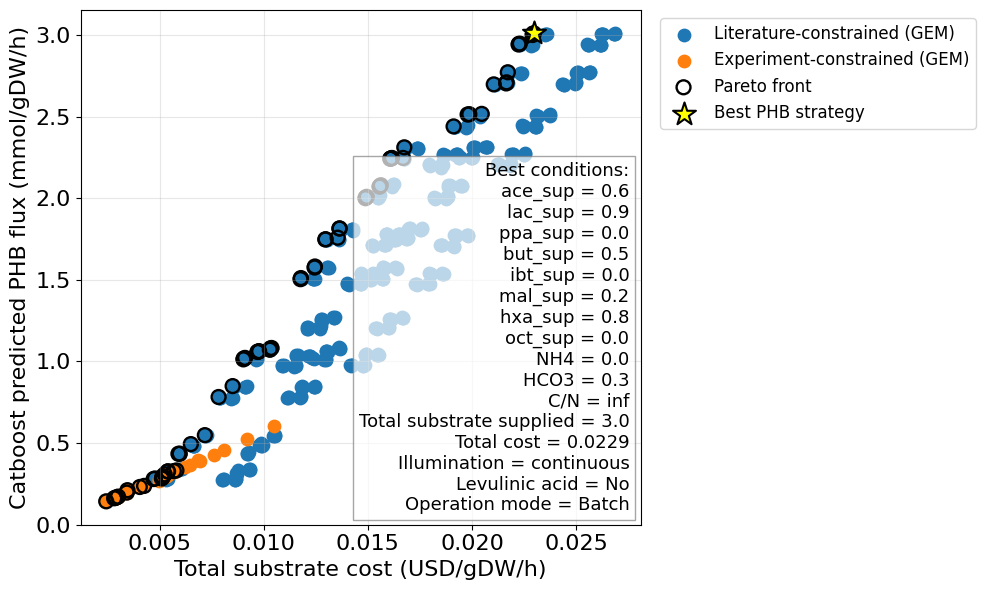

In [ ]:
# This version is convert predicted flux → PHB g/L and %PHB

from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# =========================================================
# 1. Load data
# =========================================================
#df = pd.read_csv(results_path/f"Buitron2025_dataset_augmented_VFAs_phb_with_cost_n2_{PHB_SYN_TAG}.csv")

print("\n=== Columns in dataset ===")
print(df.columns.tolist())

# =========================================================
# 2. Detect substrate columns (robust search)
# =========================================================
possible_substrates = [
    "ace","lac","ppa","but",
    "ibt","mal","hxa","oct"
]

substrates = []
for sub in possible_substrates:
    matches = [c for c in df.columns if sub.lower() in c.lower()]
    substrates.extend(matches)

print("\n=== Detected substrate columns ===")
print(substrates)

# =========================================================
# 3. Feature columns
# =========================================================
extra_features = ["C/N (molar base)_sup", "C/N (molar base)_con",
                  "total_C_sup", "total_C_con",
                  "total_N_sup", "total_N_con",
                  "total_C_cost_sup", "total_cost_sup", "total_N_cost_sup", "total_hco3_cost_sup",
                  "total_C_cost_con", "total_cost_con", "total_N_cost_con", "total_hco3_cost_con"]

extra_features = [c for c in extra_features if c in df.columns]

feature_cols = substrates + extra_features
print("\n=== Final feature columns ===")
print(feature_cols)

target = "PHB_model_flux"
y = df[target]

print("\n=== Using combined PHB flux target ===")

# =========================================================
# 5. Features with categorical variables
# =========================================================
cat_features = [
    'Type of substrate',
    'Illumination',
    'Levulinic acid',
    'Operation mode'#,
    #'Substrate_type',
    #'sub_rxn_id'
]

existing_cat_features = [c for c in cat_features if c in df.columns]
print("\n=== Categorical features used ===")
print(existing_cat_features)

X = df[feature_cols + existing_cat_features]

# =========================================================
# 6. Train / Test split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_pool = Pool(X_train, y_train, cat_features=existing_cat_features)
test_pool  = Pool(X_test,  y_test,  cat_features=existing_cat_features)

# =========================================================
# 7. Train CatBoost surrogate
# =========================================================
model = CatBoostRegressor(
    iterations=600,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    verbose=100
)

model.fit(train_pool, eval_set=test_pool)

pred_test = model.predict(test_pool)
rmse = np.sqrt(mean_squared_error(y_test, pred_test))
r2   = r2_score(y_test, pred_test)

print("\n=== CHECKPOINT 1: CatBoost Performance ===")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# =========================================================
# 8. Retrain on ALL data
# =========================================================
model.fit(Pool(X, y, cat_features=existing_cat_features))

df["PHB_pred_flux"] = model.predict(Pool(X, cat_features=existing_cat_features))

# =========================================================
# 9. Convert predicted flux → PHB g/L and %PHB
# =========================================================
# Define constants (adjust to your experimental assumptions)
#MW_PHB = 86        # g/mol (3HB monomer)
#X_gDW_L = 1.0      # biomass concentration (gDW/L)
#t = 1.0            # hours (if flux is mmol/gDW/h)

# Convert from mmol/gDW/h → g/L
#df["PHB_pred_gL"] = df["PHB_pred_flux"] * X_gDW_L * (MW_PHB / 1000) * t

# Convert to %PHB (g PHB / gDW)
#df["PHB_pred_percent"] = (df["PHB_pred_flux"] * MW_PHB * t) * 100 / (1000 * 1)

# Export best solution
best_idx_in_and_use = df["PHB_pred_flux"].idxmax()

best_solution_in_and_use = df.loc[best_idx_in_and_use].to_frame().T
best_solution_in_and_use.to_csv(results_path  / f"catboost_optimal_conditions_SUP_and_CON_{PHB_SYN_TAG}.csv", index=False)

print("\n=== Best CatBoost predicted solution ===")
print(best_solution)

# =========================================================
# 10. Pareto Optimality
# =========================================================
def is_pareto_efficient(costs, maximize_cols=None):
    costs_adj = costs.copy()
    if maximize_cols:
        for col in maximize_cols:
            costs_adj[:, col] *= -1

    n = costs_adj.shape[0]
    is_efficient = np.ones(n, dtype=bool)

    for i in range(n):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(
                costs_adj[is_efficient] < costs_adj[i], axis=1
            )
            is_efficient[i] = True
    return is_efficient

objectives = df[["PHB_pred_flux", "total_cost_sup"]].to_numpy() #total_C_in

pareto_mask_in_and_use = is_pareto_efficient(objectives, maximize_cols=[0])
pareto_solutions_in_and_use = df[pareto_mask_in_and_use]

print("\n=== CHECKPOINT 2: Pareto Solutions ===")
print(f"Number of Pareto-optimal strategies: {pareto_solutions_in_and_use.shape[0]}")

best_pareto_idx_in_and_use = pareto_solutions_in_and_use["PHB_pred_flux"].idxmax()
best_pareto_in_and_use = pareto_solutions_in_and_use.loc[[best_pareto_idx_in_and_use]]  # DataFrame

print("\nBest Pareto solution:")
print(best_pareto_in_and_use)

best_pareto_in_and_use.to_csv(results_path / f"best_pareto_conditions_SUP_and_CON_{PHB_SYN_TAG}.csv", index=False)
pareto_solutions_in_and_use.to_csv(results_path / f"pareto_optimal_conditions_SUP_and_CON_{PHB_SYN_TAG}.csv", index=False)

# =========================================================
# 11. PLOT — PHB flux vs cost
# =========================================================
COLOR_GEM  = "#1f77b4"
COLOR_EXP  = "#ff7f0e"
COLOR_BEST = "yellow"

plt.figure(figsize=(10,6))

if "is_experimental" in df.columns:
    gem_points = df[df["is_experimental"] == 0]
    plt.scatter(gem_points["total_cost_sup"], gem_points["PHB_pred_flux"],
                color=COLOR_GEM, s=80, label="Literature-constrained (GEM)")

    exp_points = df[df["is_experimental"] == 1]
    plt.scatter(exp_points["total_cost_sup"], exp_points["PHB_pred_flux"],
                color=COLOR_EXP, s=80,label="Experiment-constrained (GEM)")

plt.scatter(
    pareto_solutions_in_and_use["total_cost_sup"],
    pareto_solutions_in_and_use["PHB_pred_flux"],
    facecolors='none', edgecolors="black", s=100, linewidths=1.7,
    label="Pareto front"
)

plt.scatter(
    best_pareto_in_and_use["total_cost_sup"],
    best_pareto_in_and_use["PHB_pred_flux"],
    color=COLOR_BEST, s=300, marker="*",
    edgecolors="black", linewidths=1.5, label="Best PHB strategy"
)


# Annotation
best_solution_in_and_use = df.loc[best_idx]   # Series

#substrates = ["ace", "lac", "ppa", "but", "ibt", "mal", "hxa", "oct"]
#print("Unique substrates:", substrates)

# =========================================================
# FIXED ANNOTATION BLOCK (NO STRING NEGATION)
# =========================================================

substrates = ["ace_sup", "lac_sup", "ppa_sup", "but_sup", "ibt_sup", "mal_sup", "hxa_sup", "oct_sup"]
existing_cat_features = [c for c in cat_features if c in df.columns]

annotation_lines = []

# --- numeric substrate uptakes (negate for GEM convention) ---
for col in substrates:
    if col in best_solution_in_and_use.index:
        annotation_lines.append(
            f"{col} = {abs(float(best_solution_in_and_use[col])):.1f}"
        )

if "nh4_sup" in best_solution_in_and_use:
    annotation_lines.append(
        f"NH4 = {abs(float(best_solution_in_and_use['nh4_sup'])):.1f}"
    )

if "hco3_sup" in best_solution_in_and_use:
    annotation_lines.append(
        f"HCO3 = {abs(float(best_solution_in_and_use['hco3_sup'])):.1f}"
    )

if "C/N (molar base)_sup" in best_solution_in_and_use:
    annotation_lines.append(
        f"C/N = {abs(float(best_solution_in_and_use['C/N (molar base)_sup'])):.1f}"
    )

if "total_C_sup" in best_solution_in_and_use:
    annotation_lines.append(
        f"Total substrate supplied = {abs(float(best_solution_in_and_use['total_C_sup'])):.1f}"
    )

if "total_cost_sup" in best_solution_in_and_use:
    annotation_lines.append(
        f"Total cost = {abs(float(best_solution_in_and_use['total_cost_sup'])):.4f}"
    )


# --- categorical variables
for col in existing_cat_features:
    if col == "Type of substrate":
        continue
    if col not in substrates:
        annotation_lines.append(f"{col} = {best_solution_in_and_use[col]}")

# assemble text
feature_text = "Best conditions:\n" + "\n".join(annotation_lines)


plt.annotate(
    feature_text,
    xy=(0.98, 0.02),
    xycoords='axes fraction',
    fontsize=13,
    ha='right',
    va='bottom',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7)
)


plt.xlabel("Total substrate cost (USD/gDW/h)", fontsize=16)
plt.ylabel("Catboost predicted PHB flux (mmol/gDW/h)", fontsize=16)
#plt.title(
#    f"CatBoost-predicted PHB Flux + Pareto Optimization (n={len(df)})",
#    fontsize=17
#)

plt.grid(True, alpha=0.3)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(loc="upper left", bbox_to_anchor=(1.02,1), fontsize=12)
plt.tight_layout()
plt.savefig(results_path  / f"PHB_catboost_pareto_plot_SUP_and_CON_{PHB_SYN_TAG}.png", dpi=300, bbox_inches="tight")
plt.show()



# Cross-validation catboost

Using dataset augmented with metabolic features

In [ ]:
from catboost import cv

cv_params = {
    "iterations": 1000,
    "learning_rate": 0.03,
    "depth": 8,
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "random_seed": 42,
    "verbose": False
}

full_pool = Pool(X, y, cat_features=cat_features)

#cv() is a CatBoost function, not a generic CV wrapper.
cv_results = cv(
    pool=full_pool,
    params=cv_params,
    fold_count=5,
    shuffle=True,
    partition_random_seed=42
)

cv_rmse_mean_augmented = cv_results["test-RMSE-mean"].iloc[-1]
cv_rmse_std_augmented  = cv_results["test-RMSE-std"].iloc[-1]

print(f"\n5-fold CV RMSE with metabolic augmentation: {cv_rmse_mean_augmented:.4f} ± {cv_rmse_std_augmented:.4f}")


# *All Pareto solutions for TFA

In [40]:
# Extract the data of the best pareto optimal solutions for TFA

PHB_SYN_UB_VALUES = [0.3978, 1000]  # 0.0167 excluded

all_pareto_dfs = []  # to optionally merge across PHB_SYN_UB later

for PHB_SYN_UB in PHB_SYN_UB_VALUES:

    print(f"\nPHB_SYN_UB_VALUE: {PHB_SYN_UB}")
    PHB_SYN_TAG = f"{PHB_SYN_UB:g}"

    # =========================================================
    # 1. Load best Pareto solutions from different strategies
    # =========================================================
    best_pareto_sup = pd.read_csv(
        PHB_PARETO_DIR / f"04_best_pareto_conditions_SUP_{PHB_SYN_TAG}.csv"
    )
    best_pareto_con = pd.read_csv(
        PHB_PARETO_DIR / f"04_best_pareto_conditions_CON_{PHB_SYN_TAG}.csv"
    )

    best_pareto_sup_con = pd.read_csv(
        PHB_PARETO_DIR / f"04_best_pareto_conditions_SUP_CON_{PHB_SYN_TAG}.csv"
    )

    best_pareto_pfba = pd.read_csv(
        PHB_PARETO_DIR / f"04_best_pareto_conditions_CON_PFBA_{PHB_SYN_TAG}.csv"
    )

    best_pareto_sup_pfba = pd.read_csv(
        PHB_PARETO_DIR / f"04_best_pareto_conditions_SUP_CON_PFBA_{PHB_SYN_TAG}.csv"
    )

    # =========================================================
    # 2. Add metadata (VERY important for TFA interpretation)
    # =========================================================
    best_pareto_sup["optimization_strategy"] = "SUP"
    best_pareto_con["optimization_strategy"] = "CON"
    best_pareto_sup_con["optimization_strategy"] = "SUP_and_CON"
    best_pareto_pfba["optimization_strategy"] = "PFBA"
    best_pareto_sup_pfba["optimization_strategy"] = "SUP_and_PFBA"


    for df_tmp in [best_pareto_sup, best_pareto_con, best_pareto_sup_con, best_pareto_pfba, best_pareto_sup_pfba]:
        df_tmp["PHB_SYN_UB"] = PHB_SYN_UB

    # =========================================================
    # 3. Concatenate
    # =========================================================
    best_pareto_all = pd.concat(
       [best_pareto_sup, best_pareto_con, best_pareto_sup_con, best_pareto_pfba, best_pareto_sup_pfba],
        axis=0,
        ignore_index=True
    )

    # =========================================================
    # 5. Save dataset for this PHB_SYN_UB
    # =========================================================
    out_path = PHB_PARETO_DIR / f"04_pareto_best_all_strategies_{PHB_SYN_TAG}.csv"
    print(len(best_pareto_all.columns))
    best_pareto_all.to_csv(out_path, index=False)

    print(f"Saved: {out_path}")

    all_pareto_dfs.append(best_pareto_all)

# =========================================================
# 6. Global dataset across PHB_SYN_UB values
# =========================================================
pareto_best_global = pd.concat(all_pareto_dfs, ignore_index=True)

global_out = PHB_PARETO_DIR / "04_pareto_best_all_1_PHB_SYN_UB.csv"
pareto_best_global.to_csv(global_out, index=False)

print(f"\nGlobal Pareto dataset saved to:\n{global_out}")



PHB_SYN_UB_VALUE: 0.3978
102
Saved: /content/drive/MyDrive/metabolic_modelling/phb-optimization-rpalustris/results/phb/pareto/04_pareto_best_all_strategies_0.3978.csv

PHB_SYN_UB_VALUE: 1000
102
Saved: /content/drive/MyDrive/metabolic_modelling/phb-optimization-rpalustris/results/phb/pareto/04_pareto_best_all_strategies_1000.csv

Global Pareto dataset saved to:
/content/drive/MyDrive/metabolic_modelling/phb-optimization-rpalustris/results/phb/pareto/04_pareto_best_all_1_PHB_SYN_UB.csv


# *** Additional analysis ***
The following analysis can provided further insights into PHB optimization and model test performance. The following codes need to be adapted.

# Opt: Comparative Analysis of modeling strategies



1. Pareto Optimality alone
2. CatBoost alone
3. CatBoost + Pareto Optimality



## Opt: Pareto alone
This code runs Pareto on the GEM augmented dataset but does not include catboost as surrogate predicting engine

In [ ]:
df_results = pd.read_csv(PHB_GEM_AUGMENTATION_DIR/ f"04_Buitron2025_dataset_augmented_VFAs_phb_with_cost_n2_{PHB_SYN_TAG}.csv")
print(df_results.columns)


def is_pareto_efficient(costs: np.ndarray, maximize_cols=None) -> np.ndarray:
    """
    Return boolean mask of Pareto-efficient rows.
    By default all objectives are minimized. Columns in `maximize_cols`
    are negated to convert them to minimization before testing.
    """
    costs_adj = np.array(costs, copy=True)
    if maximize_cols is not None and len(np.atleast_1d(maximize_cols)) > 0:
        costs_adj[:, np.atleast_1d(maximize_cols)] *= -1

    n = costs_adj.shape[0]
    is_eff = np.ones(n, dtype=bool)

    for i in range(n):
        if not is_eff[i]:
            continue

        others = np.where(is_eff)[0]
        others = others[others != i]
        if others.size == 0:
            continue

        no_worse = np.all(costs_adj[others] <= costs_adj[i], axis=1)
        strictly_better = np.any(costs_adj[others] < costs_adj[i], axis=1)
        dominated_by_any = np.any(no_worse & strictly_better)

        if dominated_by_any:
            is_eff[i] = False
        else:
            # Optional pruning: drop points dominated by i to speed up subsequent checks
            no_worse_i = np.all(costs_adj[i] <= costs_adj[others], axis=1)
            strictly_better_i = np.any(costs_adj[i] < costs_adj[others], axis=1)
            dominated_by_i = no_worse_i & strictly_better_i
            is_eff[others[dominated_by_i]] = False

    return is_eff


# Prepare data: PHB_flux (maximize), total_cost (minimize), total_uptake (minimize)
objectives = df_results[['PHB_model_flux', 'total_cost']].to_numpy()
pareto_mask = is_pareto_efficient(objectives, maximize_cols=[0])

pareto_solutions = df_results[pareto_mask]

print(f"Found {pareto_solutions.shape[0]} Pareto optimal solutions.")

# Find Pareto solution with max PHB_flux
idx_max_phb_pareto = pareto_solutions['PHB_model_flux'].idxmax()
max_phb_pareto_solution = pareto_solutions.loc[idx_max_phb_pareto]


# Extract that row
optimal_solution = df_results.loc[idx_max_phb_pareto]

print("Optimal solution with highest PHB production:")
print(optimal_solution)

n= len(df_results)

plt.figure(figsize=(10,6))

# Recommended scientific palette
COLOR_GEM = "#1A76D2"      # blue
COLOR_EXP = "#FF6F61"      # green
COLOR_BEST = "#FFB000"     # amber gold


# GEM-augmented points
gem_points = df_results[df_results['is_experimental']==0]
plt.scatter(gem_points['total_cost'], gem_points['PHB_model_flux'],
            color=COLOR_GEM, s=80, label='Literature-constrained (GEM)')

# Experimental points
exp_points = df_results[df_results['is_experimental']==1]
plt.scatter(exp_points['total_cost'], exp_points['PHB_model_flux'],
            color=COLOR_EXP, s=80, label='Experiment-constrained (GEM)')

# Pareto front
plt.scatter(pareto_solutions['total_cost'], pareto_solutions['PHB_model_flux'],
            facecolors='none', edgecolors='black', s=80, linewidths=1.5, label='Pareto front')


# Highlight best Pareto PHB solution with yellow star
idx_max_phb_pareto = pareto_solutions['PHB_model_flux'].idxmax()
best_solution = pareto_solutions.loc[idx_max_phb_pareto]

# Best Pareto solution
plt.scatter(best_solution['total_cost'], best_solution['PHB_model_flux'],
            color=COLOR_BEST, s=250, marker='*', edgecolors='black', linewidths=1.5,
            label='Best Pareto PHB flux')

# ---------------------------
# Annotate best solution
# ---------------------------

substrates = ["ace", "lac", "ppa", "but", "ibt", "mal", "hxa", "oct"]
print("Unique substrates:", substrates)

feature_text = "Best conditions:\n" + "\n".join(
    [f"{col} = {-best_solution[col]:.3f}" for col in substrates] +
    [f"C/N ratio = {-best_solution['C/N (molar base)']:.2f}",
     f"PHB = {best_solution['PHB_model_flux']:.4f}",
     #f"PHV = {best_solution['PHV_model_flux']:.4f}",
     #f"phb = {best_solution['phb_model_flux']:.4f}",
     f"Total C uptake = {-best_solution['total_uptake']:.2f}",
     f"Total cost = {best_solution['total_cost']:.4f}"]
)

plt.annotate(
    feature_text,
    xy=(0.98, 0.02),                 # lower-right corner
    xycoords='axes fraction',
    fontsize=13,
    ha='right',
    va='bottom',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7)
)

# ---------------------------
# Axis labels, title, ticks
# ---------------------------
plt.xlabel('Total substrate cost (USD/gDW/h)', fontsize=16)
plt.ylabel('GEM predicted PHB flux (mmol/gDW/h)', fontsize=16)

plt.title(f'GEM-predicted PHB Flux vs Total Substrate Cost (n={n})',fontsize=17)

# Tick font size
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Grid and legend
plt.grid(True, alpha=0.3)

# Legend outside
plt.legend(loc='upper left', bbox_to_anchor=(1,1), fontsize=13)

plt.tight_layout()
plt.savefig(PHB_FIGURES_DIR  / f"04_PHB_flux_predictions_augmented_data_Pareto_2_objectives_{PHB_SYN_TAG}.png", dpi=300, bbox_inches='tight')
plt.show()


## Opt: Catboost alone

This code runs Catboost on the GEM augmented dataset but does not run Pareto optimality

In [ ]:
df = pd.read_csv(PHB_GEM_AUGMENTATION_DIR /f"03_Buitron2025_dataset_augmented_VFAs_phb_with_cost_n2_{PHB_SYN_TAG}.csv")
df[['Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)', '% PHV',
                '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)',
                'Time (d)', 'g substrate COD/L', 'mg N/L', 'C/N (molar base)', 'mg ethanol/L',
                'Fraction mineral medium', 'Fe (mg Ferric citrate/L)',
                '% Volume exchange', 'PHB_exp_flux', 'Biomass_model_flux',
                'is_experimental',  "ace", "lac", "ppa", "but", "ibt", "mal", "hxa", "oct",
                'C_total', 'total_uptake', 'total_cost']]

0:	learn: 0.2327103	test: 0.2623171	best: 0.2623171 (0)	total: 14.5ms	remaining: 14.4s
100:	learn: 0.0293346	test: 0.0427855	best: 0.0427855 (100)	total: 933ms	remaining: 8.3s
200:	learn: 0.0079471	test: 0.0187155	best: 0.0187155 (200)	total: 1.78s	remaining: 7.1s
300:	learn: 0.0036240	test: 0.0152753	best: 0.0152753 (300)	total: 2.82s	remaining: 6.56s
400:	learn: 0.0026687	test: 0.0145056	best: 0.0145056 (400)	total: 3.98s	remaining: 5.95s
500:	learn: 0.0018049	test: 0.0140268	best: 0.0140268 (500)	total: 5.03s	remaining: 5.01s
600:	learn: 0.0012925	test: 0.0138223	best: 0.0138223 (600)	total: 6.92s	remaining: 4.6s
700:	learn: 0.0009801	test: 0.0136690	best: 0.0136690 (700)	total: 9.69s	remaining: 4.13s
800:	learn: 0.0007359	test: 0.0135650	best: 0.0135650 (800)	total: 11.1s	remaining: 2.75s
900:	learn: 0.0005802	test: 0.0134993	best: 0.0134993 (900)	total: 12.3s	remaining: 1.35s
999:	learn: 0.0004711	test: 0.0134599	best: 0.0134599 (999)	total: 13.4s	remaining: 0us

bestTest = 0.0134

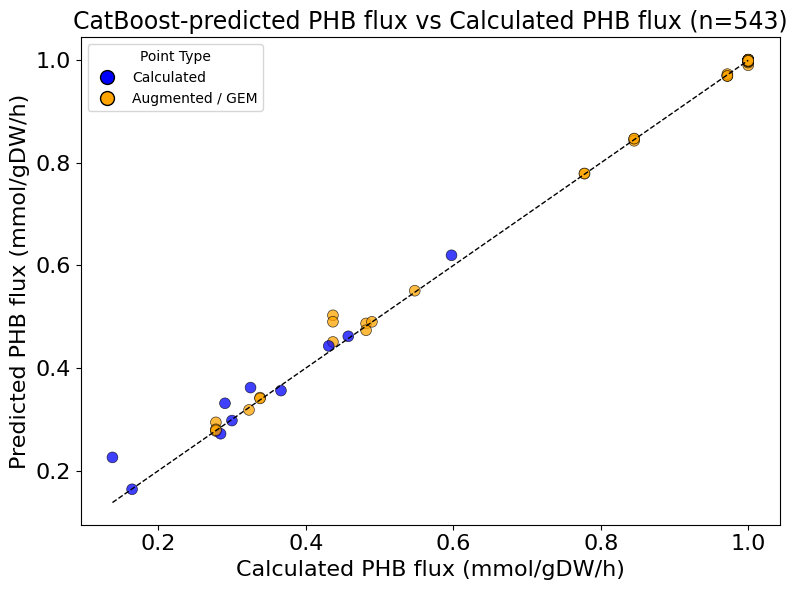

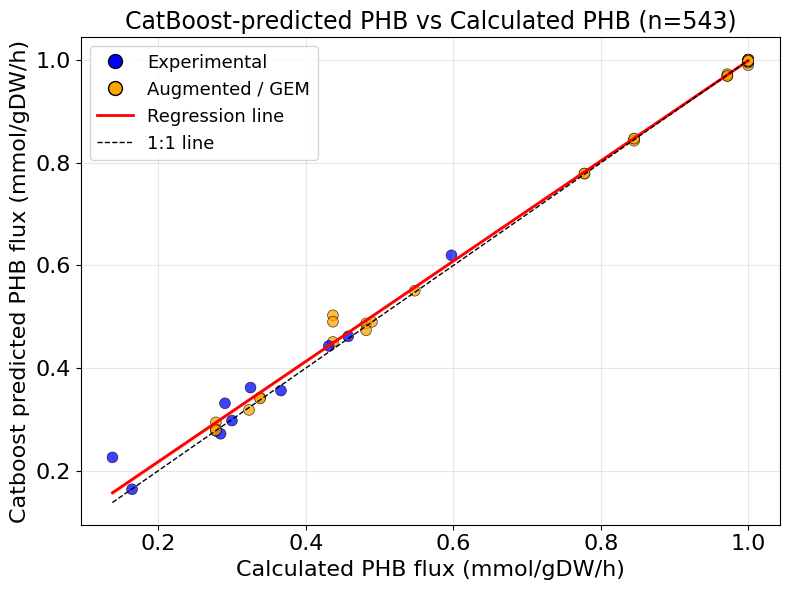

In [ ]:
# ---------------------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------------------
df = pd.read_csv(PHB_GEM_AUGMENTATION_DIR/ f"03_Buitron2025_dataset_augmented_VFAs_phb_with_cost_n2_{PHB_SYN_TAG}.csv")

# ---------------------------------------------------------
# 2. DEFINE TARGET AND FEATURES
# ---------------------------------------------------------
# Change this line if needed:
target_column = "PHB_model_flux"   # or "PHB_mgL", depending on your goal

y = df[target_column]
X = df.drop(columns=[target_column])

# Use your feature lists directly:
cat_features = [
    'Type of substrate',
    'Illumination',
    'Levulinic acid',
    'Operation mode'
]


num_features = ['Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)', '% PHV',
                '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)',
                'Time (d)', 'g substrate COD/L', 'mg N/L', 'C/N (molar base)', 'mg ethanol/L',
                'Fraction mineral medium', ' g NaHCO3/L', 'Fe (mg Ferric citrate/L)',
                '% Volume exchange', 'Biomass_mgL', 'PHB_mgL', 'COD_gL_fed', 'biomass_gL',
                'PHB_exp_flux', 'Acetate_flux', 'Biomass_model_flux', 'Substrate_model_flux',
                'is_experimental', "ace", "lac", "ppa", "but", "ibt", "mal", "hxa", "oct",
                'C_total', 'N_total', 'total_uptake', 'total_cost']

# CatBoost pools
train_pool = Pool(X, y, cat_features=cat_features)

# ---------------------------------------------------------
# 3. TRAIN / TEST SPLIT
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_features)

# ---------------------------------------------------------
# 4. TRAIN MODEL
# ---------------------------------------------------------
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    verbose=100
)

model.fit(train_pool, eval_set=test_pool)

model.save_model(PHB_CATBOOST_DIR/ 'catboost_alone_model.cbm')


# ---------------------------------------------------------
# 5. PREDICT AND EVALUATE
# ---------------------------------------------------------
pred_test = model.predict(test_pool)

rmse = np.sqrt(mean_squared_error(y_test, pred_test))
r2   = r2_score(y_test, pred_test)

print(f"\nRMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")


# ---------------------------------------------------------
# 6. SCATTER PLOT: Experimental vs Predicted PHB
# ---------------------------------------------------------

# Extract is_experimental for the test set
is_exp_test = X_test["is_experimental"].values

# Map 0 → orange , 1 → blue (or whatever colors you prefer)
color_map = {0: "orange", 1: "blue"}
colors = [color_map[val] for val in is_exp_test]

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    pred_test,
    c=colors,
    alpha=0.75,
     s=60,
    edgecolor="k",
    linewidth=0.5
)


n = len(df)
plt.xlabel("Calculated PHB flux (mmol/gDW/h)", fontsize=16)
plt.ylabel("Predicted PHB flux (mmol/gDW/h)", fontsize=16)
plt.title(f"CatBoost-predicted PHB flux vs Calculated PHB flux (n={n})", fontsize=17)


# Tick font size
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# identity line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'k--', lw=1
)

# Custom legend for the two classes
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Calculated',
           markerfacecolor='blue', markersize=10, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='Augmented / GEM',
           markerfacecolor='orange', markersize=10, markeredgecolor='k')
]

plt.legend(handles=legend_elements, title="Point Type")

plt.tight_layout()
plt.savefig(PHB_FIGURES_DIR  / "03_catboost_alone_pred_PHB_vs_calc_PHB_flux.png", dpi=300, bbox_inches="tight")

plt.show()


# ---------------------------------------------------------
# 6b. SCATTER PLOT WITH REGRESSION + 95% CI
# ---------------------------------------------------------
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Colors for experimental vs GEM
color_map = {0: "orange", 1: "blue"}
colors = [color_map[val] for val in X_test["is_experimental"].values]

plt.figure(figsize=(8,6))

# Scatter points
plt.scatter(
    y_test,
    pred_test,
    c=colors,
    alpha=0.75,
    s=60,
    edgecolor="k",
    linewidth=0.5
)

# ----------------------------
# Regression + 95% CI
# ----------------------------
# Regression: predicted = a + b * calculated
slope, intercept, r_val, p_val, std_err = stats.linregress(y_test, pred_test)

# Points for regression line
x_line = np.linspace(y_test.min(), y_test.max(), 200)
y_line = intercept + slope * x_line

# 95% CI
n = len(y_test)
t_value = stats.t.ppf(1 - 0.025, df=n - 2)

# Standard error of prediction
pred_err = std_err * np.sqrt(
    1/n + (x_line - np.mean(y_test))**2 /
    np.sum((y_test - np.mean(y_test))**2)
)

y_upper = y_line + t_value * pred_err
y_lower = y_line - t_value * pred_err

# Plot regression line
plt.plot(x_line, y_line, color="red", lw=2, label="Regression line")

# Shade CI
plt.fill_between(
    x_line, y_lower, y_upper,
    color="red", alpha=0.2, label="95% CI"
)

# Identity line (perfect prediction)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'k--', lw=1, label="1:1 line"
)

# ----------------------------
# Labels & formatting
# ----------------------------
plt.xlabel("Calculated PHB flux (mmol/gDW/h)", fontsize=16)
plt.ylabel("Catboost predicted PHB flux (mmol/gDW/h)", fontsize=16)
plt.title(f"CatBoost-predicted PHB vs Calculated PHB (n={len(df)})", fontsize=17)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(alpha=0.3)

# Custom legend (experimental vs GEM)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label='Experimental', markerfacecolor='blue',
           markeredgecolor='k', markersize=10),
    Line2D([0], [0], marker='o', color='w',
           label='Augmented / GEM', markerfacecolor='orange',
           markeredgecolor='k', markersize=10),
    Line2D([], [], color='red', lw=2, label="Regression line"),
    Line2D([], [], color='k', lw=1, linestyle='--', label="1:1 line")
]
plt.legend(handles=legend_elements, fontsize=13)

plt.tight_layout()
plt.savefig(PHB_FIGURES_DIR / "03_catboost_pred_PHB_vs_calc_PHB_flux_reg_line.png", dpi=300, bbox_inches="tight")

plt.show()



## Opt: CatBoost PHB prediction for a new point

This code uses the previously trained catboost model for predicting the PHB flux of a new point

In [ ]:
new_point = {
    'Type of substrate': 'acetate',      # must be string
    'Illumination': 'continuous',        # string
    'Levulinic acid': 'no',              # string
    'Operation mode': 'batch',           # string
    'Substrate_type': 'ac',              # string
    'sub_rxn_id': 'r_ac_e',              # string

    # Example numerical values (yours will differ)
    'Experiment': 0,
    'Biomass (mg dw/L)': 300,
    'PHB (mg/L)': 0,
    '% PHB': 0,
    'PHV (mg/L)': 0,
    '% PHV': 0,
    '5-ALA (micromol/L)': 1.2,
    'Q10 (mg/g dw)': 5.1,
    'Carotenoids (mg/g dw)': 0.4,
    'Experiment.1': 0,
    'Time (d)': 3.0,
    'g substrate COD/L': 2.5,
    'mg N/L': 15,
    'C/N (molar base)': 18,
    'mg ethanol/L': 0,
    'Fraction mineral medium': 0.5,
    ' g NaHCO3/L': 1.0,
    'Fe (mg Ferric citrate/L)': 3.0,
    '% Volume exchange': 20,
    'Row': 1,
    'Biomass_mgL': 350,
    'PHB_mgL': 0,
    'COD_gL_fed': 3.0,
    'biomass_gL': 0.35,
    'PHB_exp_flux': 0.12,
    'Acetate_flux': 1.4,
    'Biomass_model_flux': 0.08,
    'Substrate_model_flux': 1.5,
    'is_experimental': 0,
    'ac': 1.0,
    'fum': 0.2,
    'hxa': 0.1,
    'ppa': 0.3,
    'lac': 0.0,
    'but': 0.1,
    'succ': 0.4,
    'C_total': 6.2,
    'N_total': 1.1,
    'C/N_ratio': 5.6,
    'total_uptake': 3.4,
    'total_cost': 5.1
}

# Build dataframe
new_df = pd.DataFrame([new_point])

# Convert categorical features to string
for c in cat_features:
    new_df[c] = new_df[c].astype(str)

pred_new = model.predict(new_df)[0]
print("Predicted PHB:", pred_new)


# Plot overlaying with Lit data


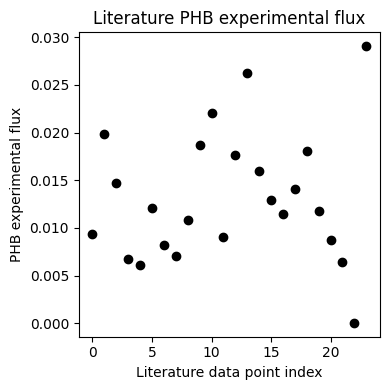

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))
plt.scatter(range(len(df_lit)), df_lit["PHB_exp_flux_lit"], color="black")
plt.xlabel("Literature data point index")
plt.ylabel("PHB experimental flux")
plt.title("Literature PHB experimental flux")
plt.tight_layout()
plt.show()


Main dataset columns: ['Experiment', 'Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)', '% PHV', '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)', 'Experiment.1', 'Time (d)', 'g substrate COD/L', 'Type of substrate', 'mg N/L', 'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium', 'g NaHCO3/L', 'Illumination', 'Levulinic acid', 'Fe (mg Ferric citrate/L)', 'Operation mode', '% Volume exchange', 'Row', 'Time_h', 'Biomass_gL', 'PHB_exp_flux_exp', 'Substrate_exp_flux', 'PHB_model_flux', 'Substrate_model_flux', 'NH4_model_flux', 'PHB_fva_width', 'is_experimental', 'ac', 'fum', 'hxa', 'ppa', 'lac', 'but', 'succ', 'Biomass_model_flux', 'C_total', 'N_total', 'C/N_ratio', 'total_uptake', 'total_cost']
Literature dataset columns: ['Paper number', 'Strain', 'Inoculum size (initial biomass)', 'Time (d)', 'Preculture conditions', 'Type of substrate', 'C concentration mg/L', 'N source', 'mg N/L', 'C/N (molar base)', 'g substrate COD/L', 'Medium ', 'Medium supplementation

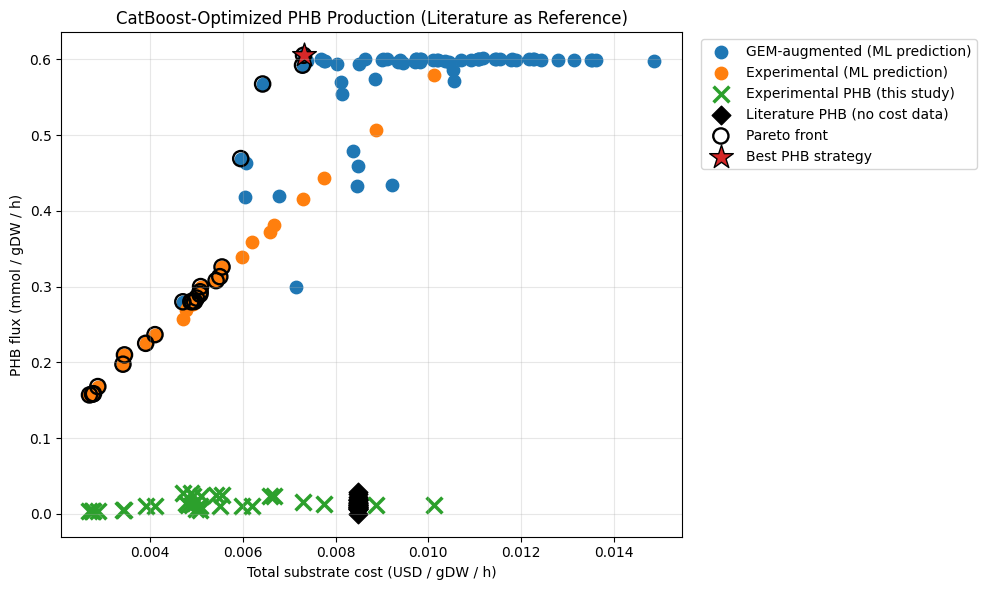

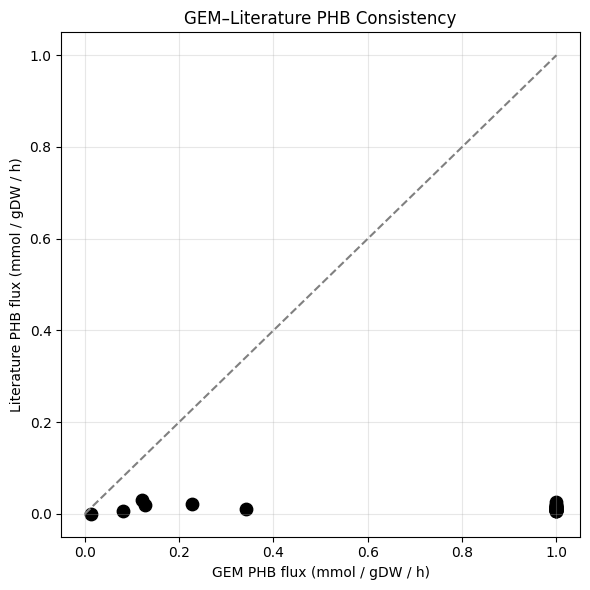

In [ ]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


# =========================================================
# 1. Load data
# =========================================================
df = pd.read_csv(f"Buitron2025_dataset_augmented_phb_with_cost_{PHB_SYN_TAG}.csv")
df_lit = pd.read_csv(base_model_dir/f"Literature_dataset_augmented_with_FBA_PHB_{PHB_SYN_TAG}.csv")

# ---------------------------------------------------------
# Rename PHB experimental columns (CRITICAL)
# ---------------------------------------------------------
if "PHB_exp_flux" in df.columns:
    df = df.rename(columns={"PHB_exp_flux": "PHB_exp_flux_exp"})

if "PHB_exp_flux" in df_lit.columns:
    df_lit = df_lit.rename(columns={"PHB_exp_flux": "PHB_exp_flux_lit"})


print("Main dataset columns:", df.columns.tolist())
print("Literature dataset columns:", df_lit.columns.tolist())


# =========================================================
# 2. Detect substrate columns
# =========================================================
possible_substrates = [
    "acetate", "butyrate", "propionate", "lactate",
    "succinate", "fumarate", "hexanoate"
]

substrates = []
for sub in possible_substrates:
    substrates += [c for c in df.columns if sub.lower() in c.lower()]

substrates = list(set(substrates))
print("Detected substrates:", substrates)


# =========================================================
# 3. Feature columns
# =========================================================
extra_features = ["C/N_ratio", "total_uptake", "total_cost"]
extra_features = [c for c in extra_features if c in df.columns]

feature_cols = substrates + extra_features
print("Final feature columns:", feature_cols)

target = "PHB_model_flux"
y = df[target]


# =========================================================
# 4. Categorical features
# =========================================================
cat_features = [
    "Type of substrate",
    "Illumination",
    "Levulinic acid",
    "Operation mode"
]

existing_cat_features = [c for c in cat_features if c in df.columns]
print("Categorical features:", existing_cat_features)

X = df[feature_cols + existing_cat_features]


# =========================================================
# 5. Train / test split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_pool = Pool(X_train, y_train, cat_features=existing_cat_features)
test_pool = Pool(X_test, y_test, cat_features=existing_cat_features)


# =========================================================
# 6. Train CatBoost
# =========================================================
model = CatBoostRegressor(
    iterations=600,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

model.fit(train_pool, eval_set=test_pool)

pred_test = model.predict(test_pool)
rmse = np.sqrt(mean_squared_error(y_test, pred_test))
r2 = r2_score(y_test, pred_test)

print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")


# =========================================================
# 7. Retrain on all data
# =========================================================
model.fit(Pool(X, y, cat_features=existing_cat_features))
df["PHB_pred_flux"] = model.predict(Pool(X, cat_features=existing_cat_features))


# =========================================================
# 8. Pareto optimality
# =========================================================
def is_pareto_efficient(costs, maximize_cols=None):
    costs = costs.copy()
    if maximize_cols:
        for col in maximize_cols:
            costs[:, col] *= -1

    n = costs.shape[0]
    is_eff = np.ones(n, dtype=bool)

    for i in range(n):
        if is_eff[i]:
            is_eff[is_eff] = np.any(costs[is_eff] < costs[i], axis=1)
            is_eff[i] = True
    return is_eff


objectives = df[
    ["PHB_pred_flux", "total_cost", "Biomass_model_flux"]
].to_numpy()

pareto_mask = is_pareto_efficient(objectives, maximize_cols=[0, 2])
pareto_solutions = df[pareto_mask]

best_idx = pareto_solutions["PHB_pred_flux"].idxmax()
best_pareto = pareto_solutions.loc[best_idx]


# =========================================================
# 9. FIGURE 1 — PHB vs COST (WITH LITERATURE SHOWN)
# =========================================================
plt.figure(figsize=(10, 6))

# ML predictions
gem_points = df[df["is_experimental"] == 0]
exp_points = df[df["is_experimental"] == 1]

plt.scatter(
    gem_points["total_cost"], gem_points["PHB_pred_flux"],
    s=80, label="GEM-augmented (ML prediction)"
)

plt.scatter(
    exp_points["total_cost"], exp_points["PHB_pred_flux"],
    s=80, label="Experimental (ML prediction)"
)

# Experimental PHB (this study)
if "PHB_exp_flux_exp" in df.columns:
    plt.scatter(
        exp_points["total_cost"], exp_points["PHB_exp_flux_exp"],
        marker="x", s=130, linewidths=2.5,
        label="Experimental PHB (this study)"
    )

# ---------------------------------------------------------
# LITERATURE PHB — USE PROXY COST (VISIBLE & HONEST)
# ---------------------------------------------------------
if "PHB_exp_flux_lit" in df_lit.columns:
    proxy_cost = np.median(df["total_cost"])

    plt.scatter(
        np.full(len(df_lit), proxy_cost),
        df_lit["PHB_exp_flux_lit"],
        marker="D", s=90, color="black",
        label="Literature PHB (no cost data)"
    )

# Pareto front
plt.scatter(
    pareto_solutions["total_cost"],
    pareto_solutions["PHB_pred_flux"],
    facecolors="none", edgecolors="black",
    s=120, linewidths=1.7, label="Pareto front"
)

# Best solution
plt.scatter(
    best_pareto["total_cost"], best_pareto["PHB_pred_flux"],
    marker="*", s=320, edgecolors="black",
    label="Best PHB strategy"
)

plt.xlabel("Total substrate cost (USD / gDW / h)")
plt.ylabel("PHB flux (mmol / gDW / h)")
plt.title("CatBoost-Optimized PHB Production (Literature as Reference)")
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"FIG1_PHB_vs_cost_with_literature_{PHB_SYN_TAG}.png", dpi=300)
plt.show()


# =========================================================
# 10. FIGURE 2 — GEM vs LITERATURE PHB (CORRECT VALIDATION)
# =========================================================
if {"PHB_model_flux", "PHB_exp_flux_lit"}.issubset(df_lit.columns):

    plt.figure(figsize=(6, 6))

    plt.scatter(
        df_lit["PHB_model_flux"],
        df_lit["PHB_exp_flux_lit"],
        color="black", s=80
    )

    minv = min(df_lit["PHB_model_flux"].min(),
               df_lit["PHB_exp_flux_lit"].min())
    maxv = max(df_lit["PHB_model_flux"].max(),
               df_lit["PHB_exp_flux_lit"].max())

    plt.plot([minv, maxv], [minv, maxv], "--", color="gray")

    plt.xlabel("GEM PHB flux (mmol / gDW / h)")
    plt.ylabel("Literature PHB flux (mmol / gDW / h)")
    plt.title("GEM–Literature PHB Consistency")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(project_root / "results" / f"FIG2_GEM_vs_Literature_PHB_{PHB_SYN_TAG}.png", dpi=300)
    plt.show()


# Catboost + PSO

Particle Swarm Optimization is not the best optimization method in combination with GEM (which optimizes the flux) for this since focuses in 1 objective at the time and of course it finds the highest GEM flux values


In [ ]:
# Full fixed pipeline: CatBoost surrogate + numeric-only PSO + PHB conversions + CSV output
# Includes R2, Pearson, RMSE, MAPE evaluations
# Usage: place in same folder as your CSV and run.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr, stats
import random
import os

PHB_SYN_UB_VALUES = [0.3978, 1000]

for PHB_SYN_UB in PHB_SYN_UB_VALUES:

    print(f"\n==============================")
    print(f"Running for PHB_SYN_UB = {PHB_SYN_UB}")
    print(f"==============================")

    PHB_SYN_TAG = f"{PHB_SYN_UB:g}"

    CSV_PATH = results_path / f"Buitron2025_dataset_augmented_VFAs_phb_with_cost_n2_{PHB_SYN_TAG}.csv"
    SAVE_PSO_CSV = results_path / f"catboost_pso_optimal_conditions_{PHB_SYN_TAG}.csv"
    SAVE_PLOT = project_root / "results" / f"catboost_predPHB_vs_cost_pso_annotated_{PHB_SYN_TAG}.png"

    df = pd.read_csv(CSV_PATH)
    RANDOM_SEED = 42

    # PHB conversion assumptions
    MW_PHB = 86.0       # g/mol (3HB monomer)
    X_gDW_L = 1.0       # biomass concentration (gDW/L)
    t_h = 1.0           # integration time (h)

    np.random.seed(RANDOM_SEED)
    random.seed(RANDOM_SEED)

    # Remove duplicate columns
    if df.columns.duplicated().any():
        print("Warning: duplicate columns detected. Removing duplicates.")
        df = df.loc[:, ~df.columns.duplicated()]

    print("\nLoaded columns:")
    print(df.columns.tolist())

    if TARGET_COL not in df.columns:
        raise KeyError(f"Target column '{TARGET_COL}' not in CSV.")

    # -------------------------
    # 2) Detect substrate columns
    # -------------------------
    substrates = ['ace', 'lac', 'ppa', 'but', 'ibt', 'mal', 'hxa', 'oct']

    detected_substrates = []
    for sub in substrates:
        matches = [c for c in df.columns if sub.lower() in c.lower()]
        detected_substrates.extend(matches)
    detected_substrates = list(dict.fromkeys(detected_substrates))
    print("\nDetected substrate columns:", detected_substrates)

    # -------------------------
    # 3) Extra numeric features
    # -------------------------
    extra_numeric_features = ["C/N (molar base)", "total_uptake", "total_cost"]
    extra_numeric_features = [c for c in extra_numeric_features if c in df.columns]
    print("Extra numeric features:", extra_numeric_features)

    # Combine candidate numeric columns, **remove 'Levulinic acid'**
    candidate_numeric = detected_substrates + extra_numeric_features
    candidate_numeric = [c for c in candidate_numeric if c in df.columns]
    #candidate_numeric.remove('Levulinic acid')
    print("Candidate numeric columns:", candidate_numeric)

    # -------------------------
    # 4) Detect categorical columns
    # -------------------------
    predefined_cat_features = [
        'Type of substrate', 'Illumination', 'Levulinic acid',
        'Operation mode', 'Substrate_type'
    ]
    predefined_cat_features = [c for c in predefined_cat_features if c in df.columns]

    inferred_cat_features = [c for c in df.columns if df[c].dtype == "object" and c != TARGET_COL]

    cat_features = []
    for c in predefined_cat_features + inferred_cat_features:
        if c not in cat_features:
            cat_features.append(c)

    print("Categorical columns:", cat_features)

    # Convert categorical columns to string
    for col in cat_features:
        df[col] = df[col].astype(str)

    # -------------------------
    # 5) Build training features
    # -------------------------
    features_for_training = candidate_numeric + [c for c in cat_features if c not in candidate_numeric]
    if TARGET_COL in features_for_training:
        features_for_training.remove(TARGET_COL)

    X = df[features_for_training].copy()
    y = df[TARGET_COL].copy()

    # Coerce numeric
    for col in X.columns:
        if col not in cat_features:
            X[col] = pd.to_numeric(X[col], errors="coerce")

    # Drop rows with NaNs
    mask = ~X.isna().any(axis=1) & ~y.isna()
    X = X.loc[mask].reset_index(drop=True)
    y = y.loc[mask].reset_index(drop=True)
    df = df.loc[mask].reset_index(drop=True)

    # -------------------------
    # 6) Train/test split + CatBoost
    # -------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_SEED
    )

    print("\nTraining CatBoost surrogate...")
    model = CatBoostRegressor(
        iterations=600,
        learning_rate=0.03,
        depth=8,
        loss_function="RMSE",
        verbose=100
    )
    model.fit(X_train, y_train, eval_set=(X_test, y_test), cat_features=cat_features)

    # -------------------------
    # 6b) Model performance metrics
    # -------------------------
    pred_test = model.predict(X_test)
    rmse = mean_squared_error(y_test, pred_test)**0.5
    r2 = r2_score(y_test, pred_test)
    pearson_r, pearson_p = pearsonr(y_test, pred_test)
    y_test_nonzero = np.where(y_test == 0, np.nan, y_test)
    mape = np.nanmean(np.abs((y_test_nonzero - pred_test) / y_test_nonzero)) * 100

    print(f"\nRMSE: {rmse:.6f}, R²: {r2:.6f}, Pearson R: {pearson_r:.6f}, MAPE: {mape:.3f}%")

    # Retrain on full dataset
    model.fit(X, y, cat_features=cat_features)
    df["PHB_pred_flux"] = model.predict(X)

    # -------------------------
    # 7) PSO (numeric-only)
    # -------------------------
    numeric_cols = candidate_numeric.copy()  # ensure substrates + extra numeric features
    fixed_cat_values = {c: df[c].mode().iloc[0] for c in cat_features}

    lb = np.array(lb, dtype=float)
    ub = np.array(ub, dtype=float)

    # Replace NaN / inf
    lb = np.nan_to_num(lb, nan=0.0, neginf=-1e3, posinf=1e3)
    ub = np.nan_to_num(ub, nan=1.0, neginf=-1e3, posinf=1e3)

    # Enforce lb < ub
    for i in range(len(lb)):
        if lb[i] >= ub[i]:
            ub[i] = lb[i] + 1e-3  # small feasible range

    particles = np.random.uniform(lb, ub, size=(n_particles, dim))
    vel = np.zeros_like(particles)

    def pso_objective_numeric(v):
        row = {c: float(v[i]) for i, c in enumerate(numeric_cols)}  # now guaranteed numeric
        row.update(fixed_cat_values)
        # Fill remaining features
        for feat in features_for_training:
            if feat not in row:
                if feat in cat_features:
                    row[feat] = df[feat].mode().iloc[0]
                else:
                    row[feat] = df[feat].median()
        sample = pd.DataFrame([row], columns=features_for_training)
        return -model.predict(sample)[0]


    pbest = particles.copy()
    pbest_vals = np.array([pso_objective_numeric(p) for p in particles])
    gbest = pbest[pbest_vals.argmin()].copy()
    gbest_val = pbest_vals.min()

    for it in range(n_iterations):
        for i in range(n_particles):
            r1, r2 = np.random.rand(dim), np.random.rand(dim)
            vel[i] = w*vel[i] + c1*r1*(pbest[i]-particles[i]) + c2*r2*(gbest-particles[i])
            particles[i] = np.clip(particles[i]+vel[i], lb, ub)
            val = pso_objective_numeric(particles[i])
            if val < pbest_vals[i]:
                pbest[i], pbest_vals[i] = particles[i].copy(), val
                if val < gbest_val:
                    gbest, gbest_val = particles[i].copy(), val

    # -------------------------
    # 8) Build best PSO solution
    # -------------------------
    best_row = {c: float(gbest[i]) for i, c in enumerate(numeric_cols)}
    best_row.update(fixed_cat_values)

    for feat in features_for_training:
        if feat not in best_row:
            best_row[feat] = df[feat].mode().iloc[0] if feat in cat_features else df[feat].median()

    best_df = pd.DataFrame([best_row])
    best_df["PHB_pred_flux"] = model.predict(best_df)[0]
    best_df["PHB_pred_gL"] = best_df["PHB_pred_flux"] * X_gDW_L * (MW_PHB/1000) * t_h
    best_df["PHB_pred_percent"] = best_df["PHB_pred_flux"] * (MW_PHB/1000) * 100 * t_h

    best_df.to_csv(SAVE_PSO_CSV, index=False)
    print("\nSaved PSO optimal conditions to:", SAVE_PSO_CSV)
    print("\nBest solution:")
    print(best_df.T)

    # -------------------------
    # 9) Final plot: Predicted PHB flux vs Total Cost
    # -------------------------


    COLOR_EXP, COLOR_GEM, COLOR_PSO = "#FF6F61", "#1A76D2", "#FFB000"
    pso_cost, pso_phb = best_df["total_cost"].iloc[0], best_df["PHB_pred_flux"].iloc[0]

    plt.figure(figsize=(8,6))
    plt.scatter(df["total_cost"], df["PHB_pred_flux"],
                c=df["is_experimental"].map({1: COLOR_EXP, 0: COLOR_GEM}), s=80, edgecolor="k", linewidth=0.5)
    plt.scatter(pso_cost, pso_phb, marker="*", color=COLOR_PSO, s=400, edgecolor="k", linewidth=1.2)
    plt.xlabel("Total substrate cost (USD/gDW/h)", fontsize=16)
    plt.ylabel("Catboost predicted PHB flux (mmol/gDW/h)", fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.title("Catboost-predicted PHB flux vs. Total Substrate Cost", fontsize=17)
    plt.grid(alpha=0.3)
    plt.legend(handles=[
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_EXP, markersize=10, label="Experimental"),
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_GEM, markersize=10, label="GEM-augmented"),
        plt.Line2D([0],[0], marker='*', color='w', markerfacecolor=COLOR_PSO, markersize=15, label="PSO optimum")
    ], fontsize=13, loc="upper left")

    # -------------------------
    # Annotate PSO optimal solution with selected features
    # -------------------------
    exclude_features = ['sub_rxn_id', 'Fraction mineral medium']  # features to skip

    feature_text_lines = ["Best PSO conditions:"]

    # Add numeric substrates
    for col in detected_substrates:
        if col in best_df.columns and col not in exclude_features:
            val = best_df[col].iloc[0]
            if np.issubdtype(type(val), np.number):
                val = -val
            feature_text_lines.append(f"{col} = {val:.3f}" if isinstance(val, (int, float)) else f"{col} = {val}")

    # Add extra numeric features
    extra_numeric = ['C/N (molar base)', 'total_uptake', 'total_cost', 'PHB_pred_flux']
    for col in extra_numeric:
        if col in best_df.columns and col not in exclude_features:
            val = best_df[col].iloc[0]
            if col not in ['total_cost', 'PHB_pred_flux'] and np.issubdtype(type(val), np.number):
                val = -val
            feature_text_lines.append(
                f"{col} = {val:.2f}" if isinstance(val, (int, float)) and col not in ['total_cost', 'PHB_pred_flux']
                else f"{col} = {val:.4f}"
            )

    # Add categorical features
    for col in cat_features:
        if col in best_df.columns and col not in exclude_features:
            val = best_df[col].iloc[0]
            feature_text_lines.append(f"{col} = {val}")

    # Combine into a single string
    feature_text = "\n".join(feature_text_lines)

    # Add to plot
    plt.annotate(feature_text, xy=(0.98, 0.02), xycoords='axes fraction',
                fontsize=13, ha='right', va='bottom',
                bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7, pad=6))

    plt.tight_layout()
    plt.savefig(project_root / "results" / "catboost_predPHB_vs_cost_pso_annotated.png", dpi=300, bbox_inches="tight")
    plt.show()



Running for PHB_SYN_UB = 0.3978

Loaded columns:
['Unnamed: 0', 'Experiment', 'Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)', '% PHV', '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)', 'Experiment.1', 'Time (d)', 'g substrate COD/L', 'Type of substrate', 'mg N/L', 'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium', 'g NaHCO3/L', 'Illumination', 'Levulinic acid', 'Fe (mg Ferric citrate/L)', 'Operation mode', '% Volume exchange', 'Time_h', 'Biomass_gL', 'PHB_exp_flux', 'PHB_model_flux', 'PHB_model_flux_pfba', 'PHB_fva_span', 'PHBS_syn_fva_span', 'ACACT1r_fva_span', 'ACACCT_fva_span', 'AACOAR_syn_fva_span', 'HACD1_2_fva_span', 'HACD1_fva_span', 'HACD1i_fva_span', 'KAT1_fva_span', 'nh4_sup', 'nh4_con', 'nh4_con_pfba', 'hco3_sup', 'hco3_con', 'hco3_con_pfba', 'ace_sup', 'ace_con', 'ace_con_pfba', 'lac_sup', 'lac_con', 'lac_con_pfba', 'ppa_sup', 'ppa_con', 'ppa_con_pfba', 'but_sup', 'but_con', 'but_con_pfba', 'ibt_sup', 'ibt_con', 'ibt_con_pfba', 'mal_sup'

NameError: name 'lb' is not defined

# Catboost + Gradient Descent

Buitron 2025 uses gradient descent (not pareto), thus it is natural to execute this algorithm for comparison.


Loaded columns:
['Experiment', 'Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)', '% PHV', '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)', 'Experiment.1', 'Time (d)', 'g substrate COD/L', 'Type of substrate', 'mg N/L', 'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium', 'g NaHCO3/L', 'Illumination', 'Levulinic acid', 'Fe (mg Ferric citrate/L)', 'Operation mode', '% Volume exchange', 'Time_h', 'Biomass_gL', 'PHB_exp_flux', 'PHB_model_flux', 'NH4_model_flux', 'hco3', 'Biomass_model_flux', 'PHB_fva_width', 'ace', 'ppa', 'ibt', 'but', 'hxa', 'oct', 'mal', 'lac', 'is_experimental', 'C_total', 'total_uptake', 'total_cost']

Detected substrate columns: ['Fraction mineral medium', 'Levulinic acid', 'ace', 'lac', 'hxa', 'ppa', 'but']
Extra numeric features: ['total_uptake', 'total_cost']
Candidate numeric columns: ['Fraction mineral medium', 'ace', 'lac', 'hxa', 'ppa', 'but', 'total_uptake', 'total_cost']
Categorical columns: ['Type of substrate', 'Illuminatio

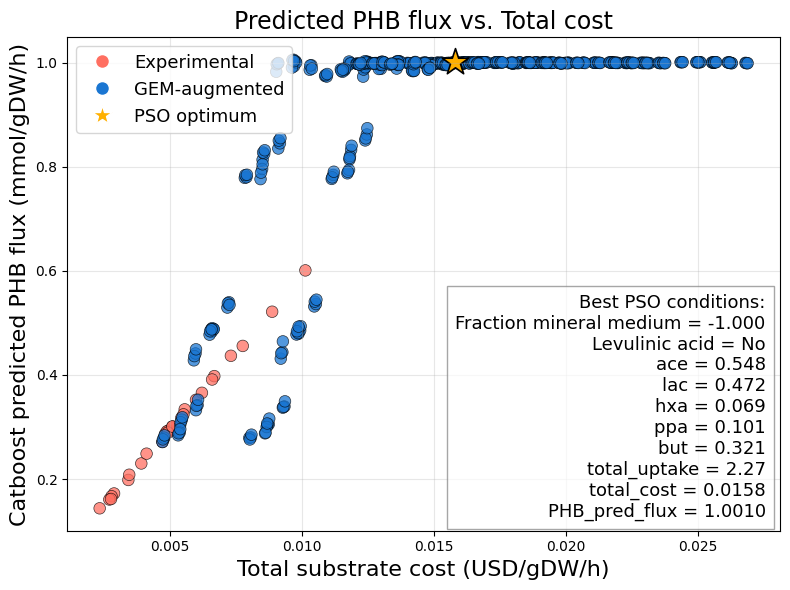

In [ ]:
# Full fixed pipeline: CatBoost surrogate + numeric-only PSO + PHB conversions + CSV output
# Includes R2, Pearson, RMSE, MAPE evaluations
# Usage: place in same folder as your CSV and run.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr, stats
import random

# -------------------------
# USER CONFIG
# -------------------------
CSV_PATH = "Buitron2025_dataset_augmented_VFAs_phb_with_cost_n2.csv"
TARGET_COL = "PHB_model_flux"
SAVE_PSO_CSV = "catboost_pso_optimal_conditions.csv"
RANDOM_SEED = 0

# PHB conversion assumptions
MW_PHB = 86.0       # g/mol (3HB monomer)
X_gDW_L = 1.0       # biomass concentration (gDW/L)
t_h = 1.0           # integration time (h)

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# -------------------------
# 1) Load & clean
# -------------------------
df = pd.read_csv(CSV_PATH)

# Remove duplicate columns
if df.columns.duplicated().any():
    print("Warning: duplicate columns detected. Removing duplicates.")
    df = df.loc[:, ~df.columns.duplicated()]

print("\nLoaded columns:")
print(df.columns.tolist())

if TARGET_COL not in df.columns:
    raise KeyError(f"Target column '{TARGET_COL}' not in CSV.")

# -------------------------
# 2) Detect substrate columns
# -------------------------
substrates = ['ac', 'fum', 'hxa', 'ppa', 'lac', 'but', 'succ']

detected_substrates = []
for sub in substrates:
    matches = [c for c in df.columns if sub.lower() in c.lower()]
    detected_substrates.extend(matches)
detected_substrates = list(dict.fromkeys(detected_substrates))
print("\nDetected substrate columns:", detected_substrates)

# -------------------------
# 3) Extra numeric features
# -------------------------
extra_numeric_features = ["C/N_ratio", "total_uptake", "total_cost"]
extra_numeric_features = [c for c in extra_numeric_features if c in df.columns]
print("Extra numeric features:", extra_numeric_features)

# Combine candidate numeric columns, remove 'Levulinic acid'
candidate_numeric = detected_substrates + extra_numeric_features
candidate_numeric = [c for c in candidate_numeric if c in df.columns and c != 'Levulinic acid']
print("Candidate numeric columns:", candidate_numeric)

# -------------------------
# 4) Detect categorical columns
# -------------------------
predefined_cat_features = [
    'Type of substrate', 'Illumination', 'Levulinic acid',
    'Operation mode', 'Substrate_type'
]
predefined_cat_features = [c for c in predefined_cat_features if c in df.columns]

inferred_cat_features = [c for c in df.columns if df[c].dtype == "object" and c != TARGET_COL]

cat_features = []
for c in predefined_cat_features + inferred_cat_features:
    if c not in cat_features:
        cat_features.append(c)

print("Categorical columns:", cat_features)

# Convert categorical columns to string
for col in cat_features:
    df[col] = df[col].astype(str)

# -------------------------
# 5) Build training features
# -------------------------
features_for_training = candidate_numeric + [c for c in cat_features if c not in candidate_numeric]
if TARGET_COL in features_for_training:
    features_for_training.remove(TARGET_COL)

X = df[features_for_training].copy()
y = df[TARGET_COL].copy()

# Coerce numeric
for col in X.columns:
    if col not in cat_features:
        X[col] = pd.to_numeric(X[col], errors="coerce")

# Drop rows with NaNs
mask = ~X.isna().any(axis=1) & ~y.isna()
X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)
df = df.loc[mask].reset_index(drop=True)

# -------------------------
# 6) Train/test split + CatBoost
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print("\nTraining CatBoost surrogate...")
model = CatBoostRegressor(
    iterations=600,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    verbose=100
)
model.fit(X_train, y_train, eval_set=(X_test, y_test), cat_features=cat_features)

# -------------------------
# 6b) Model performance metrics
# -------------------------
pred_test = model.predict(X_test)
rmse = mean_squared_error(y_test, pred_test)**0.5
r2 = r2_score(y_test, pred_test)
pearson_r, pearson_p = pearsonr(y_test, pred_test)
y_test_nonzero = np.where(y_test == 0, np.nan, y_test)
mape = np.nanmean(np.abs((y_test_nonzero - pred_test) / y_test_nonzero)) * 100

print(f"\nRMSE: {rmse:.6f}, R²: {r2:.6f}, Pearson R: {pearson_r:.6f}, MAPE: {mape:.3f}%")

# Retrain on full dataset
model.fit(X, y, cat_features=cat_features)
df["PHB_pred_flux"] = model.predict(X)

# -------------------------
# 7) PSO (numeric-only)
# -------------------------
numeric_cols = candidate_numeric.copy()  # ensure substrates + extra numeric features
fixed_cat_values = {c: df[c].mode().iloc[0] for c in cat_features}

lb = np.array([df[c].min() for c in numeric_cols], dtype=float)
ub = np.array([df[c].max() for c in numeric_cols], dtype=float)

n_particles = 40
n_iterations = 80
w, c1, c2 = 0.7, 1.5, 1.5
dim = len(numeric_cols)

particles = np.random.uniform(lb, ub, size=(n_particles, dim))
vel = np.zeros_like(particles)

def pso_objective_numeric(v):
    row = {c: float(v[i]) for i, c in enumerate(numeric_cols)}
    row.update(fixed_cat_values)
    # Fill remaining features
    for feat in features_for_training:
        if feat not in row:
            if feat in cat_features:
                row[feat] = df[feat].mode().iloc[0]
            else:
                row[feat] = df[feat].median()
    sample = pd.DataFrame([row], columns=features_for_training)
    return -model.predict(sample)[0]

pbest = particles.copy()
pbest_vals = np.array([pso_objective_numeric(p) for p in particles])
gbest = pbest[pbest_vals.argmin()].copy()
gbest_val = pbest_vals.min()

for it in range(n_iterations):
    for i in range(n_particles):
        r1, r2 = np.random.rand(dim), np.random.rand(dim)
        vel[i] = w*vel[i] + c1*r1*(pbest[i]-particles[i]) + c2*r2*(gbest-particles[i])
        particles[i] = np.clip(particles[i]+vel[i], lb, ub)
        val = pso_objective_numeric(particles[i])
        if val < pbest_vals[i]:
            pbest[i], pbest_vals[i] = particles[i].copy(), val
            if val < gbest_val:
                gbest, gbest_val = particles[i].copy(), val

# -------------------------
# 8) Build best PSO solution
# -------------------------
best_row = {c: float(gbest[i]) for i, c in enumerate(numeric_cols)}
best_row.update(fixed_cat_values)

for feat in features_for_training:
    if feat not in best_row:
        best_row[feat] = df[feat].mode().iloc[0] if feat in cat_features else df[feat].median()

best_df = pd.DataFrame([best_row])
best_df["PHB_pred_flux"] = model.predict(best_df)[0]
best_df["PHB_pred_gL"] = best_df["PHB_pred_flux"] * X_gDW_L * (MW_PHB/1000) * t_h
best_df["PHB_pred_percent"] = best_df["PHB_pred_flux"] * (MW_PHB/1000) * 100 * t_h

best_df.to_csv(SAVE_PSO_CSV, index=False)
print("\nSaved PSO optimal conditions to:", SAVE_PSO_CSV)
print("\nBest solution:")
print(best_df.T)

# -------------------------
# 9) Final plot: Predicted PHB flux vs Total Cost
# -------------------------
COLOR_EXP, COLOR_GEM, COLOR_PSO = "#FF6F61", "#1A76D2", "#FFB000"
pso_cost, pso_phb = best_df["total_cost"].iloc[0], best_df["PHB_pred_flux"].iloc[0]

plt.figure(figsize=(8,6))
plt.scatter(df["total_cost"], df["PHB_pred_flux"],
            c=df["is_experimental"].map({1: COLOR_EXP, 0: COLOR_GEM}),
            alpha=0.75, s=70, edgecolor="k", linewidth=0.5)
plt.scatter(pso_cost, pso_phb, marker="*", color=COLOR_PSO, s=400, edgecolor="k", linewidth=1.2)
plt.xlabel("Total substrate cost (USD/gDW/h)", fontsize=16)
plt.ylabel("Catboost predicted PHB flux (mmol/gDW/h)", fontsize=16)
plt.title("Predicted PHB flux vs. Total cost", fontsize=17)
plt.grid(alpha=0.3)
plt.legend(handles=[
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_EXP, markersize=10, label="Experimental"),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_GEM, markersize=10, label="GEM-augmented"),
    plt.Line2D([0],[0], marker='*', color='w', markerfacecolor=COLOR_PSO, markersize=15, label="PSO optimum")
], fontsize=13, loc="upper left")

# Annotate PSO optimal solution with substrates + numeric features
feature_text_lines = ["Best PSO conditions:"]
for col in detected_substrates:
    if col in best_df.columns:
        val = best_df[col].iloc[0]
        # Only negate numeric
        if np.issubdtype(type(val), np.number):
            val = -val
        feature_text_lines.append(f"{col} = {val:.3f}" if isinstance(val, (int, float)) else f"{col} = {val}")

extra_numeric = ['C/N_ratio', 'total_uptake', 'total_cost', 'PHB_pred_flux']
for col in extra_numeric:
    if col in best_df.columns:
        val = best_df[col].iloc[0]
        if col not in ['total_cost', 'PHB_pred_flux'] and np.issubdtype(type(val), np.number):
            val = -val
        feature_text_lines.append(
            f"{col} = {val:.2f}" if isinstance(val, (int, float)) and col not in ['total_cost', 'PHB_pred_flux']
            else f"{col} = {val:.4f}"
        )
feature_text = "\n".join(feature_text_lines)

plt.annotate(feature_text, xy=(0.98,0.02), xycoords='axes fraction', fontsize=13,
             ha='right', va='bottom', bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7, pad=6))

plt.tight_layout()
plt.savefig(project_root / "results" / "catboost_predPHB_vs_cost_pso_annotated.png", dpi=300, bbox_inches="tight")
plt.show()


# Literature data PHB predictions with pre-trained Catboost
Catboost was trained with

In [ ]:
df_lit=pd.read_csv(base_model_dir /"Literature_dataset_augmented_with_FBA_PHB.csv")


In [ ]:
df_lit.columns.tolist()

['Paper number',
 'Strain',
 'Inoculum size (initial biomass)',
 'Time (d)',
 'Preculture conditions',
 'Type of substrate',
 'C concentration mg/L',
 'N source',
 'mg N/L',
 'C/N (molar base)',
 'g substrate COD/L',
 'Medium ',
 'Medium supplementation',
 'Supp concentration, mg/L',
 'Biomass (mg dw/L)',
 '% PHB',
 'PHB (mg/L)',
 'PHB yield',
 'Composition of PHA, 3HB Mol%',
 'Composition of PHA, 3HV Mol%',
 'Illumination ',
 'O2 conditions',
 'Illumination (lux)',
 'T (°C)',
 'DOI',
 'Row',
 'Time_h',
 'Biomass_gL',
 'PHB_exp_flux',
 'Acetate_exp_flux',
 'PHB_model_flux',
 'Acetate_model_flux',
 'NH4_model_flux',
 'PHB_fva_width']

In [ ]:
set(df_lit.columns.tolist())-set(model.feature_names_)


{'Acetate_exp_flux',
 'Acetate_model_flux',
 'C concentration mg/L',
 'Composition of PHA, 3HB Mol%',
 'Composition of PHA, 3HV Mol%',
 'DOI',
 'Illumination ',
 'Illumination (lux)',
 'Inoculum size (initial biomass)',
 'Medium ',
 'Medium supplementation',
 'N source',
 'O2 conditions',
 'PHB yield',
 'PHB_exp_flux',
 'Paper number',
 'Preculture conditions',
 'Strain',
 'Supp concentration, mg/L',
 'T (°C)'}

In [ ]:
# ============================================================
# CatBoost PHB Flux Prediction from Literature Operational Data
# ============================================================

import pandas as pd
from catboost import CatBoostRegressor, Pool
import numpy as np

# -------------------------
# LOAD PRE-TRAINED MODEL
# -------------------------
cat_model_path = "catboost_model.cbm"  # replace with your path
model = CatBoostRegressor()
model.load_model(cat_model_path)

# -------------------------
# LITERATURE DATASET
# -------------------------
# df_literature should already exist
print("Literature dataset shape:", df_lit.shape)

# -------------------------
# SELECT FEATURES
# -------------------------
# Make sure these are the operational parameters your CatBoost model was trained on
# Example:
features = [
    "Type of substrate",   # categorical
    "g substrate COD/L",
    "mg N/L"
]

# Optional: remove rows with missing features
df_pred = df_lit.dropna(subset=features).copy()

X = df_pred[features]

# If you have categorical columns, CatBoost can handle them directly
categorical_features = ["Type of substrate"]  # example
cat_features_idx = [X.columns.get_loc(col) for col in categorical_features if col in X.columns]

# -------------------------
# PREDICT PHB FLUX
# -------------------------
# Output: PHB flux in the same units as model training (e.g., mmol/gDW/h)
df_pred["PHB_pred_flux"] = model.predict(X, cat_features=cat_features_idx)

# -------------------------
# OPTIONAL: Compare to literature fluxes if available
# -------------------------
if "PHB_exp_flux" in df_pred.columns:
    df_pred["PHB_flux_error"] = df_pred["PHB_pred_flux"] - df_pred["PHB_exp_flux"]

# -------------------------
# SAVE RESULTS
# -------------------------
df_pred.to_csv(project_root / "results" / "df_literature_PHB_flux_predictions.csv", index=False)

print("✅ PHB flux predictions saved. Sample:")
print(df_pred[["PHB_pred_flux"]].head())


# Spearman Correlation Heatmap

Index(['Experiment', 'Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)',
       '% PHV', '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)',
       'Experiment.1', 'Time (d)', 'g substrate COD/L', 'Type of substrate',
       'mg N/L', 'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium',
       ' g NaHCO3/L', 'Illumination', 'Levulinic acid',
       'Fe (mg Ferric citrate/L)', 'Operation mode', '% Volume exchange',
       'Row', 'Biomass_mgL', 'COD_gL_fed', 'Substrate_type', 'Time_h',
       'PHB_mgL', 'biomass_initial_gL', 'biomass_final_gL', 'biomass_eff_gL',
       'PHB_exp_flux', 'Substrate_exp_flux', 'sub_rxn_id', 'PHB_model_flux',
       'PHV_model_flux', '3HV_model_flux', 'PHBV_model_flux',
       'Biomass_model_flux', 'Substrate_model_flux', 'Top10_fluxes'],
      dtype='object')


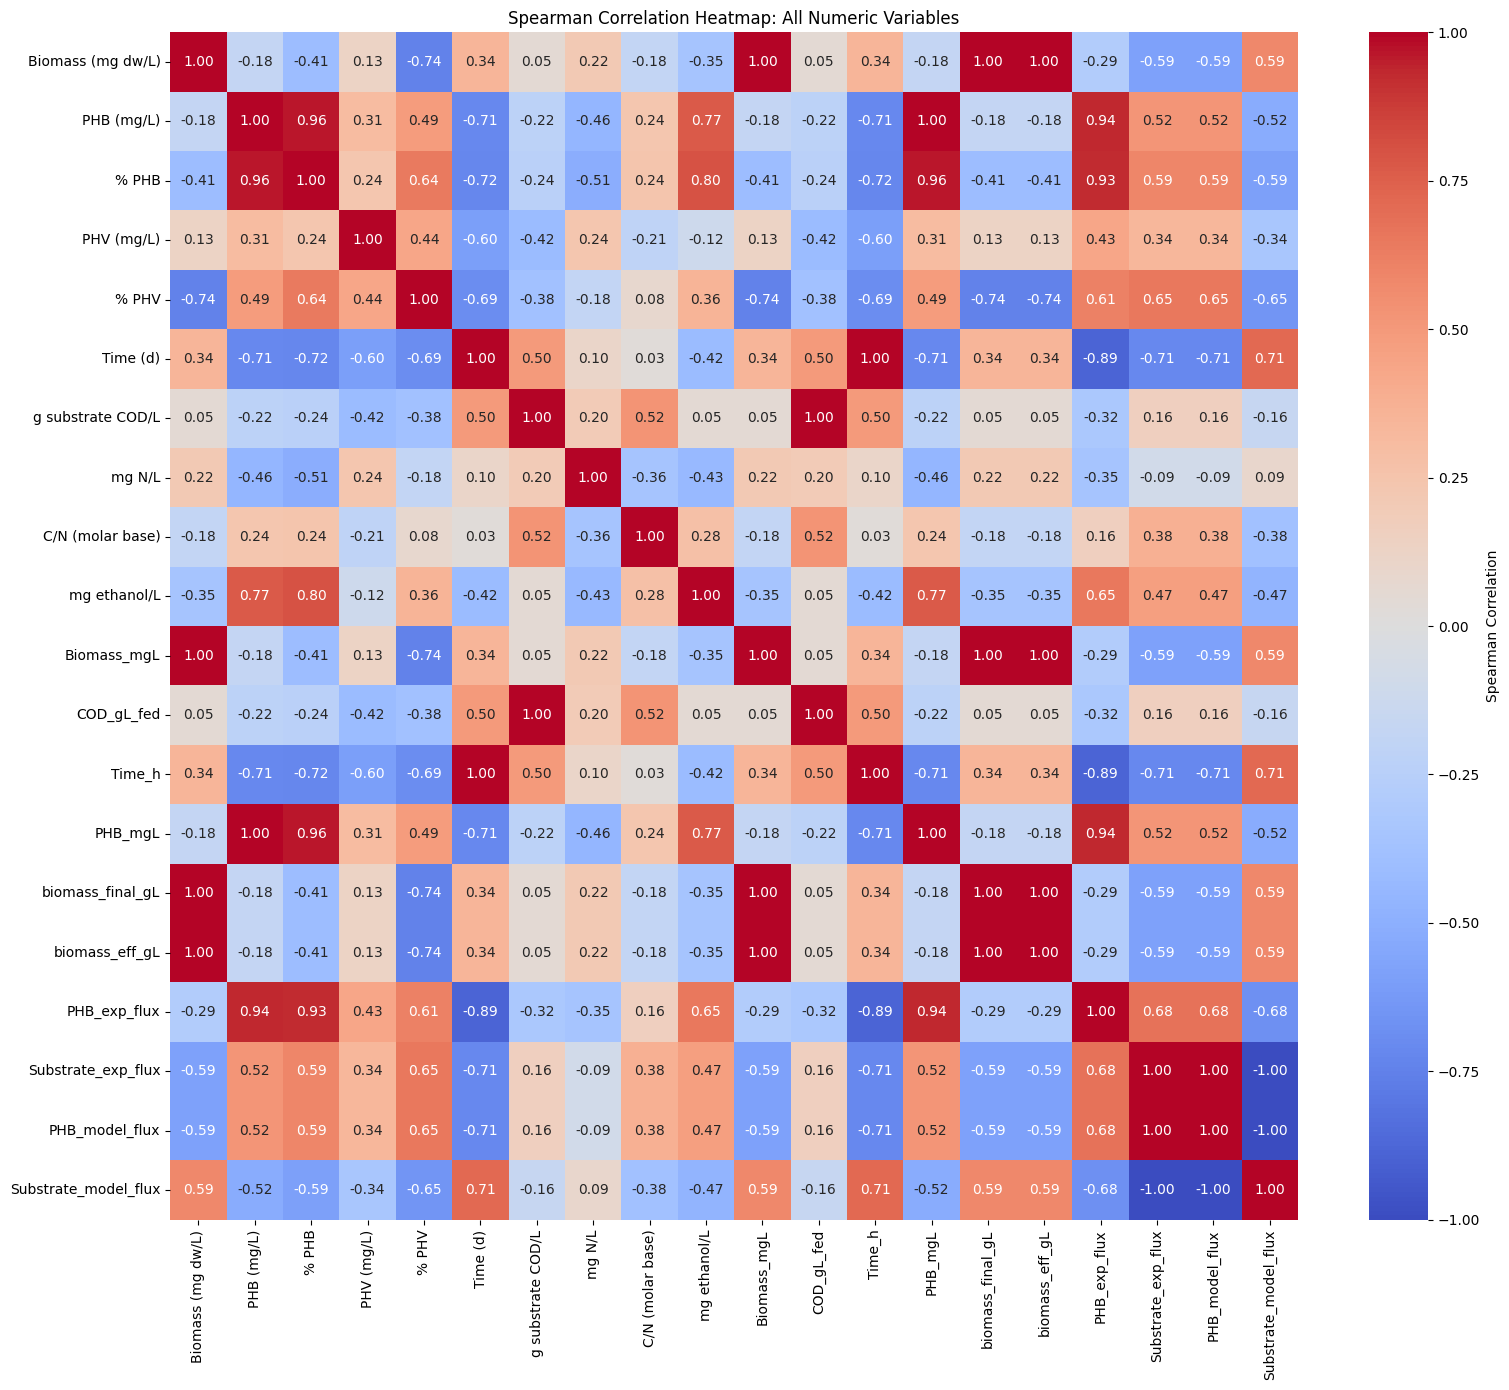

In [ ]:
# Load experimental data form Buitron 2025 with fluxes added from GEM
expanded_csv_path = os.path.join(OUTPUT_DIR, "Buitron_FBA_with_fluxes.csv")

df = pd.read_csv("Buitron_with_FBA_fluxes.csv")

print(df.columns)

columns_to_drop = ['Row', 'Experiment', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)', 'Experiment.1', '5-ALA (micromol/L)'] # focus on PHB

# Remove the specified columns
# axis=1 indicates columns (axis=0 is for rows)
# inplace=True modifies the DataFrame directly, otherwise a new DataFrame is returned
df.drop(columns_to_drop, axis=1, inplace=True)


# Keep only numeric columns
numeric_df = df.select_dtypes(include=[float, int])

# Drop constant columns
numeric_df = numeric_df.loc[:, numeric_df.nunique() > 1]

# Compute Spearman correlation
spearman_corr = numeric_df.corr(method='spearman')

# Plot heatmap with correlation values
plt.figure(figsize=(16, 14))
sns.heatmap(
    spearman_corr,
    cmap="coolwarm",
    center=0,
    annot=True,        # Show correlation values
    fmt=".2f",         # Format to 2 decimal places
    cbar_kws={'label': 'Spearman Correlation'}
)
plt.title("Spearman Correlation Heatmap: All Numeric Variables")
plt.tight_layout()
plt.show()


Note: almost all fluxes corrlate negatively with PHB production. Also, fluxes seem to correlate almost perfectly among them.

# WordCloud (using SHAP values)

In [ ]:
from wordcloud import WordCloud

# Make a dictionary for WordCloud: subsystem -> mean absolute SHAP
# You can use signed or absolute values depending on whether you want directionality
wordcloud_dict = subsystem_shap_signed.abs().to_dict()  # use abs for size only

# Create the WordCloud
wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis"  # choose any colormap
).generate_from_frequencies(wordcloud_dict)

# Display
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Subsystem Importance WordCloud (from SHAP values)")
plt.tight_layout()
plt.show()


# UMAP

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


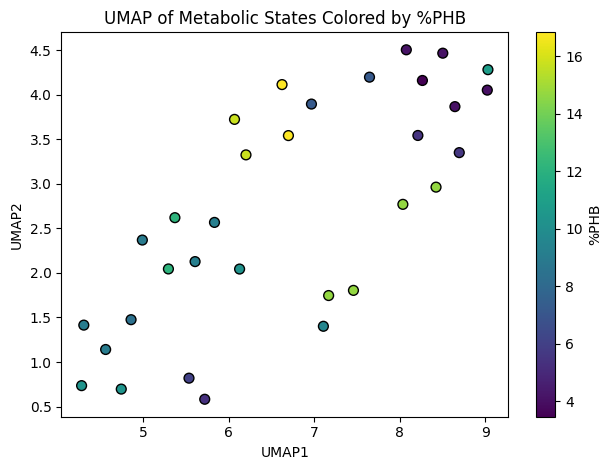

In [ ]:
from sklearn.preprocessing import StandardScaler
import umap

# ---------------------------
# Load data
# ---------------------------
df = pd.read_csv(expanded_csv_path)

# Select flux columns (numeric)
flux_cols = [c for c in df.columns if c.startswith("flux_")]
flux_data = df[flux_cols].fillna(0)  # fill missing fluxes

# Assuming flux_data is numeric and scaled
scaler = StandardScaler()
flux_scaled = scaler.fit_transform(flux_data)

# Run UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
umap_embedding = reducer.fit_transform(flux_scaled)

# Plot UMAP, make sure to capture the scatter object
scatter = plt.scatter(
    umap_embedding[:,0],
    umap_embedding[:,1],
    c=df["% PHB"].values,  # numeric values
    cmap="viridis",
    s=50,
    edgecolor="k"
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP of Metabolic States Colored by %PHB")

# Attach colorbar to the scatter
plt.colorbar(scatter, label="%PHB")

plt.tight_layout()
plt.show()


In [ ]:
# Find the metabolic states associated to the highest porduction of PHB

# Identify indices of top 3 highest %PHB
top3_idx = df["% PHB"].nlargest(3).index

# Get their UMAP coordinates
top3_umap = umap_embedding[top3_idx]

# Get the original fluxes of these top 3 points
top3_fluxes = flux_data.iloc[top3_idx]

# Optionally, get all info from original dataframe
top3_data = df.iloc[top3_idx]

print("Top 3 points by % PHB:")
print(top3_data)

print("\nUMAP coordinates of top 3 points:")
print(top3_umap)

print("\nFlux profiles of top 3 points:")
print(top3_fluxes)


Top 3 points by % PHB:
    Experiment  Biomass (mg dw/L)  PHB (mg/L)  % PHB  PHV (mg/L)  % PHV  \
17          21               1417      238.44  16.83       10.65   0.75   
18          22               1367      230.03  16.83       10.27   0.75   
21          25               1433      225.72  15.75       10.67   0.74   

    5-ALA (micromol/L)  Q10 (mg/g dw)  Carotenoids (mg/g dw)  Experiment.1  \
17                 NaN            NaN                    NaN           NaN   
18                 NaN            NaN                    NaN           NaN   
21                 NaN            NaN                    NaN           NaN   

    ...  flux_ASPTA  flux_GLNS flux_GLUSfx  flux_FNOR_1  flux_ATPSu  \
17  ...   -2.730924   1.990027    1.990027          NaN         NaN   
18  ...   -2.830843   2.062836    2.062836          NaN         NaN   
21  ...   -3.146851   2.293108    2.293108          NaN         NaN   

    flux_ACOAH  flux_DHORDi  flux_DHORD3um flux_ATPM flux_NDH_1_1_um_copy1  
1

Top 3 PHB producers:
   % PHB
1  16.83
2  16.83
5  15.75


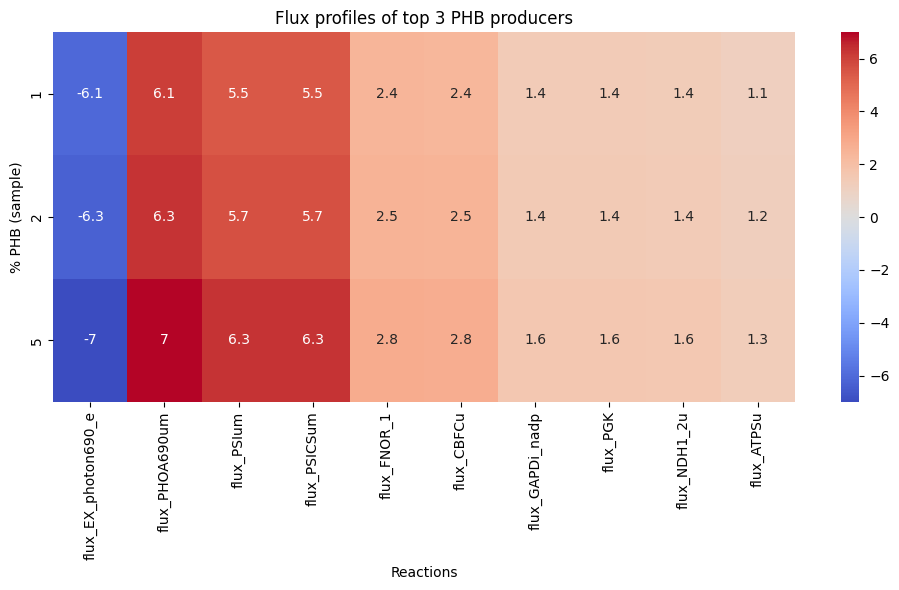

In [ ]:
# Sort dataframe by % PHB
top3_idx = df["% PHB"].nlargest(3).index
top3_df = df.loc[top3_idx]

print("Top 3 PHB producers:")
print(top3_df[["% PHB"]])

# Visualize heatmap

plt.figure(figsize=(10,6))
sns.heatmap(top3_fluxes, cmap="coolwarm", annot=True)
plt.title("Flux profiles of top 3 PHB producers")
plt.xlabel("Reactions")
plt.ylabel("% PHB (sample)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# Performance comparisson

This code is comparing catboost with different datasets (i.e., original, original+ augmented, just augmented)

Standard numeric cols: ['Biomass (mg dw/L)', 'PHB (mg/L)', 'PHV (mg/L)', '% PHV', 'Time (d)', 'g substrate COD/L', 'mg N/L', 'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium', ' g NaHCO3/L', 'Fe (mg Ferric citrate/L)', '% Volume exchange', 'Biomass_mgL', 'PHB_mgL', 'COD_gL_fed', 'biomass_gL', 'PHB_exp_flux', 'Acetate_flux', 'PHB_model_flux', 'Biomass_model_flux', 'Substrate_model_flux']
Flux cols: []
Categorical cols: ['Type of substrate']
Standard features only -> RMSE: 0.36122453449804937 R²: 0.9923272922367269
Standard + flux features -> RMSE: 0.36122453449804937 R²: 0.9923272922367269

Training set (first 10 rows, Standard + Flux features):
   Biomass (mg dw/L)  PHB (mg/L)  PHV (mg/L)  % PHV  Time (d)  \
0               1538      158.07        0.60   0.60         5   
1               1383      125.21        8.00   0.58         4   
2               2467       85.56       11.97   0.57         5   
3               1667       93.18        5.12   0.34         5   
4         

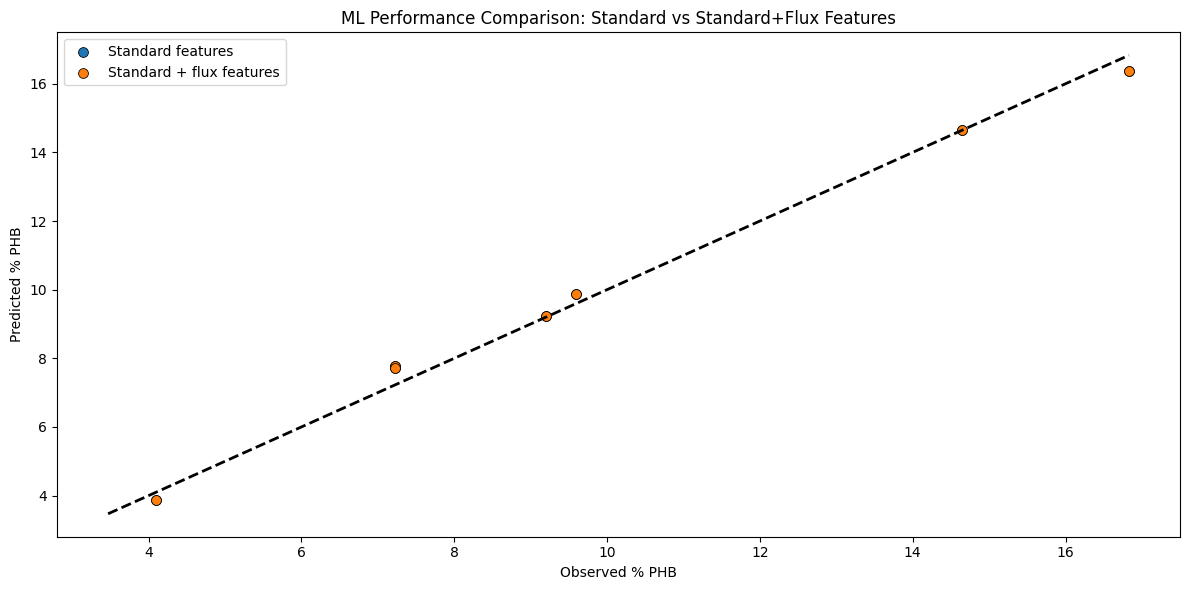

In [ ]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score

# -------------------------------
# LOAD DATA
# -------------------------------
df = pd.read_csv("Buitron_with_FBA_fluxes.csv") #expanded_csv_path

columns_to_drop = ['Row', 'Experiment', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)', 'Experiment.1', '5-ALA (micromol/L)']
df.drop(columns_to_drop, axis=1, inplace=True)

TARGET = "% PHB"
df = df[np.isfinite(df[TARGET])]
df = df.reset_index(drop=True)

# -------------------------------
# FEATURE IDENTIFICATION
# -------------------------------
flux_cols = [c for c in df.columns if c.startswith("flux_")]

standard_numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
standard_numeric_cols = [c for c in standard_numeric_cols if c not in flux_cols + [TARGET]]

cat_cols = [c for c in ["Substrate", "Type of substrate", "substrate_type"] if c in df.columns]

print("Standard numeric cols:", standard_numeric_cols)
print("Flux cols:", flux_cols)
print("Categorical cols:", cat_cols)

# -------------------------------
# HELPER FUNCTION TO TRAIN AND EVALUATE
# -------------------------------
def train_evaluate_catboost(X, y, cat_cols=None, random_state=42):
    # Split first to keep original DataFrame alignment
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    # Preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), [c for c in X.columns if c not in (cat_cols or [])]),
            ("cat", OneHotEncoder(sparse_output=False), cat_cols or [])
        ],
        remainder="drop"
    )

    X_train_trans = preprocessor.fit_transform(X_train)
    X_test_trans = preprocessor.transform(X_test)

    # Feature names after preprocessing
    ohe_names = list(preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)) if cat_cols else []
    feature_names = [c for c in X.columns if c not in (cat_cols or [])] + ohe_names

    train_pool = Pool(X_train_trans, y_train, feature_names=feature_names)
    test_pool = Pool(X_test_trans, y_test, feature_names=feature_names)

    model = CatBoostRegressor(
        iterations=600,
        depth=4,
        learning_rate=0.05,
        loss_function="RMSE",
        verbose=0
    )

    model.fit(train_pool, eval_set=test_pool, use_best_model=True)

    y_pred = model.predict(X_test_trans)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Return aligned DataFrames as well
    return model, mse, r2, X_train, X_test, y_train, y_test, y_pred

# -------------------------------
# MODEL 1: Standard features only
# -------------------------------
X_standard = df[standard_numeric_cols + cat_cols]
y = df[TARGET]

(model_std, mse_std, r2_std,
 X_train_std, X_test_std, y_train_std, y_test_std, y_pred_std) = train_evaluate_catboost(X_standard, y, cat_cols=cat_cols)

print("Standard features only -> RMSE:", np.sqrt(mse_std), "R²:", r2_std)

# -------------------------------
# MODEL 2: Standard + Flux features
# -------------------------------
X_flux = df[standard_numeric_cols + flux_cols + cat_cols]

(model_flux, mse_flux, r2_flux,
 X_train_flux, X_test_flux, y_train_flux, y_test_flux, y_pred_flux) = train_evaluate_catboost(X_flux, y, cat_cols=cat_cols)

print("Standard + flux features -> RMSE:", np.sqrt(mse_flux), "R²:", r2_flux)

# -------------------------------
# PRINT TRAINING AND VALIDATION DATASETS
# -------------------------------
print("\nTraining set (first 10 rows, Standard + Flux features):")
print(pd.concat([X_train_flux.reset_index(drop=True), y_train_flux.reset_index(drop=True)], axis=1).head(10))

print("\nValidation set (first 10 rows, Standard + Flux features):")
print(pd.concat([X_test_flux.reset_index(drop=True), y_test_flux.reset_index(drop=True)], axis=1).head(10))

# -------------------------------
# VISUALIZE PERFORMANCE
# -------------------------------
plt.figure(figsize=(12,6))
sns.scatterplot(x=y_test_std, y=y_pred_std, label="Standard features", s=50, edgecolor="k")
sns.scatterplot(x=y_test_flux, y=y_pred_flux, label="Standard + flux features", s=50, edgecolor="k")

plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel("Observed % PHB")
plt.ylabel("Predicted % PHB")
plt.title("ML Performance Comparison: Standard vs Standard+Flux Features")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
df = pd.read_csv(expanded_csv_path)

columns_to_drop = ['Row', 'Experiment', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)', 'Experiment.1', '5-ALA (micromol/L)']
df.drop(columns_to_drop, axis=1, inplace=True)
print(df.columns)

Index(['Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)', '% PHV',
       'Time (d)', 'g substrate COD/L', 'Type of substrate', 'mg N/L',
       'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium',
       ' g NaHCO3/L', 'Illumination', 'Levulinic acid',
       'Fe (mg Ferric citrate/L)', 'Operation mode', '% Volume exchange',
       'Substrate', 'Substrate_flux', 'PHB_exp_mgL', 'PHB_exp_q',
       'PHB_model_q', 'Biomass_flux', 'flux_EX_photon690_e', 'flux_PHOA690um',
       'flux_PSIum', 'flux_PSICSum', 'flux_FNOR_1', 'flux_CBFCu',
       'flux_GAPDi_nadp', 'flux_PGK', 'flux_NDH1_2u', 'flux_ATPSu'],
      dtype='object')


# Version 2 of performance comparison

In [ ]:
# Standardized version of performance comparison

# -------------------------------
# LOAD DATA
# -------------------------------
df = pd.read_csv(expanded_csv_path)

columns_to_drop = ['Row', 'Experiment', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)', 'Experiment.1', '5-ALA (micromol/L)']
df.drop(columns_to_drop, axis=1, inplace=True)

TARGET = "% PHB"
df = df[np.isfinite(df[TARGET])]
df = df.reset_index(drop=True)

# -------------------------------
# FEATURE IDENTIFICATION
# -------------------------------
flux_cols = [c for c in df.columns if c.startswith("flux_")]

standard_numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
standard_numeric_cols = [c for c in standard_numeric_cols if c not in flux_cols + [TARGET]]

cat_cols = [c for c in ["Substrate", "Type of substrate", "substrate_type"] if c in df.columns]

print("Standard numeric cols:", standard_numeric_cols)
print("Flux cols:", flux_cols)
print("Categorical cols:", cat_cols)

# -------------------------------
# HELPER FUNCTION TO TRAIN AND EVALUATE
# -------------------------------
def train_evaluate_catboost(X, y, cat_cols=None, random_state=42):
    # Preprocessing: standardize all numeric features
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), [c for c in X.columns if c not in (cat_cols or [])]),
            ("cat", OneHotEncoder(sparse_output=False), cat_cols or [])
        ],
        remainder="drop"
    )

    # Split into train/validation
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    X_train_trans = preprocessor.fit_transform(X_train)
    X_test_trans = preprocessor.transform(X_test)

    # Feature names after preprocessing
    ohe_names = list(preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)) if cat_cols else []
    feature_names = [c for c in X.columns if c not in (cat_cols or [])] + ohe_names

    train_pool = Pool(X_train_trans, y_train, feature_names=feature_names)
    test_pool = Pool(X_test_trans, y_test, feature_names=feature_names)

    model = CatBoostRegressor(
        iterations=600,
        depth=4,
        learning_rate=0.05,
        loss_function="RMSE",
        verbose=0
    )

    model.fit(train_pool, eval_set=test_pool, use_best_model=True)

    y_pred = model.predict(X_test_trans)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return model, mse, r2, X_train, X_test, y_train, y_test, y_pred

# -------------------------------
# MODEL 1: Standard features only
# -------------------------------
X_standard = df[standard_numeric_cols + cat_cols]
y = df[TARGET]

model_std, mse_std, r2_std, X_train_std, X_test_std, y_train_std, y_test_std, y_pred_std = train_evaluate_catboost(
    X_standard, y, cat_cols=cat_cols
)
print("Standard features only -> RMSE:", np.sqrt(mse_std), "R²:", r2_std)

# -------------------------------
# MODEL 2: Standard + Flux features
# -------------------------------
X_flux = df[standard_numeric_cols + flux_cols + cat_cols]

model_flux, mse_flux, r2_flux, X_train_flux, X_test_flux, y_train_flux, y_test_flux, y_pred_flux = train_evaluate_catboost(
    X_flux, y, cat_cols=cat_cols
)
print("Standard + flux features -> RMSE:", np.sqrt(mse_flux), "R²:", r2_flux)

# -------------------------------
# PRINT TRAINING/VALIDATION DATA
# -------------------------------
print("\nTraining set (first 10 rows):")
print(pd.concat([X_train_flux.reset_index(drop=True), y_train_flux.reset_index(drop=True)], axis=1).head(10))

print("\nValidation set (first 10 rows):")
print(pd.concat([X_test_flux.reset_index(drop=True), y_test_flux.reset_index(drop=True)], axis=1).head(10))

# -------------------------------
# VISUALIZE PERFORMANCE
# -------------------------------
plt.figure(figsize=(12,6))
sns.scatterplot(x=y_test_std, y=y_pred_std, label="Standard features", s=50, edgecolor="k")
sns.scatterplot(x=y_test_flux, y=y_pred_flux, label="Standard + flux features", s=50, edgecolor="k")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel("Observed % PHB")
plt.ylabel("Predicted % PHB")
plt.title("ML Performance Comparison: Standard vs Standard+Flux Features (All numeric features standardized)")
plt.legend()
plt.tight_layout()
plt.show()
